# Beyond BLAST Notebook

In [ ]:
using Base.Threads
println("Threads available: ", Threads.nthreads())

In [ ]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 
using HDF5, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
;

#### Including the .jl modules

In [609]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
include("blast_code/src/config.jl")
include("blast_code/src/paths.jl")
include("blast_code/src/plot_config.jl")
using .galaxy_galaxy
using .shear_shear
using .Blast
using .blast_tutorials

#### Defining an output folder for each run
#### Setting run parameters, plot parameters, and grids in k

In [610]:
#sets the paths for the output directories 
paths = setup_output_directories()
append_to_log(paths.output_dir, "=== Run started ===")
#sets up the cosmology grid and returns the parameters
grid_data = setup_cosmology_grid() 
#sets up the plotting theme and returns the parameters
plot_theme = setup_plot_theme() 
#saves the run parameters in a txt file
params_run = save_run_config(
    paths.output_dir, 
    grid_data.N, 
    grid_data.xmin, grid_data.xmax, 
    grid_data.zmin, grid_data.zmax, 
    grid_data.kmin, grid_data.kmax, 
    grid_data.n_cheb, 
    grid_data.ℓ, 
    grid_data.Nk, grid_data.Nkp, grid_data.Nkpp,
    grid_data.x, grid_data.z, 
    grids.k_grid, grids.kp_grid, grids.kpp_grid, grids.sorting)
#returns the k grids for the calculations
grids = Blast.make_k_grids(grid_data.kmin, grid_data.kmax, 
                           grid_data.Nk, grid_data.Nkp, grid_data.Nkpp; 
                           sorting=true, output_dir = paths.output_dir) 
;

Folders in place: out/runs/run_2026_07_21_173930, out/runs/run_2026_07_21_173930/plots and out/runs/run_2026_07_21_173930/quantities
Data brought to safety in folder: out/runs/run_2026_07_21_173930


---

Computing $\tilde W$?
- reuse = false will compute $\tilde W$
- reuse = true will load an already computed $\tilde W$, using the mode below to compute a different one for each choice of the parameters
  - mode = "slow" will load the slowly-computed $\tilde W$
  - mode = "fast" will load the fastly-computed $\tilde W$ -> not here anymore, fast and slow are the same object
  - mode = "big" will load the huge $\tilde W$ -> now here anymore

In [611]:
reuse = false #if set to true, the code will load the W_tilde. 
#mode = "slow"

false

In [612]:
default(fontfamily = "Computer Modern", titlefontfamily = "Computer Modern", legendfontfamily = "Computer Modern")

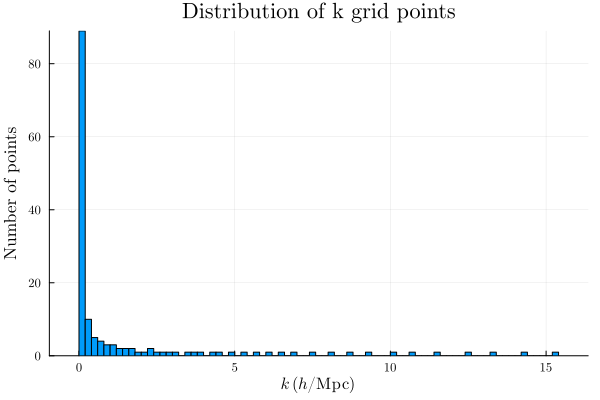

In [613]:
histogram(grids.k_grid, bins = 100, xlabel = L"k \; (h/\mathrm{Mpc})", ylabel = "Number of points", 
          title = "Distribution of k grid points", legend = false; plot_style = plot_theme.shared_style #, xscale = :log10
          )

In [614]:
println("k_grid: ", grids.k_grid[1], " ", grids.k_grid[end])
println("kmin: ", grid_data.kmin, " ", "kmax: ", grid_data.kmax)

k_grid: 0.000357142857142857 15.384615384615389
kmin: 0.00035714285714285714 kmax: 15.384615384615385


### Galaxy clustering factor

$bias = b(z,z^2,z^3)$
comes from [this paper](https://arxiv.org/pdf/1807.10331)

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = \frac{H(z) n(z) \chi(z)^2 b(z) D(z)}{c} $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, \
\
with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, \
\
with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z````, and then obtaining the total interpolated product ````W_cheb````.

As for the ````c_cheb````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [615]:
W_x, bias, growth, Hubble_param, nz_norm = galaxy_galaxy.galaxy_prefactor(grid_data.x, grid_data.z, grid_data.cosmo; 
                                             output_dir=paths.output_dir, plot_style = plot_theme.shared_style);
W_cheb, x_cheb = galaxy_galaxy.galaxy_prefactor_cheb(grid_data.xmin, grid_data.xmax, grid_data.n_cheb, grid_data.z, grid_data.x, 
                                             bias, growth, Hubble_param, nz_norm; output_dir=paths.output_dir, sorting=grids.sorting);
c_cheb = galaxy_galaxy.compute_prefactor_chebcoeffs(W_cheb; output_dir=paths.output_dir, sorting=grids.sorting);

In [616]:
npzwrite(joinpath(paths.output_dir, "W_x.npy"), W_x)
append_to_log(paths.output_dir, "W_x.npy saved.")
append_to_log(paths.output_dir, "the size of W_x is $(size(W_x)).")
npzwrite(joinpath(paths.output_dir, "W_cheb.npy"), W_cheb)
append_to_log(paths.output_dir, "W_cheb.npy saved.")
append_to_log(paths.output_dir, "the size of W_cheb is $(size(W_cheb)).")
npzwrite(joinpath(paths.quantity_subdir, "chebcoefs/c_cheb.npy"), c_cheb)
append_to_log(paths.output_dir, "c_cheb.npy saved.")

Is it true that

$W(\chi) \approx \sum_{n=0}^{N_{cheb}-1} c_n T_n(\chi)$ ?

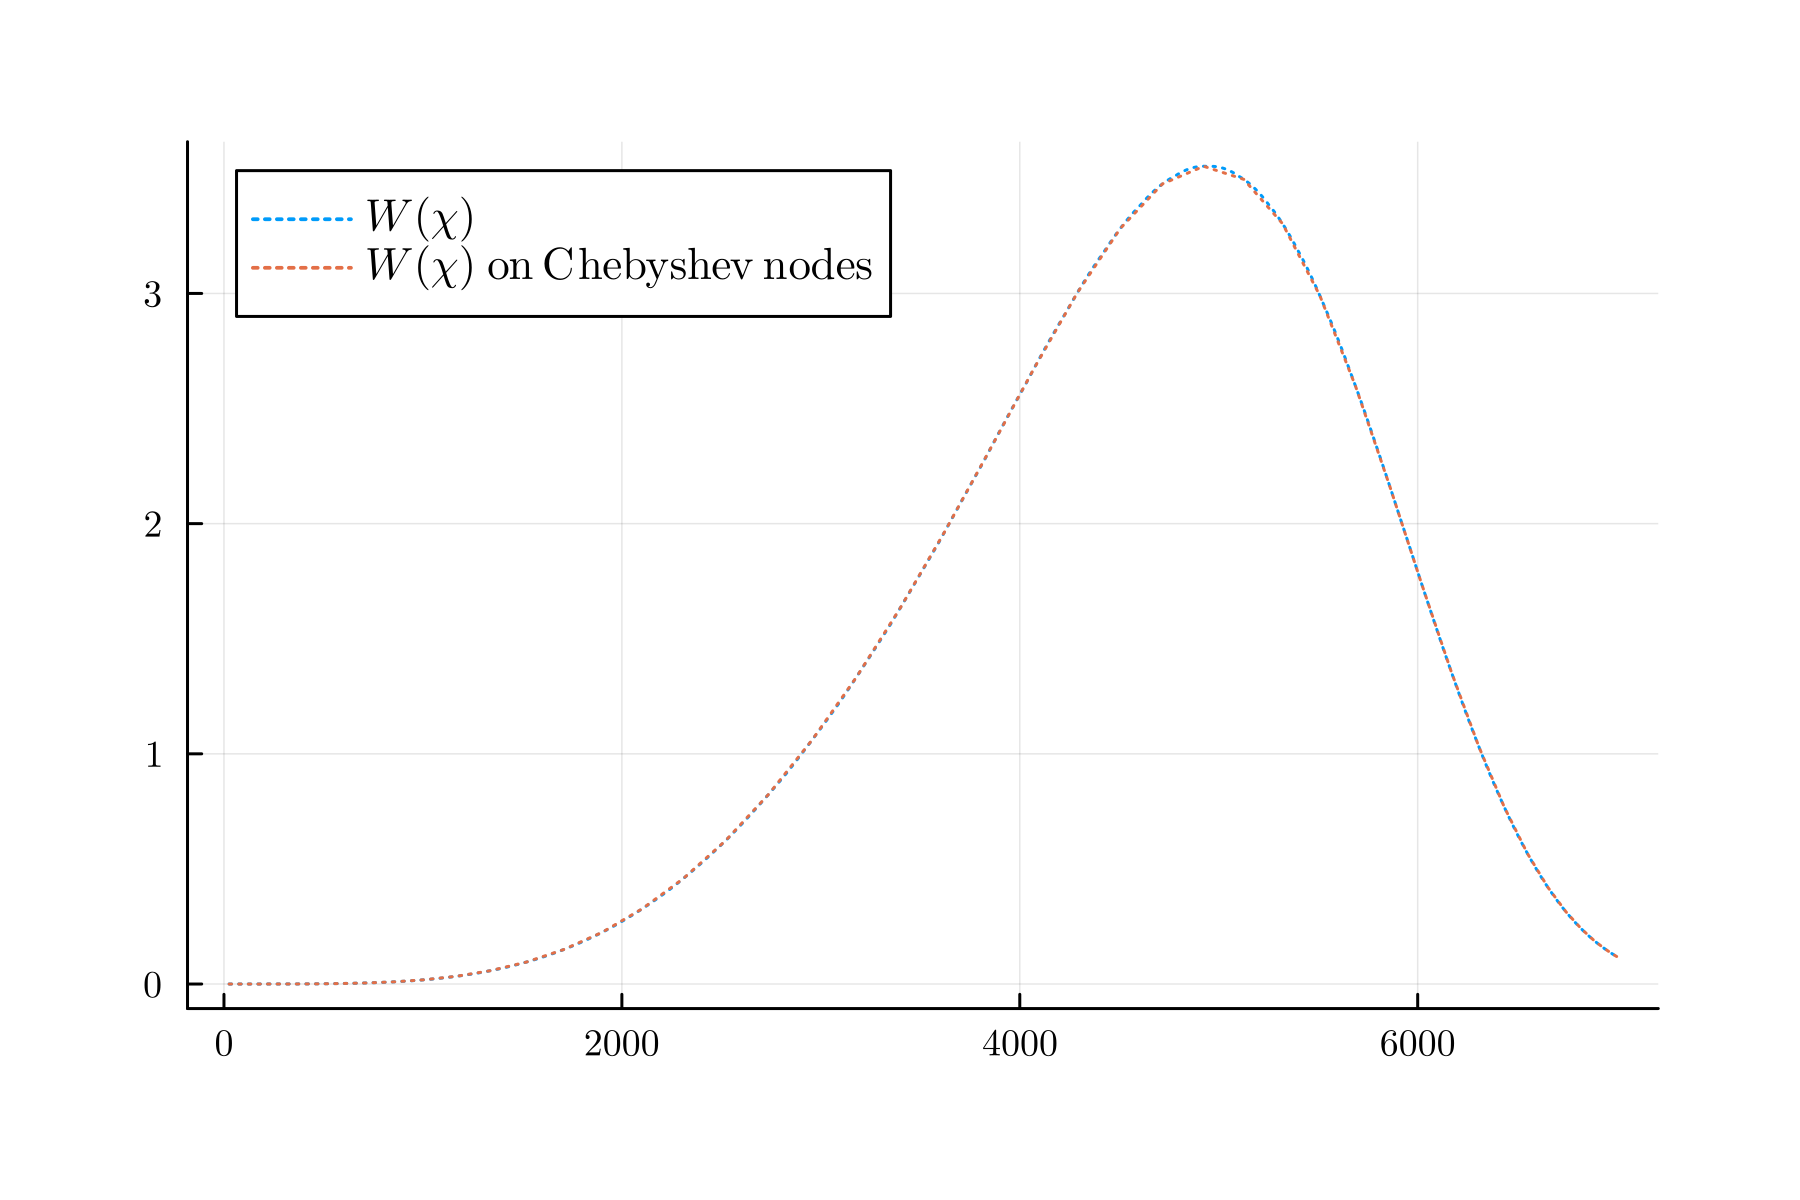

In [617]:
plot(grid_data.x, W_x, label = L"W(\chi)", lw=1, ls=:dot; markercolor = :green, plot_theme.shared_style...)
plot!(x_cheb, W_cheb, label = L"W(\chi) \; \mathrm{on} \; \mathrm{Chebyshev} \; \mathrm{nodes}", lw=1, ls=:dot; markercolor =:red, plot_theme.shared_style...)

In [618]:
savefig(joinpath(paths.plot_subdir, "kernels/W_x_and_W_cheb.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/kernels/W_x_and_W_cheb.png"

In [619]:
# if grids.sorting == true
#   W_x_on_cheb = W_x_on_cheb[end:-1:1]; #this is the same as doing W_cheb_ord = W_cheb[end:-1:1];
# end
z_cheb_plot = z_interp.(x_cheb)
if grids.sorting == true
  W_x_on_cheb , _, _, _, _ = galaxy_galaxy.galaxy_prefactor(x_cheb, z_cheb_plot, grid_data.cosmo; output_dir=paths.output_dir);
end
W_x_on_cheb , _, _, _, _ = galaxy_galaxy.galaxy_prefactor(x_cheb_plot, z_cheb_plot, grid_data.cosmo; output_dir=paths.output_dir);
rel_err = (W_cheb ./ W_x_on_cheb .- 1)
rel_err_abs = abs.(rel_err)
rel_err_pct = 100 .* rel_err
rel_err_pct_abs = 100 .* rel_err_abs
;

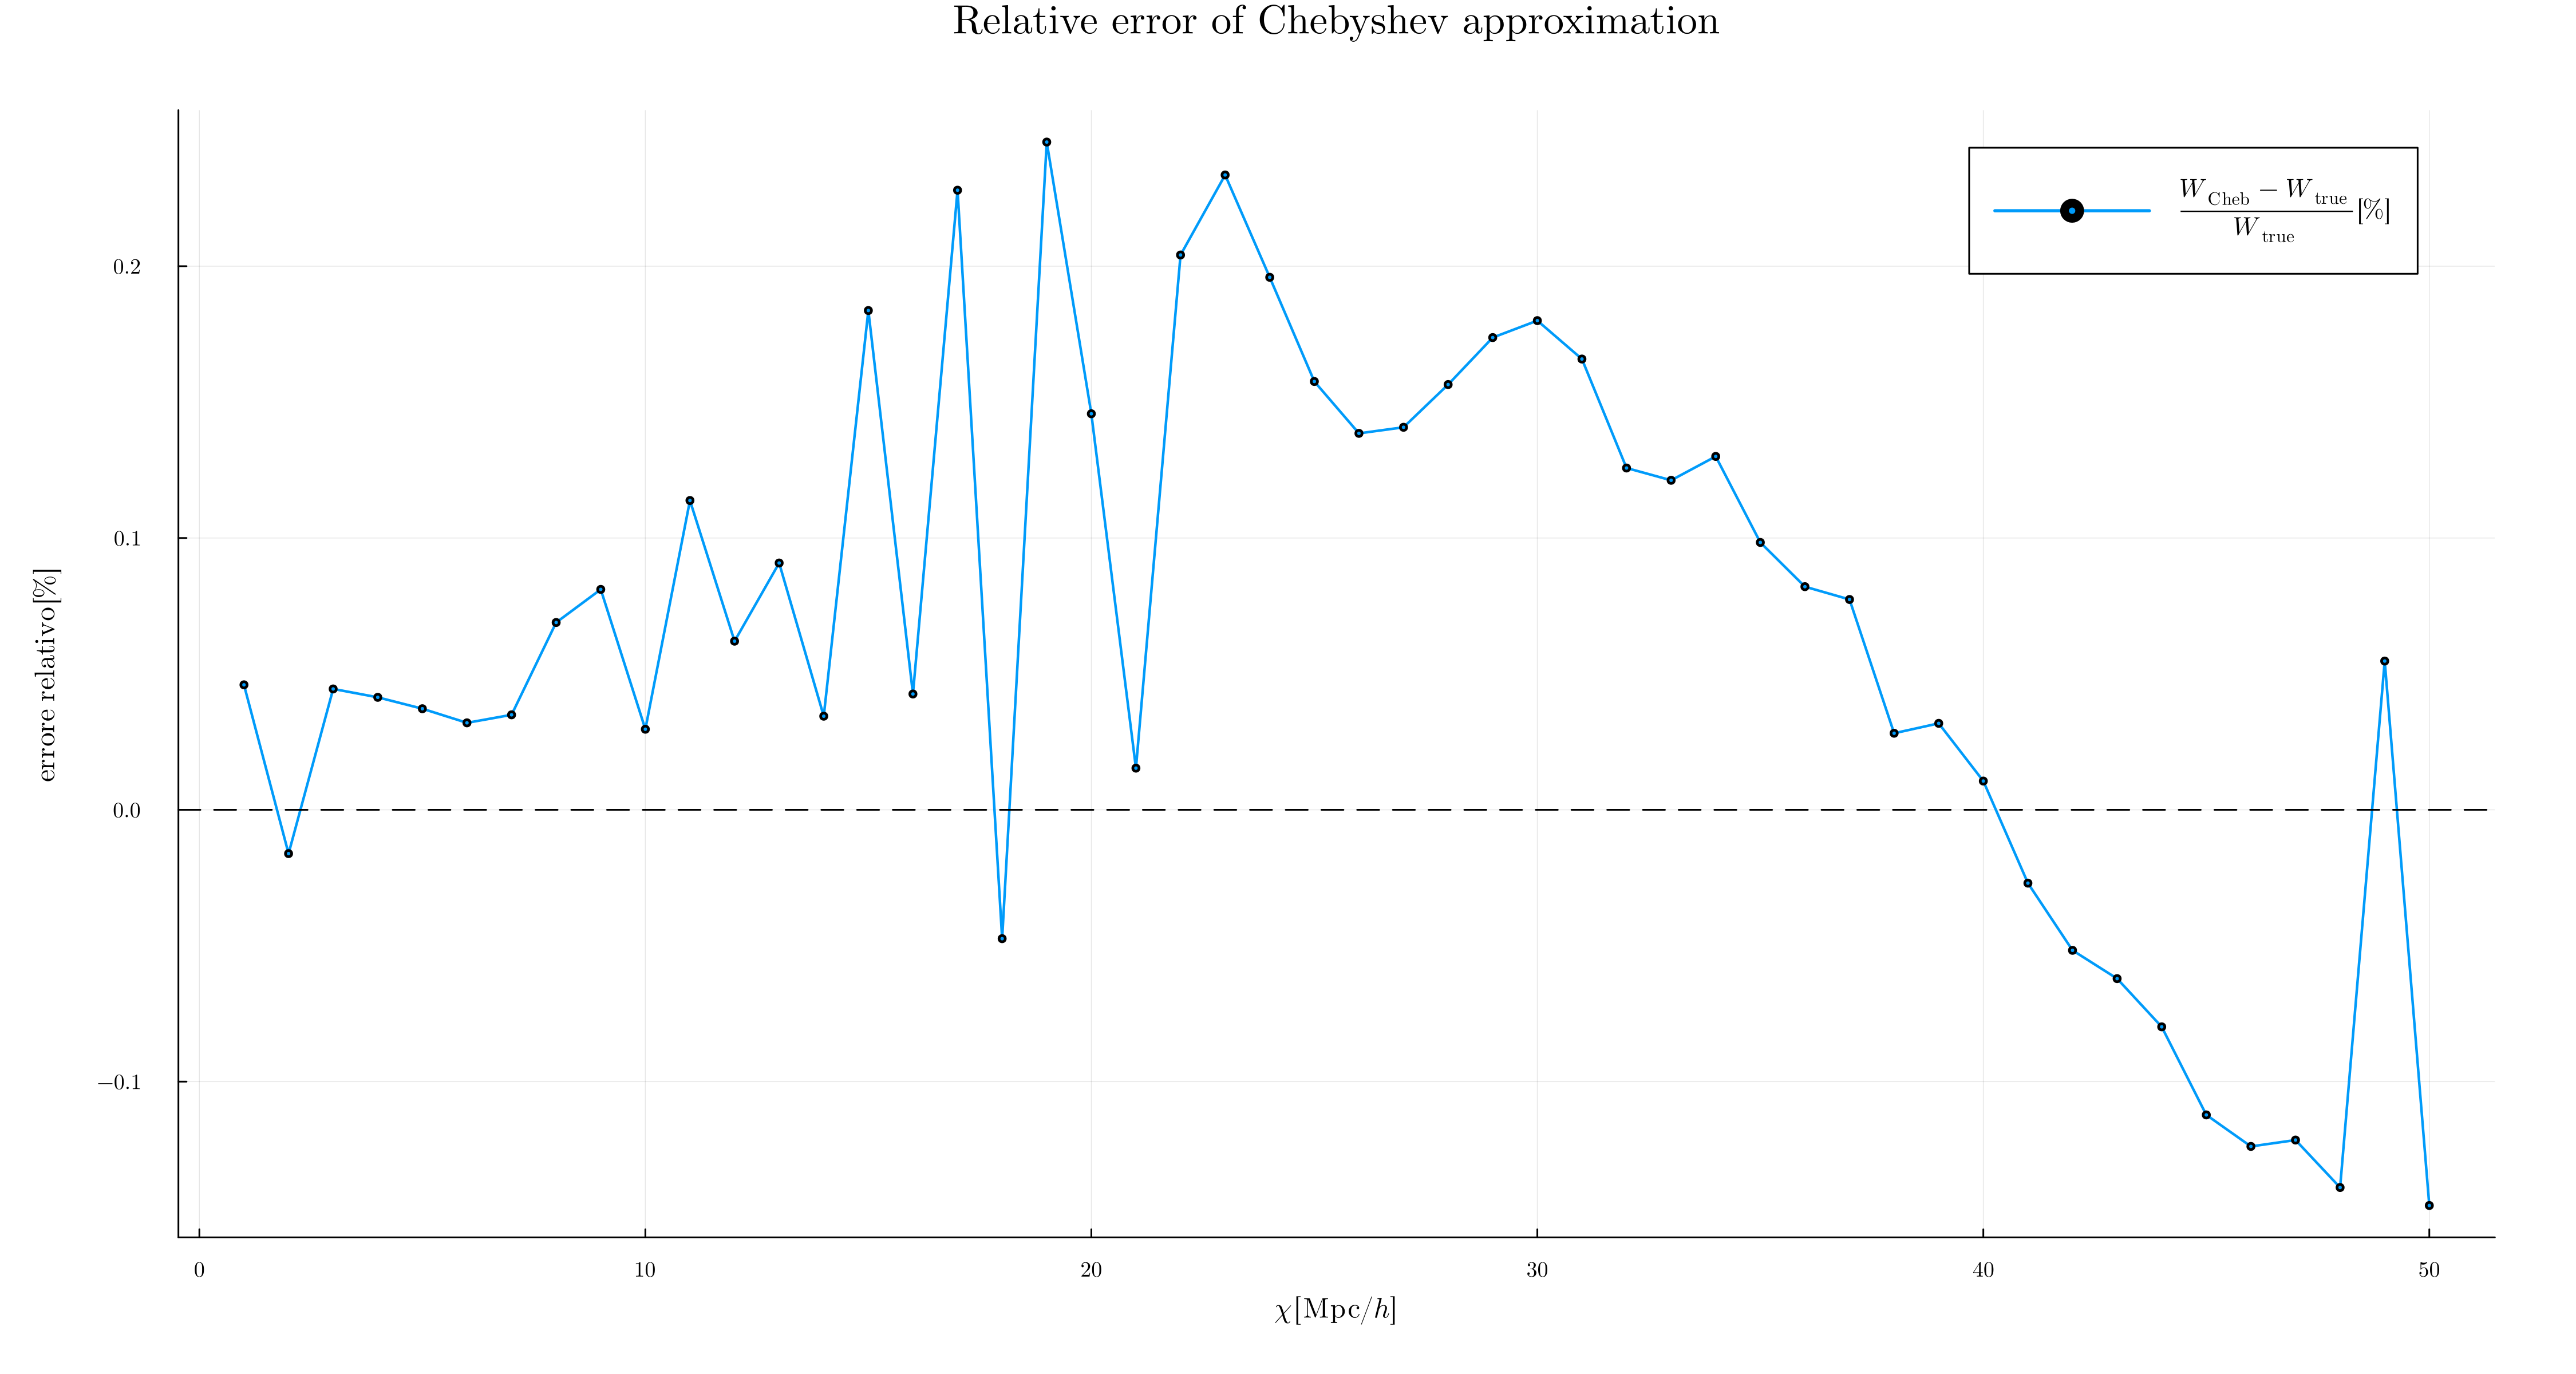

In [620]:
plot(
    1:grid_data.n_cheb, 
    rel_err_pct,
    label = L"\frac{W_{\mathrm{Cheb}} - W_{\mathrm{true}}}{W_{\mathrm{true}}}\,[\%]",
    lw = 1.5,
    marker = :circle,
    markersize = 2,
    legendposition = :topright,
    xlabel = L"\chi\,[\mathrm{Mpc}/h]",
    ylabel = L"\mathrm{errore\ relativo}\,[\%]",
    title = "Relative error of Chebyshev approximation", size=plot_theme.size_Cl; plot_theme.shared_style...
    )

hline!([0.0], ls = :dash, lw = 1, color = :black, label = false)

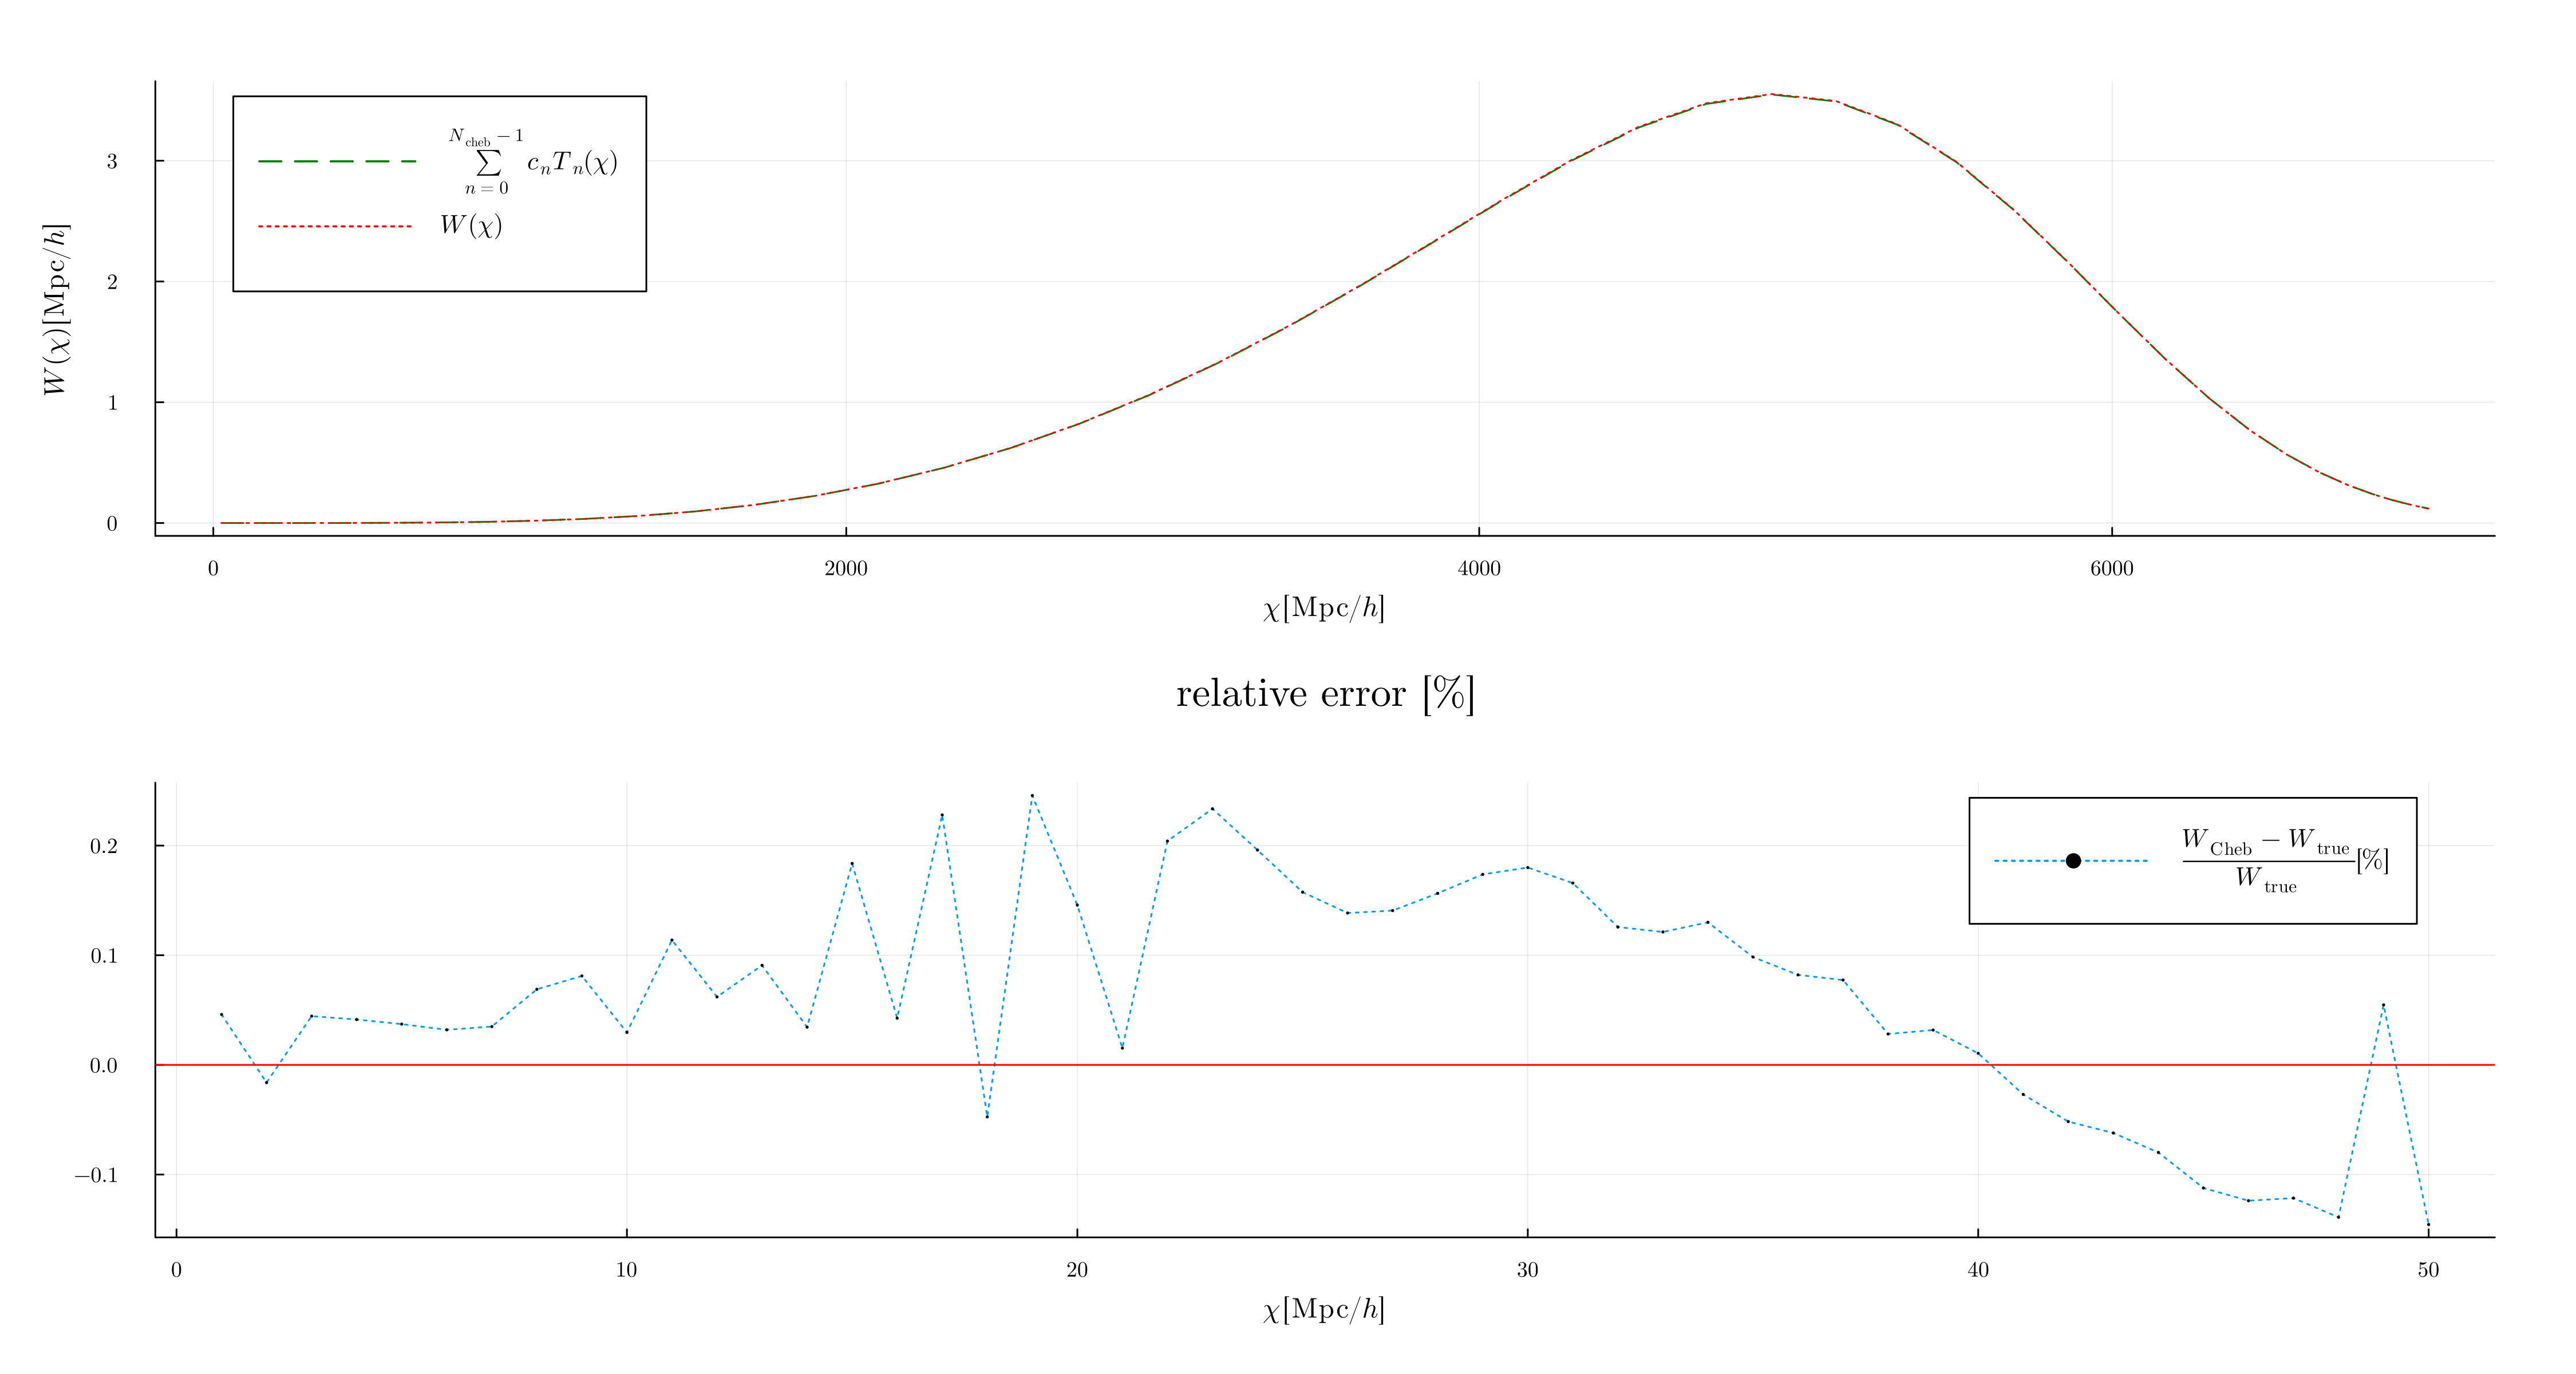

In [621]:
p1 = plot(
    sort(x_cheb_plot), W_x_on_cheb,
    label = L"\sum_{n=0}^{N_{\mathrm{cheb}}-1} c_n T_n(\chi)",
    ls = :dash, color = :green)
plot!(p1, x_cheb, W_cheb, label = L"W(\chi)", lw = 1, ls = :dot, color = :red)
plot!(p1, dpi = 300, legendposition = :topleft, xlabel = L"\chi [Mpc/h]", ylabel = L"W(\chi) [\mathrm{Mpc}/h]", 
        size = plot_theme.size_Cl; plot_theme.shared_style...
        )
    
p2 = plot(
    1:grid_data.n_cheb, rel_err_pct,
    label = L"\frac{W_{\mathrm{Cheb}} - W_{\mathrm{true}}}{W_{\mathrm{true}}} [\%]",
    lw = 1.0, marker = :circle, markercolor = :black, markersize = 1, linestyle = :dot, 
    title = "relative error [%]", titlefontsize = 10
)
hline!(p2, [0.0], ls = :solid, lw = 1, color = :red, label = false)

plot(p1, p2, layout = @layout([a; b]), dpi = 300,
     xlabel = L"\chi\,[\mathrm{Mpc}/h]",
    size = plot_theme.size_Cl; plot_theme.shared_style...)

In [622]:
n_idx = 0:(grid_data.n_cheb - 1)
plot(n_idx, abs.(c_cheb),
     yscale = :log10,
     xlabel = L"c_{grid_{data}.n_{cheb}}",
     ylabel = L"|c_{grid_{data}.n_{cheb}}|",
     label = L"|c_{grid_{data}.n_{cheb}}| \ \mathrm{di} \ W(\chi)",
     title = "Chebyshev coefficients decay",
     marker = :circle, markersize = 3; plot_theme.shared_style...
     )
savefig(joinpath(paths.plot_subdir, "kernels", "chebcoeff_decay_galaxy.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/kernels/chebcoeff_decay_galaxy.png"

In [623]:
function cheb_eval_partial(coeffs, x, xmin, xmax, ntrunc)
    t = @. (2*x - (xmax + xmin)) / (xmax - xmin)
    T0 = ones(length(x))
    if ntrunc == 0
        return coeffs[1] .* T0
    end
    T1 = t
    S = coeffs[1] .* T0 .+ coeffs[2] .* T1
    for n in 2:ntrunc
        T2 = @. 2*t*T1 - T0
        S .+= coeffs[n+1] .* T2
        T0, T1 = T1, T2
    end
    return S
end

truncs = 1:1:length(c_cheb)-1
errs = Float64[]
Wn = zeros(length(x_cheb))
for ntrunc in truncs
    Wn = cheb_eval_partial(c_cheb, x_cheb, grid_data.xmin, grid_data.xmax, ntrunc)
    err = maximum(abs.(Wn .- W_cheb)) / maximum(abs.(W_cheb))
    push!(errs, err)
end

truncs_plot = truncs[1:end]
errs_plot = errs[1:end]
yticks_vals = 10.0 .^ (floor(log10(minimum(errs_plot))):ceil(log10(maximum(errs_plot))))

plot(truncs_plot, errs_plot,
     yscale = :log10,
     marker = :circle,
     xlabel = L"N_{trunc}",
     ylabel = L"\mathrm{err}(N_{trunc}) = \frac{\max_i |W_{N_{trunc}} - W(\chi_i)|}{\max_i |W(\chi_i)|}",
     title  = L"\mathrm{err}(N_{trunc}) = \frac{\max_i |W_{N_{trunc}} - W(\chi_i)|}{\max_i |W(\chi_i)|}",
     legend = false,
     framestyle = :box,
     yticks = yticks_vals, size=plot_theme.size_Cl; plot_theme.shared_style...
     )
savefig(joinpath(paths.plot_subdir, "kernels", "chebcoeff_truncation_error_galaxy.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/kernels/chebcoeff_truncation_error_galaxy.png"

$W_{tilde} = \int dz W(z) j_l(k\chi(z)) j_l(k_1\chi(z))$

$\tilde W_{\ell}^g(k1,k) \approx \sum_{n=0}^{N_{cheb}-1} c_n \int_{z_{min}}^{z_{max}} dz T_n(\hat z) k_1 j_l(k\chi(z)) j_l(k_1\chi(z))$

Computing $\tilde W(k, k_1)$...

$\mathrm{N} = 2^{15}+1$, $\mathrm{N_k} = \mathrm{N_{kp}} = \mathrm{N_{kpp}} = 150$, $\mathrm{N_{cheb}} = 200$, $\mathrm{len}(ℓ) = 100$


In [625]:
W_tilde = zeros(grid_data.Nk, grid_data.Nkp, grid_data.n_cheb, length(grid_data.ℓ))
if reuse
  if mode == "slow"
    W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/no_sorting_run_2026_07_20_102547/quantities/W_tilde.npy")
  else
    W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/yes_sorting_run_2026_07_20_104650/quantities/W_tilde.npy")
  end
else
  p = Progress(length(grid_data.ℓ); desc = "Computing W_tilde")
  elapsed_time = zeros(length(grid_data.ℓ))
  println("Dimensions of W_tilde: ", size(W_tilde))
  for i in eachindex(grid_data.ℓ)
      t_0 = time()
      W_tilde[:, :, :, i] .= Blast.W_tilde_computation(grid_data.ℓ[i], grid_data.zmin, grid_data.zmax, grid_data.kmin, grid_data.kmax,
      grid_data.Nk, grid_data.Nkp, grid_data.n_cheb, grid_data.N, grids.k_grid, grids.kp_grid, grids.kpp_grid, grids.sorting)
      t_end = time()
      elapsed_time[i] = t_end - t_0
      next!(p; showvalues = [(:ℓ, grid_data.ℓ[i]), (:dt, round(elapsed_time[i], digits=2))])
  end
end
;

Computing W_tilde 100%|██████████████████████████████████| Time: 0:03:07
    ℓ: 200.0
   dt: 1.78


Saving $\tilde W(k, k_1)$ and printing its dimensions...

In [626]:
if reuse == false
  npzwrite(joinpath(paths.quantity_subdir, "W_tilde.npy"), W_tilde)
end
println("Size of W_tilde: (Nk, Nkp, Ncheb, Nℓ)")
println("Size of W_tilde: ", size(W_tilde))

Size of W_tilde: (Nk, Nkp, Ncheb, Nℓ)
Size of W_tilde: (150, 150, 50, 100)


$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

Computing $\tilde W_{final}$ by contracting $\tilde W$ with $c_{cheb}$ and printing its dimensions...

In [627]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * c_cheb[ic]

println("Size of W_final_gal: (Nℓ, Nk, Nkp)")
println("Size of W_final_gal: ", size(W_final_gal))
;

Size of W_final_gal: (Nℓ, Nk, Nkp)
Size of W_final_gal: (100, 150, 150)


When sorting is set to true, the $k_{grid}$ has $k_{grid}[1] \approx k_{min}$, and $k_{grid}[end] \approx k_{max}$. \
When sorting is set to false, the $k_{grid}$ has $k_{grid}[1] \approx k_{max}$, and $k_{grid}[end] \approx k_{min}$.

In [628]:
println("sorting = ", grids.sorting)
println("k_grid[1]: ", grids.k_grid[1])
println("k_grid[end]: ", grids.k_grid[end])

sorting = true
k_grid[1]: 0.000357142857142857
k_grid[end]: 15.384615384615389


In [629]:
idx = sortperm(grids.k_grid) #idx = 150, 149, ..., 1
idx_p = sortperm(grids.kp_grid) #idx_p = 150, 149, ..., 1
println("idx[1]: ", idx[1], ", idx[end]: ", idx[end])
println("idx_p[1]: ", idx_p[1], ", idx_p[end]: ", idx_p[end])
;

idx[1]: 1, idx[end]: 150
idx_p[1]: 1, idx_p[end]: 150


In [630]:
println("k_grid[idx[1]]: ", grids.k_grid[idx[1]])
println("k_grid[idx[end]]: ", grids.k_grid[idx[end]])

k_grid[idx[1]]: 0.000357142857142857
k_grid[idx[end]]: 15.384615384615389


In [631]:
println("W_tilde[k_grid[idx[1]], kp_grid[idx_p[1]], 1, 1]: ", W_tilde[idx[1], idx_p[1], 1, 1])
println("W_tilde[k_grid[1], kp_grid[1], 1, 1]: ", W_tilde[1, 1, 1, 1])
println("W_tilde[k_grid[idx[end]], kp_grid[idx_p[end]], 1, 1]: ", W_tilde[idx[end], idx_p[end], 1, 1])
println("W_tilde[k_grid[end], kp_grid[end], 1, 1]: ", W_tilde[end, end, 1, 1])

W_tilde[k_grid[idx[1]], kp_grid[idx_p[1]], 1, 1]: 2.9057599696618265e-18
W_tilde[k_grid[1], kp_grid[1], 1, 1]: 2.9057599696618265e-18
W_tilde[k_grid[idx[end]], kp_grid[idx_p[end]], 1, 1]: 0.3049444162012587
W_tilde[k_grid[end], kp_grid[end], 1, 1]: 0.3049444162012587


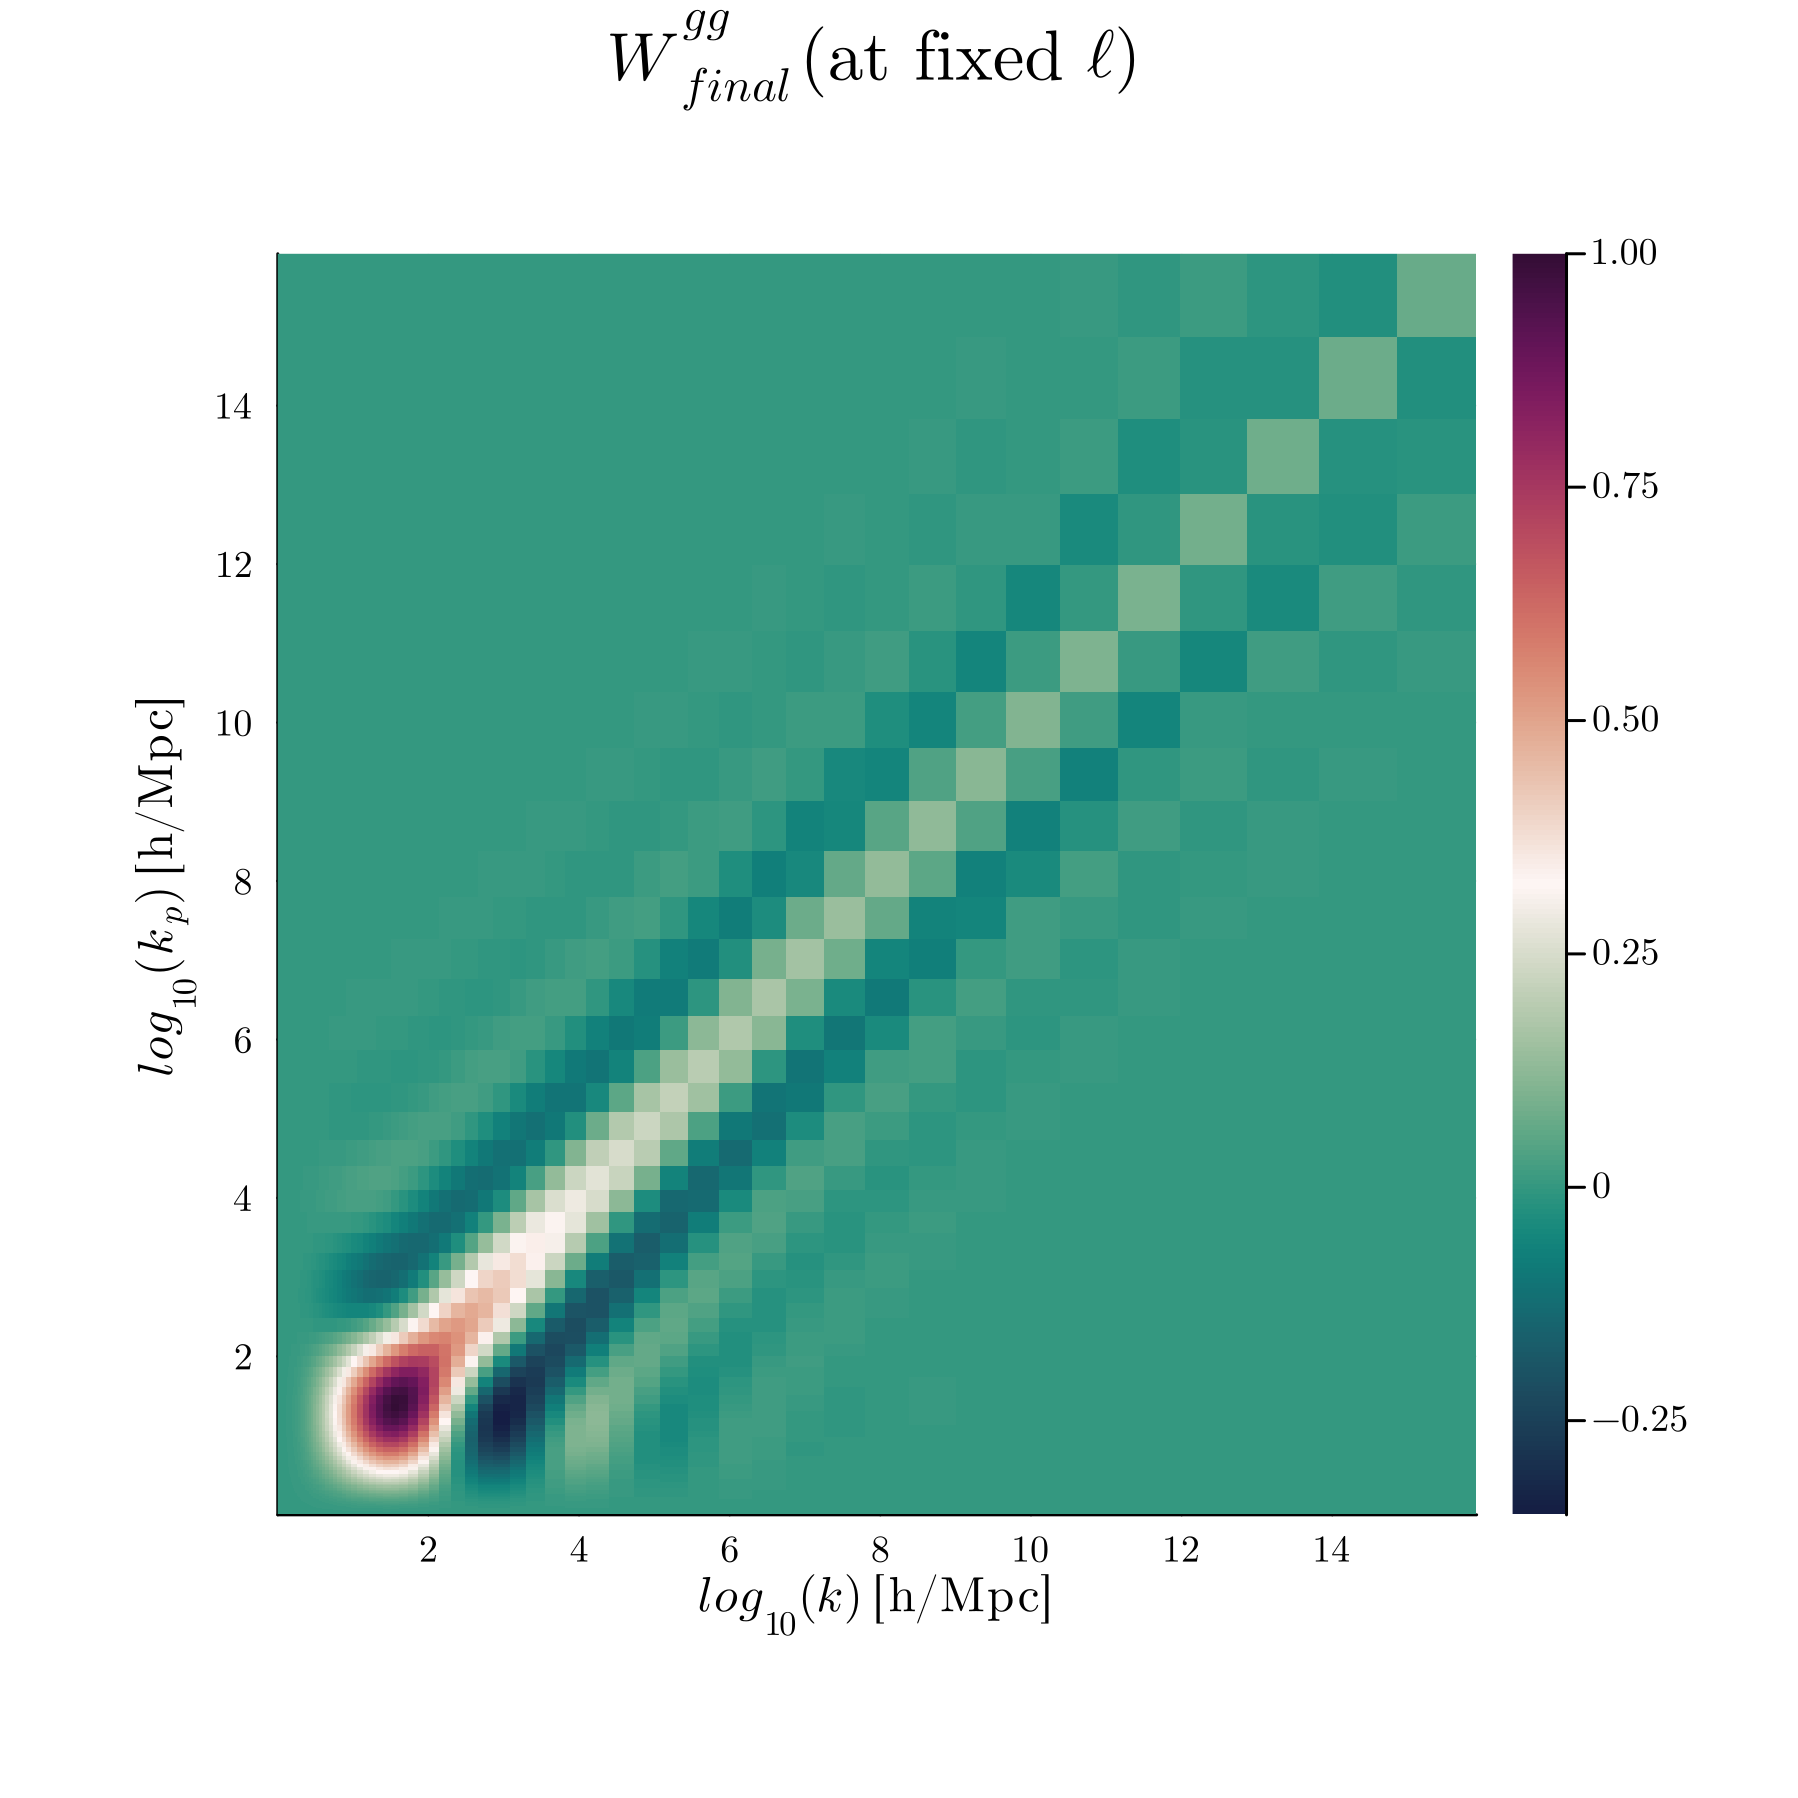

In [632]:
# genera tick automatici alle potenze di 10 nel range dei dati
xticks_vals = 10.0 .^ (floor(log10(minimum(grids.k_grid))):ceil(log10(maximum(grids.k_grid))))
yticks_vals = 10.0 .^ (floor(log10(minimum(grids.kp_grid))):ceil(log10(maximum(grids.kp_grid))))
il = 1
if grids.sorting == true
        heatmap(grids.k_grid, grids.kp_grid,
                W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                #xscale = :log10, 
                #yscale = :log10,
                xlabel=L"log_{10}(k) \; [\mathrm{h/Mpc}]", ylabel=L"log_{10}(k_p) \; [\mathrm{h/Mpc}]",
                size = plot_theme.size_heatmap,
                c = plot_theme.c, 
                # xticks = xticks_vals, 
                # yticks = yticks_vals
                ; 
                plot_theme.shared_style...
                )
else
        heatmap(grids.k_grid[idx], grids.kp_grid[idx_p],
                W_final_gal[il,idx,idx_p]/maximum(W_final_gal[il,idx,idx_p]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xscale = :log10, 
                yscale = :log10,
                xlabel=L"k", ylabel=L"k_p",
                size = plot_theme.size_heatmap,
                c = plot_theme.c, 
                xticks = xticks_vals, 
                yticks = yticks_vals
                ; 
                plot_theme.shared_style...
                )
end

In [633]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_k_k1_log.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/heatmaps/heatmap_k_k1_log.png"

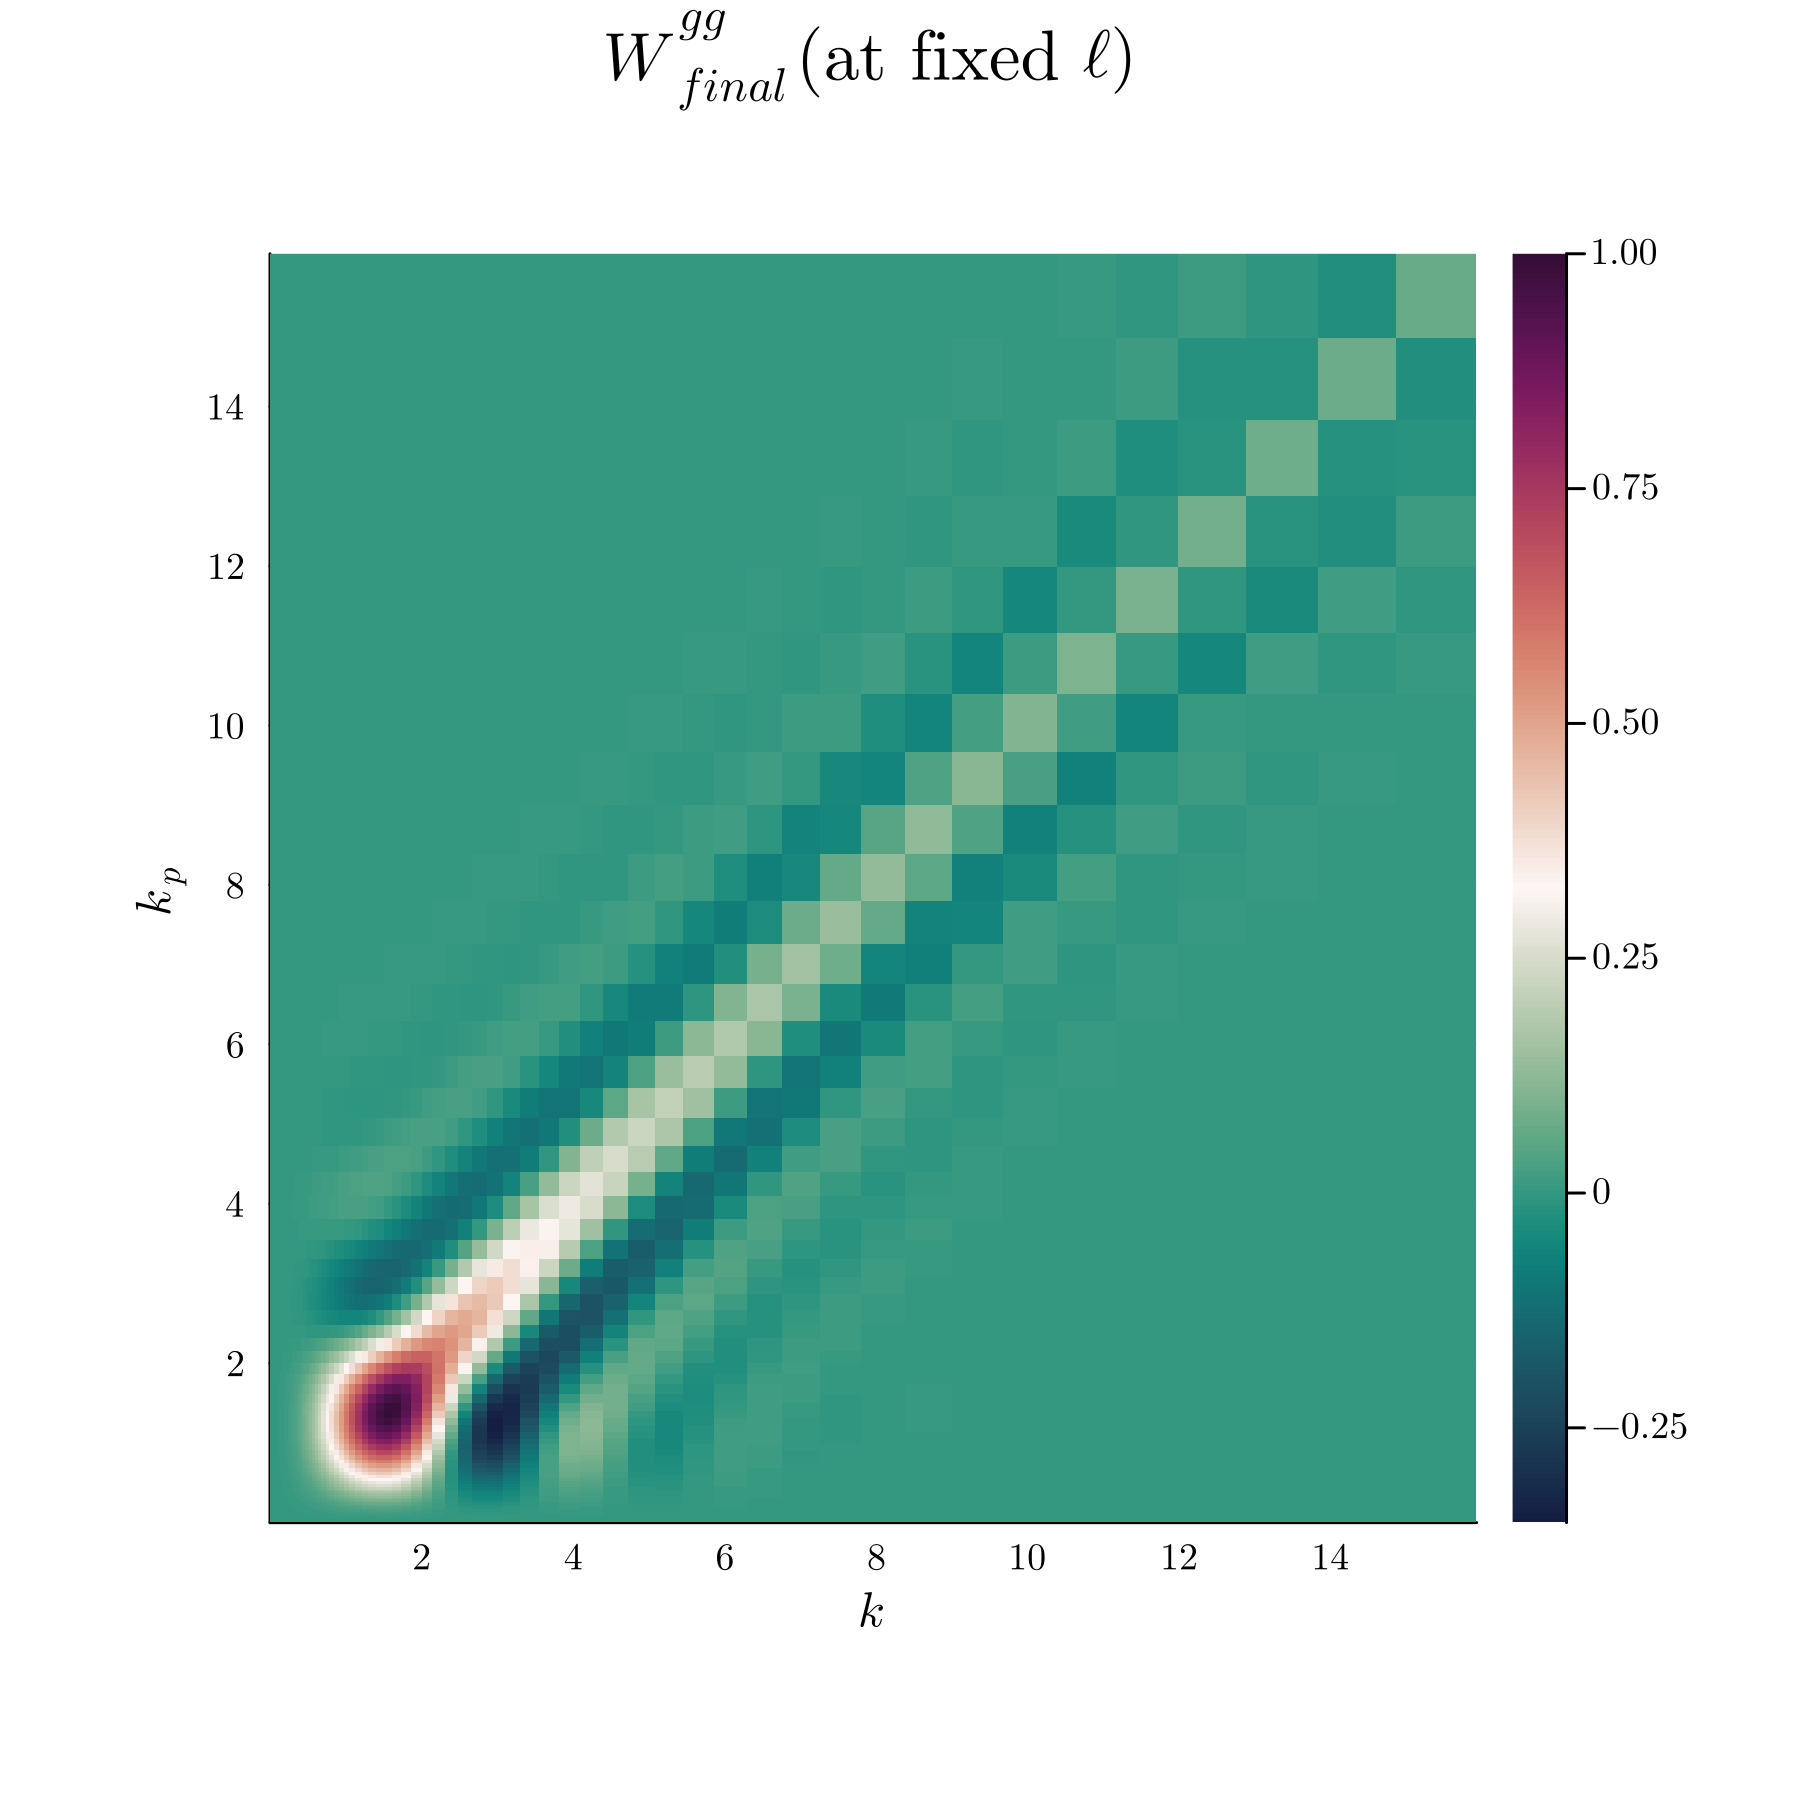

In [634]:
il = 1
if grids.sorting == true
        heatmap(grids.k_grid, grids.kp_grid,
                W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xlabel=L"k", ylabel=L"k_p",
                size = plot_theme.size_heatmap,
                c = plot_theme.c; 
                plot_theme.shared_style...
                )
else
         heatmap(grids.k_grid[idx], grids.kp_grid[idx_p],
                W_final_gal[il,idx,idx_p]/maximum(W_final_gal[il,idx,idx_p]),
                title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
                xlabel=L"k", ylabel=L"k_p",
                size = plot_theme.size_heatmap,
                c = plot_theme.c; 
                plot_theme.shared_style...
                )
end

In [635]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_k_k1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/heatmaps/heatmap_k_k1.png"

In [636]:
println(size(W_tilde))

(150, 150, 50, 100)


In [637]:
println(1:grid_data.Nk)

1:150


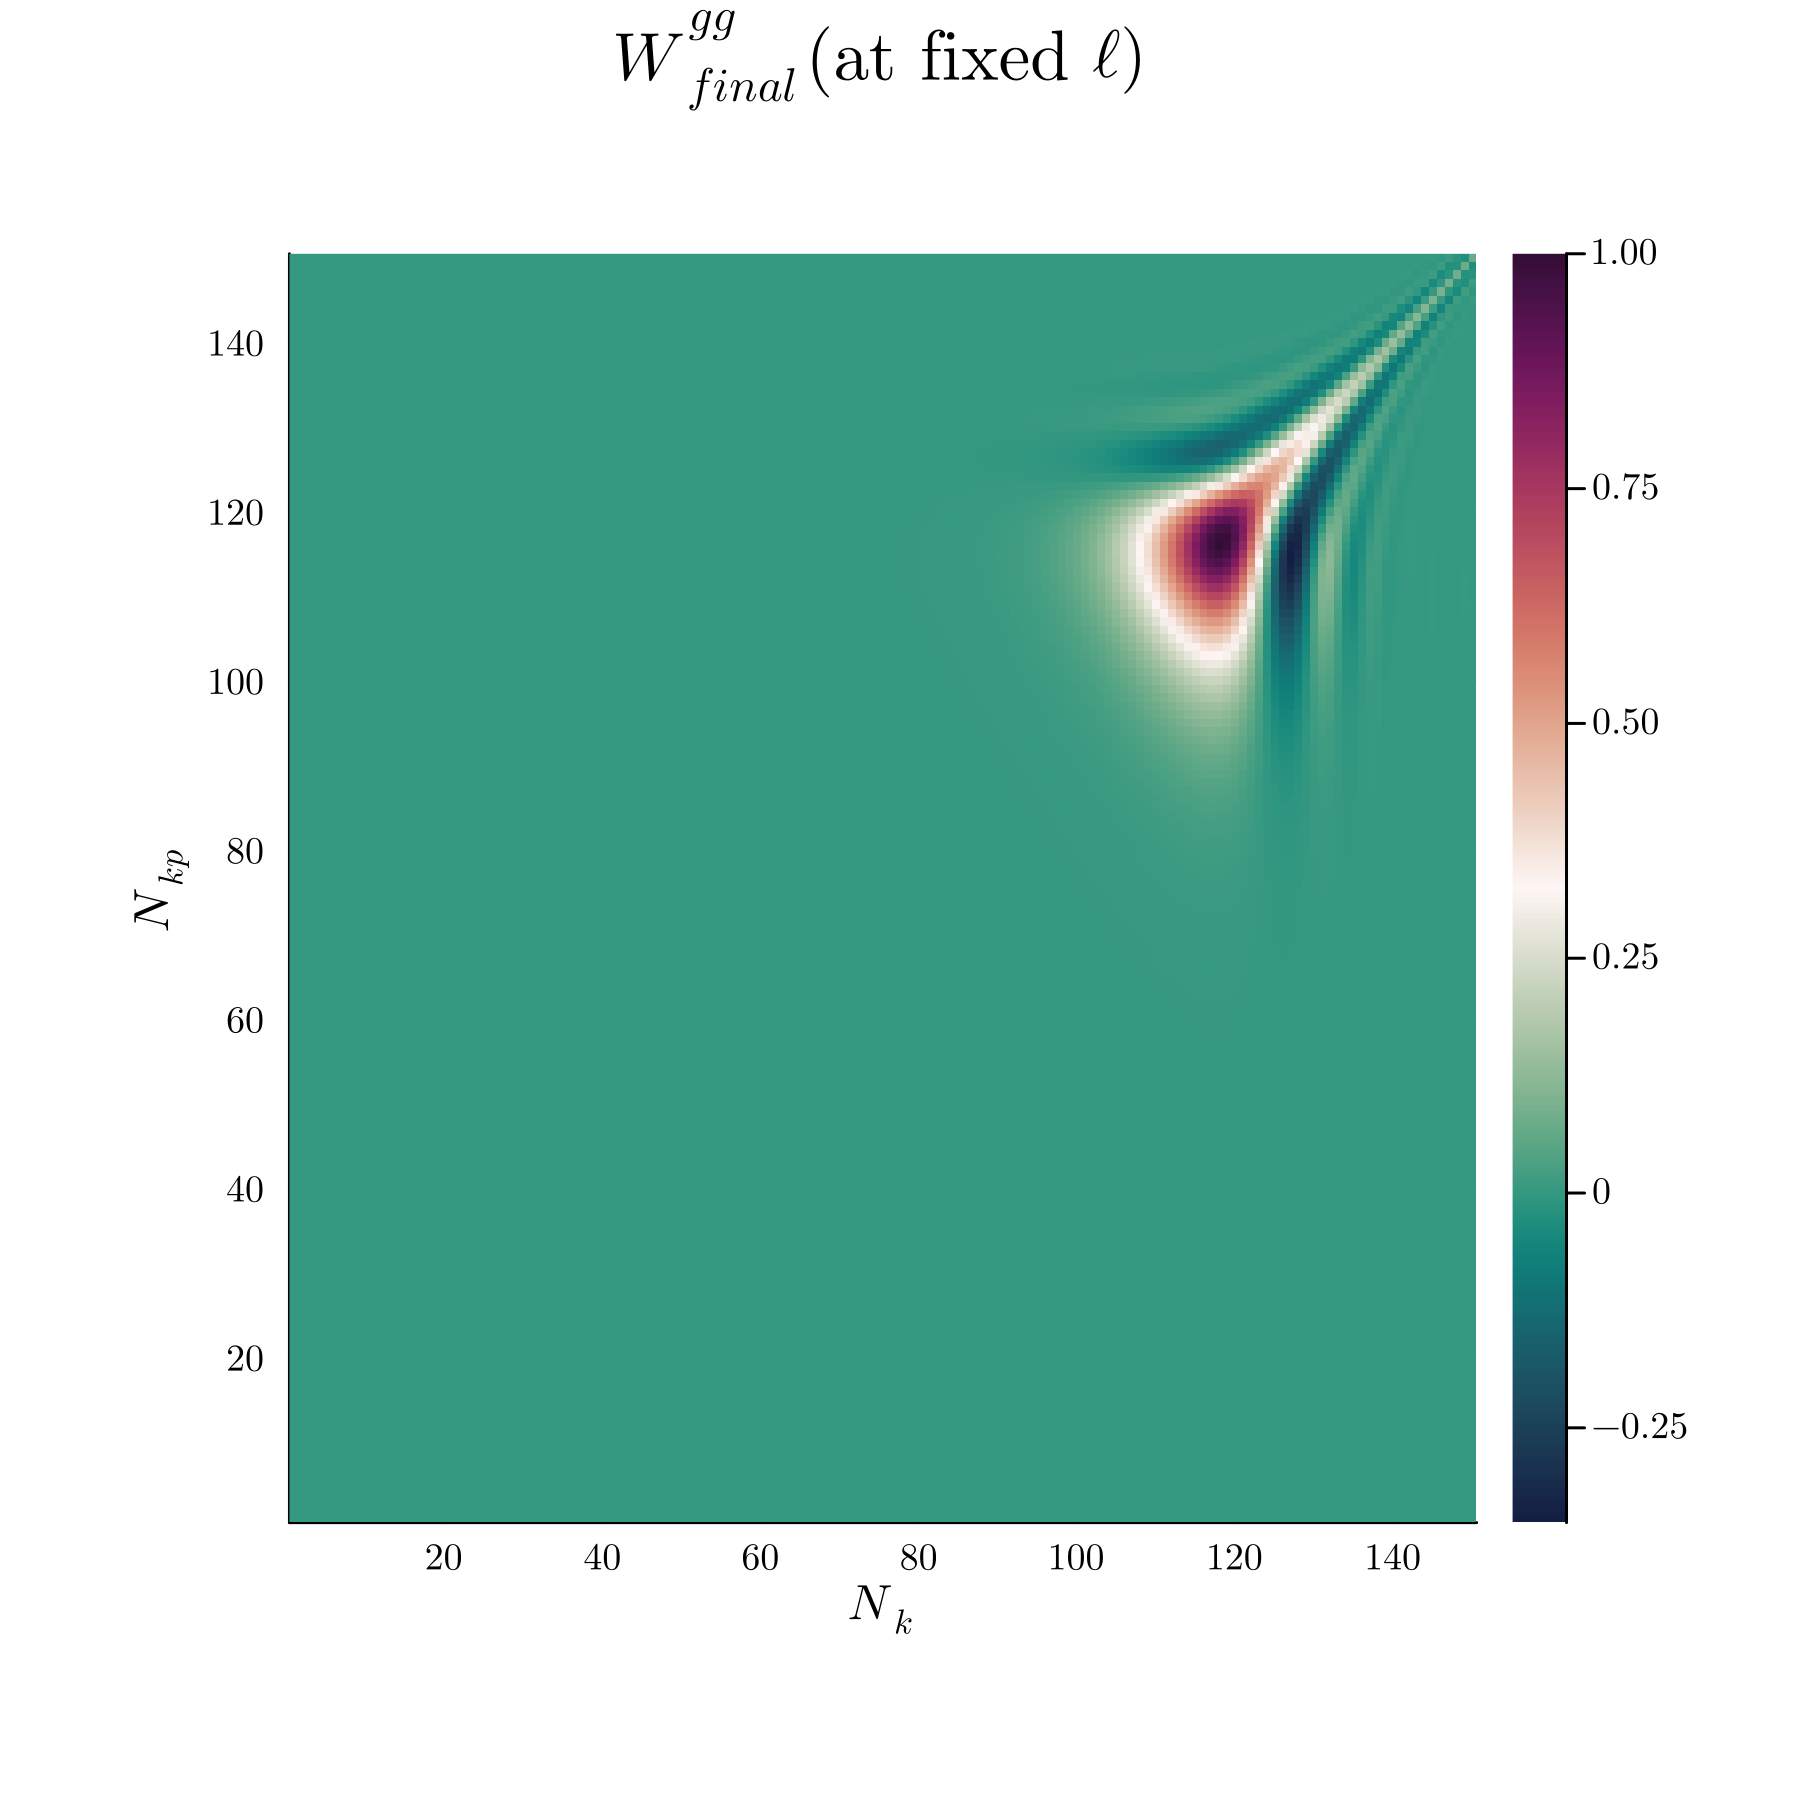

In [638]:
il = 1
if grids.sorting == true
    heatmap(1:grid_data.Nk, 1:grid_data.Nkp, W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]), 
        title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
        xlabel = L"N_k", ylabel = L"N_{kp}", 
        colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
        )
else
    heatmap(1:grid_data.Nk, 1:grid_data.Nkp, W_final_gal[il,:,:]/maximum(W_final_gal[il,:,:]), 
        title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
        xlabel = L"N_k", ylabel = L"N_{kp}", 
        #xscale = :log10, 
        #yscale = :log10,
        colorbar = true, 
        c = plot_theme.c, 
        size = plot_theme.size_heatmap; plot_theme.shared_style...
        )
end

In [639]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_Nk_Nkp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/heatmaps/heatmap_Nk_Nkp.png"

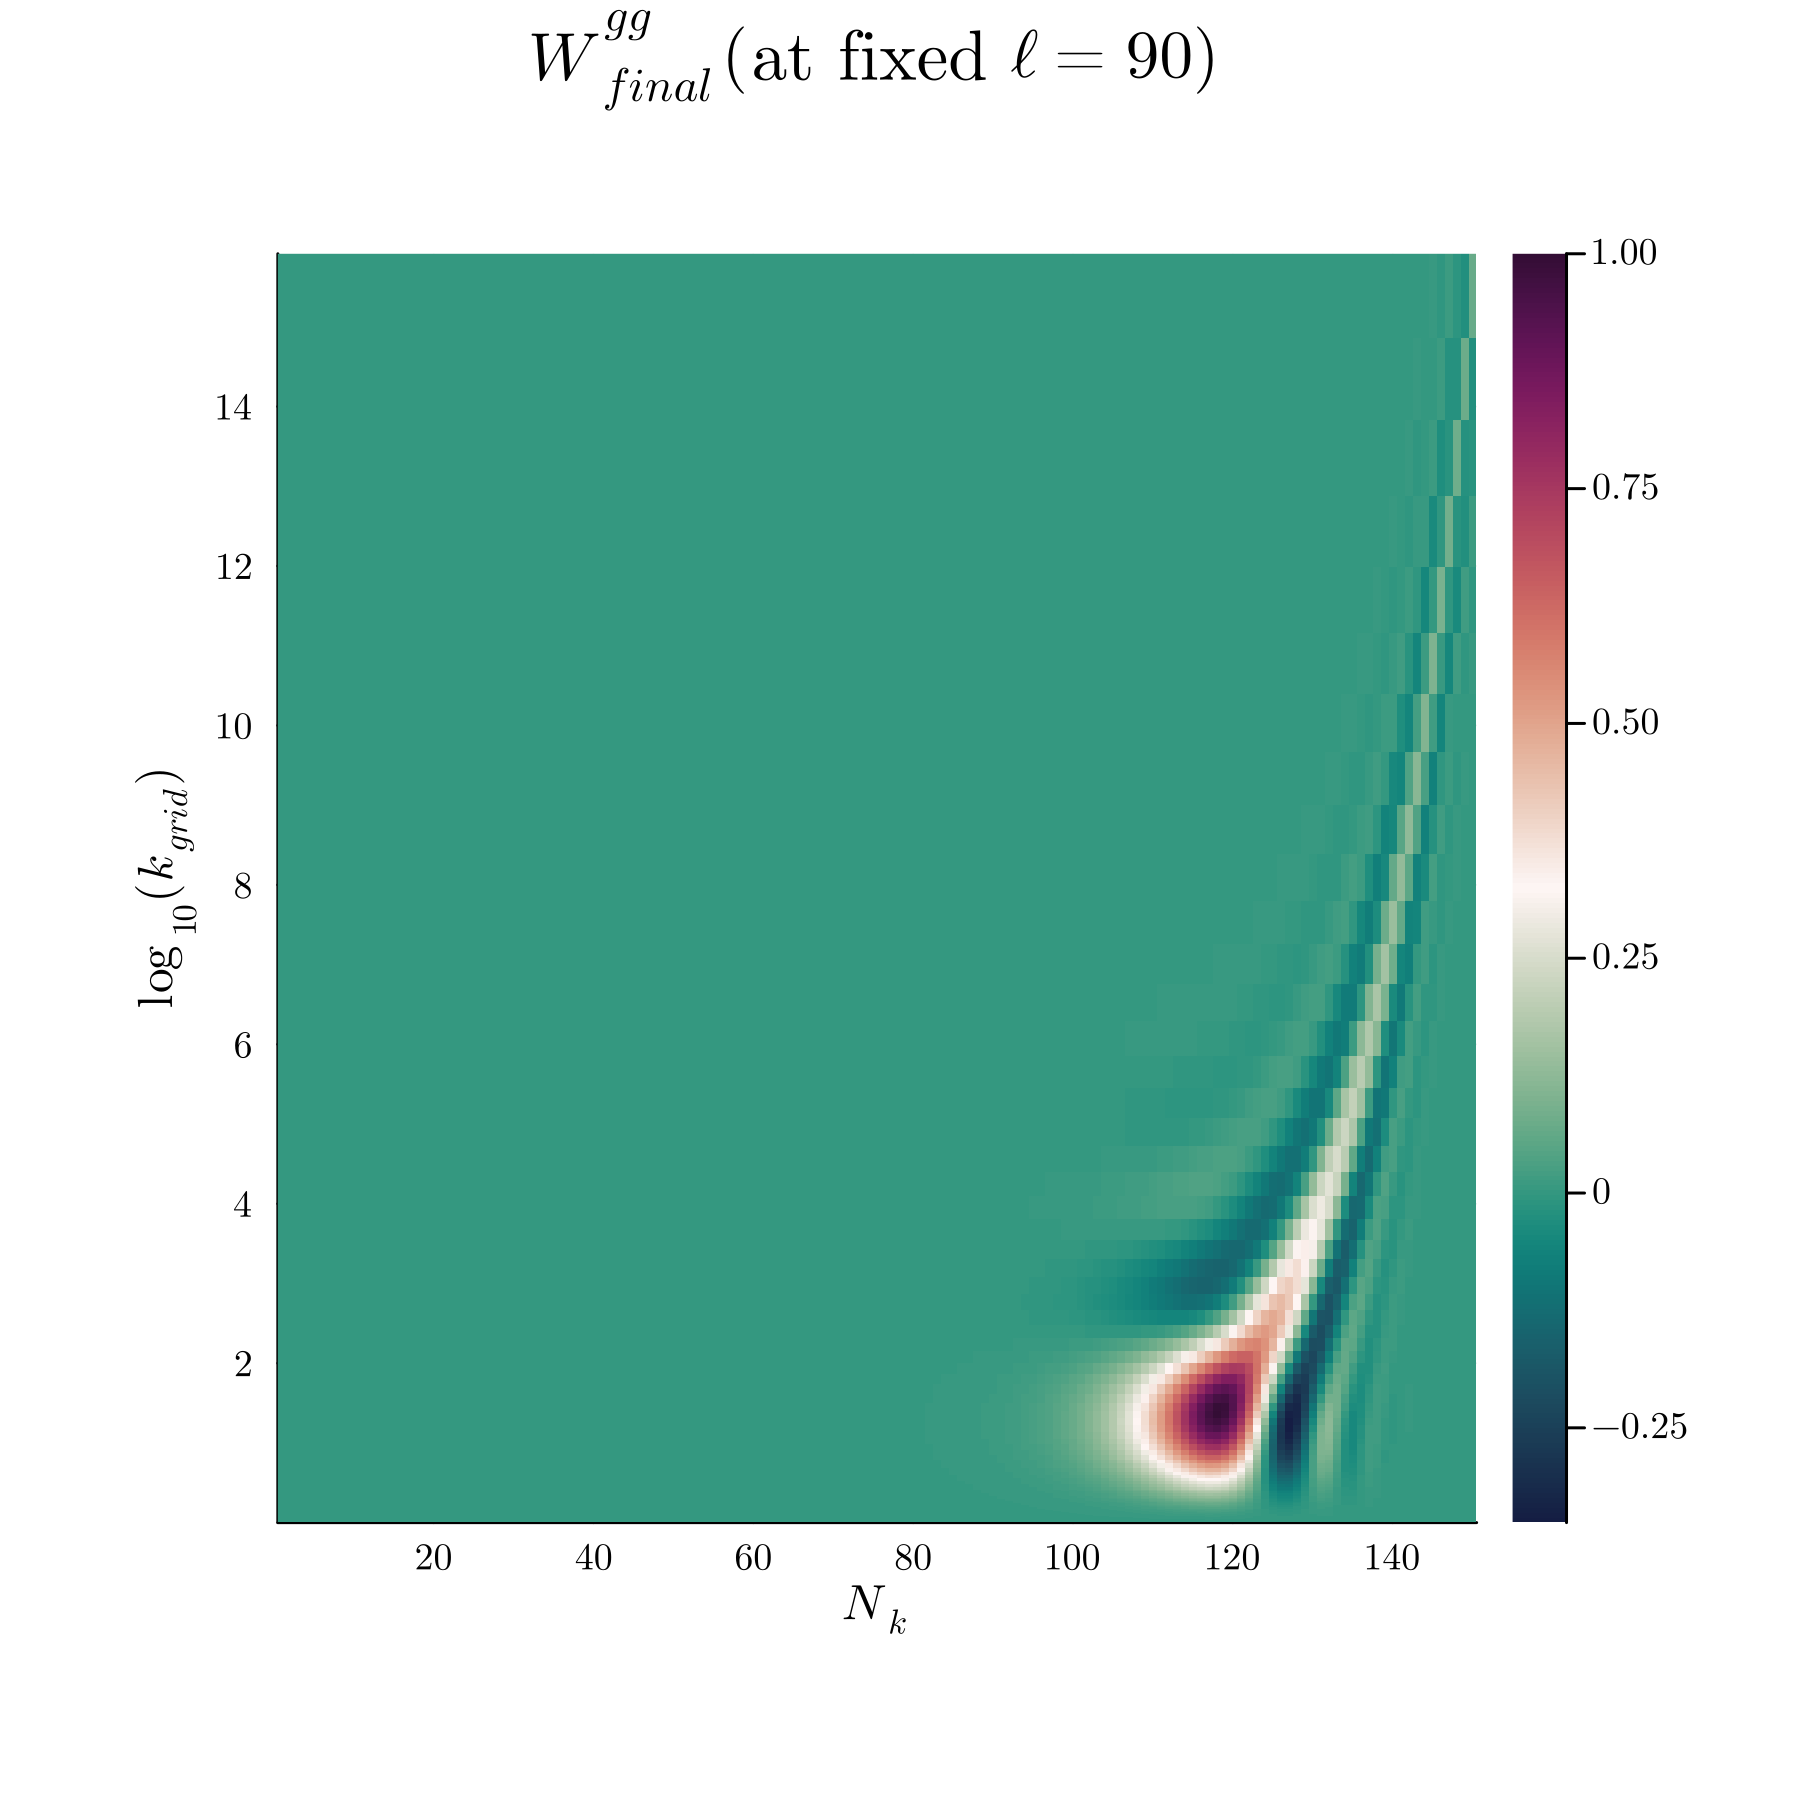

In [640]:
#yticks_vals = 10.0 .^ (floor(log10(minimum(grids.k_grid))):ceil(log10(maximum(grids.k_grid))))
il =1
if grids.sorting == true
        heatmap(1:grid_data.Nk, 
                grids.kp_grid, 
                W_final_gal[il, :, :] / maximum(W_final_gal[il, :, :]), 
                title = L"W_{final}^{gg}"*L"("*"at fixed "*L"ℓ = 90)", 
                xlabel = L"N_k", ylabel = L"\log_{10}(k_{grid})",
                #y_ticks = yticks_vals,
                #yscale = :log10, 
                #xscale = :log10,
                colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
                )
else
        heatmap(1:grid_data.Nk, 
                grids.kp_grid[idx_p], 
                W_final_gal[il, idx, idx_p] / maximum(W_final_gal[il, idx, idx_p]), 
                title = L"W_{final}^{gg}"*L"("*"at fixed "*L"ℓ )", 
                xlabel = L"N_k", ylabel = L"\log_{10}(k_{grid})",
                #y_ticks = yticks_vals,
                #yscale = :log10, 
                #xscale = :log10,
                colorbar = true, c = plot_theme.c, size = plot_theme.size_heatmap; plot_theme.shared_style...
                )
end

In [641]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/heatmaps/heatmap_Nk_kp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/heatmaps/heatmap_Nk_kp.png"

In [642]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k_pk = pk_dict["k"]
z_pk = pk_dict["z"]
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y_pk))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm(grid_data.z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm(grid_data.z_of_χ(χ2),log10(k_pk)))
power_spectrum_nl(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm_nl(grid_data.z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm_nl(grid_data.z_of_χ(χ2),log10(k_pk)))

power_spectrum_nl (generic function with 1 method)

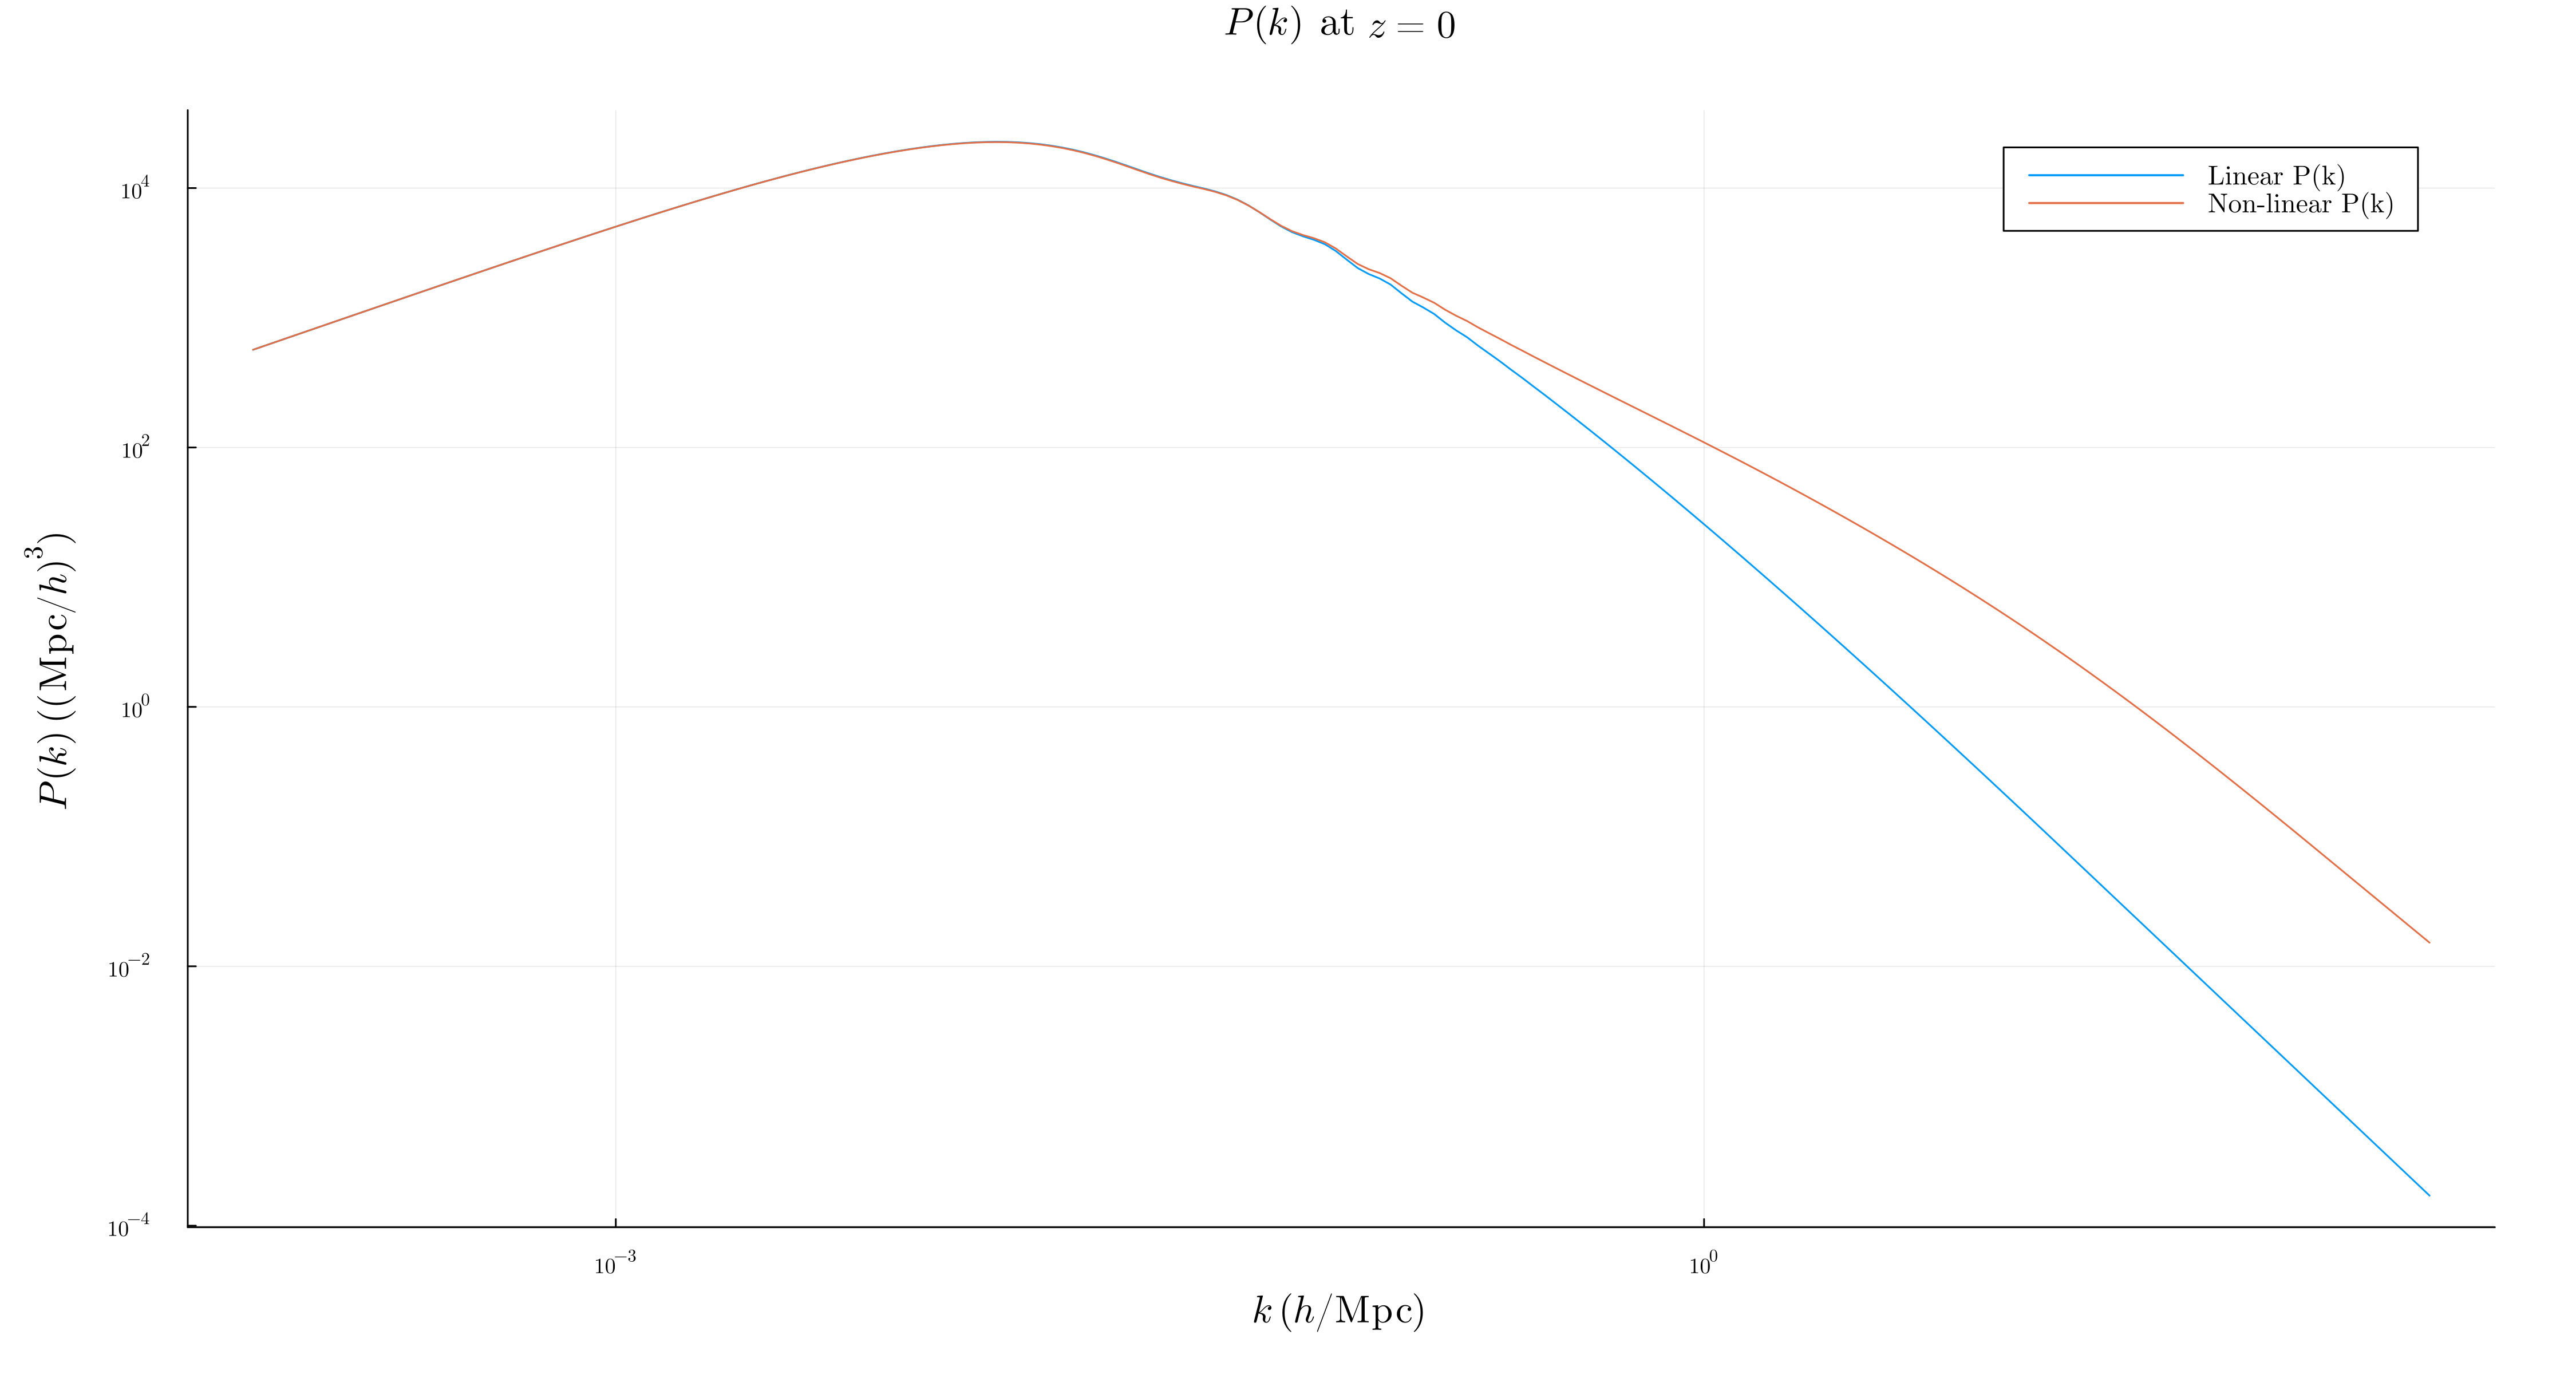

In [643]:
plot(k_pk, power_spectrum.(k_pk, 26.0, 7000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k_pk, power_spectrum_nl.(k_pk, 26.0, 7000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10, size=plot_theme.size_Cl; plot_theme.shared_style...
      )

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [644]:
Pk_grid = power_spectrum.(grids.k_grid, grid_data.xmin, grid_data.xmax)

Δk = diff(grids.k_grid)
w_trap = zeros(Float64, length(grids.k_grid))
w_trap[1] = 0.5 * Δk[1]
w_trap[2:end-1] = 0.5 * (Δk[1:end-1] .+ Δk[2:end])
w_trap[end] = 0.5 * Δk[end]
weight_gal = grids.k_grid.^2 .* Pk_grid .* w_trap


# if grids.sorting == true
#   w_k = reverse(Blast.get_clencurt_weights(grid_data.kmin, grid_data.kmax, grid_data.Nk))
#   weight_gal = w_k .* grids.k_grid.^2 .* Pk_grid
# else
#   w_k = Blast.get_clencurt_weights(grid_data.kmin, grid_data.kmax, grid_data.Nk)
#   weight_gal = w_k .* grids.k_grid.^2 .* Pk_grid
# end
;

when plotting C(l) is doesn't matter that I define the plot with a grid in k which is decreasing (like k_grid). In the heatmap on the other hand, the axis must have ordered quantities.

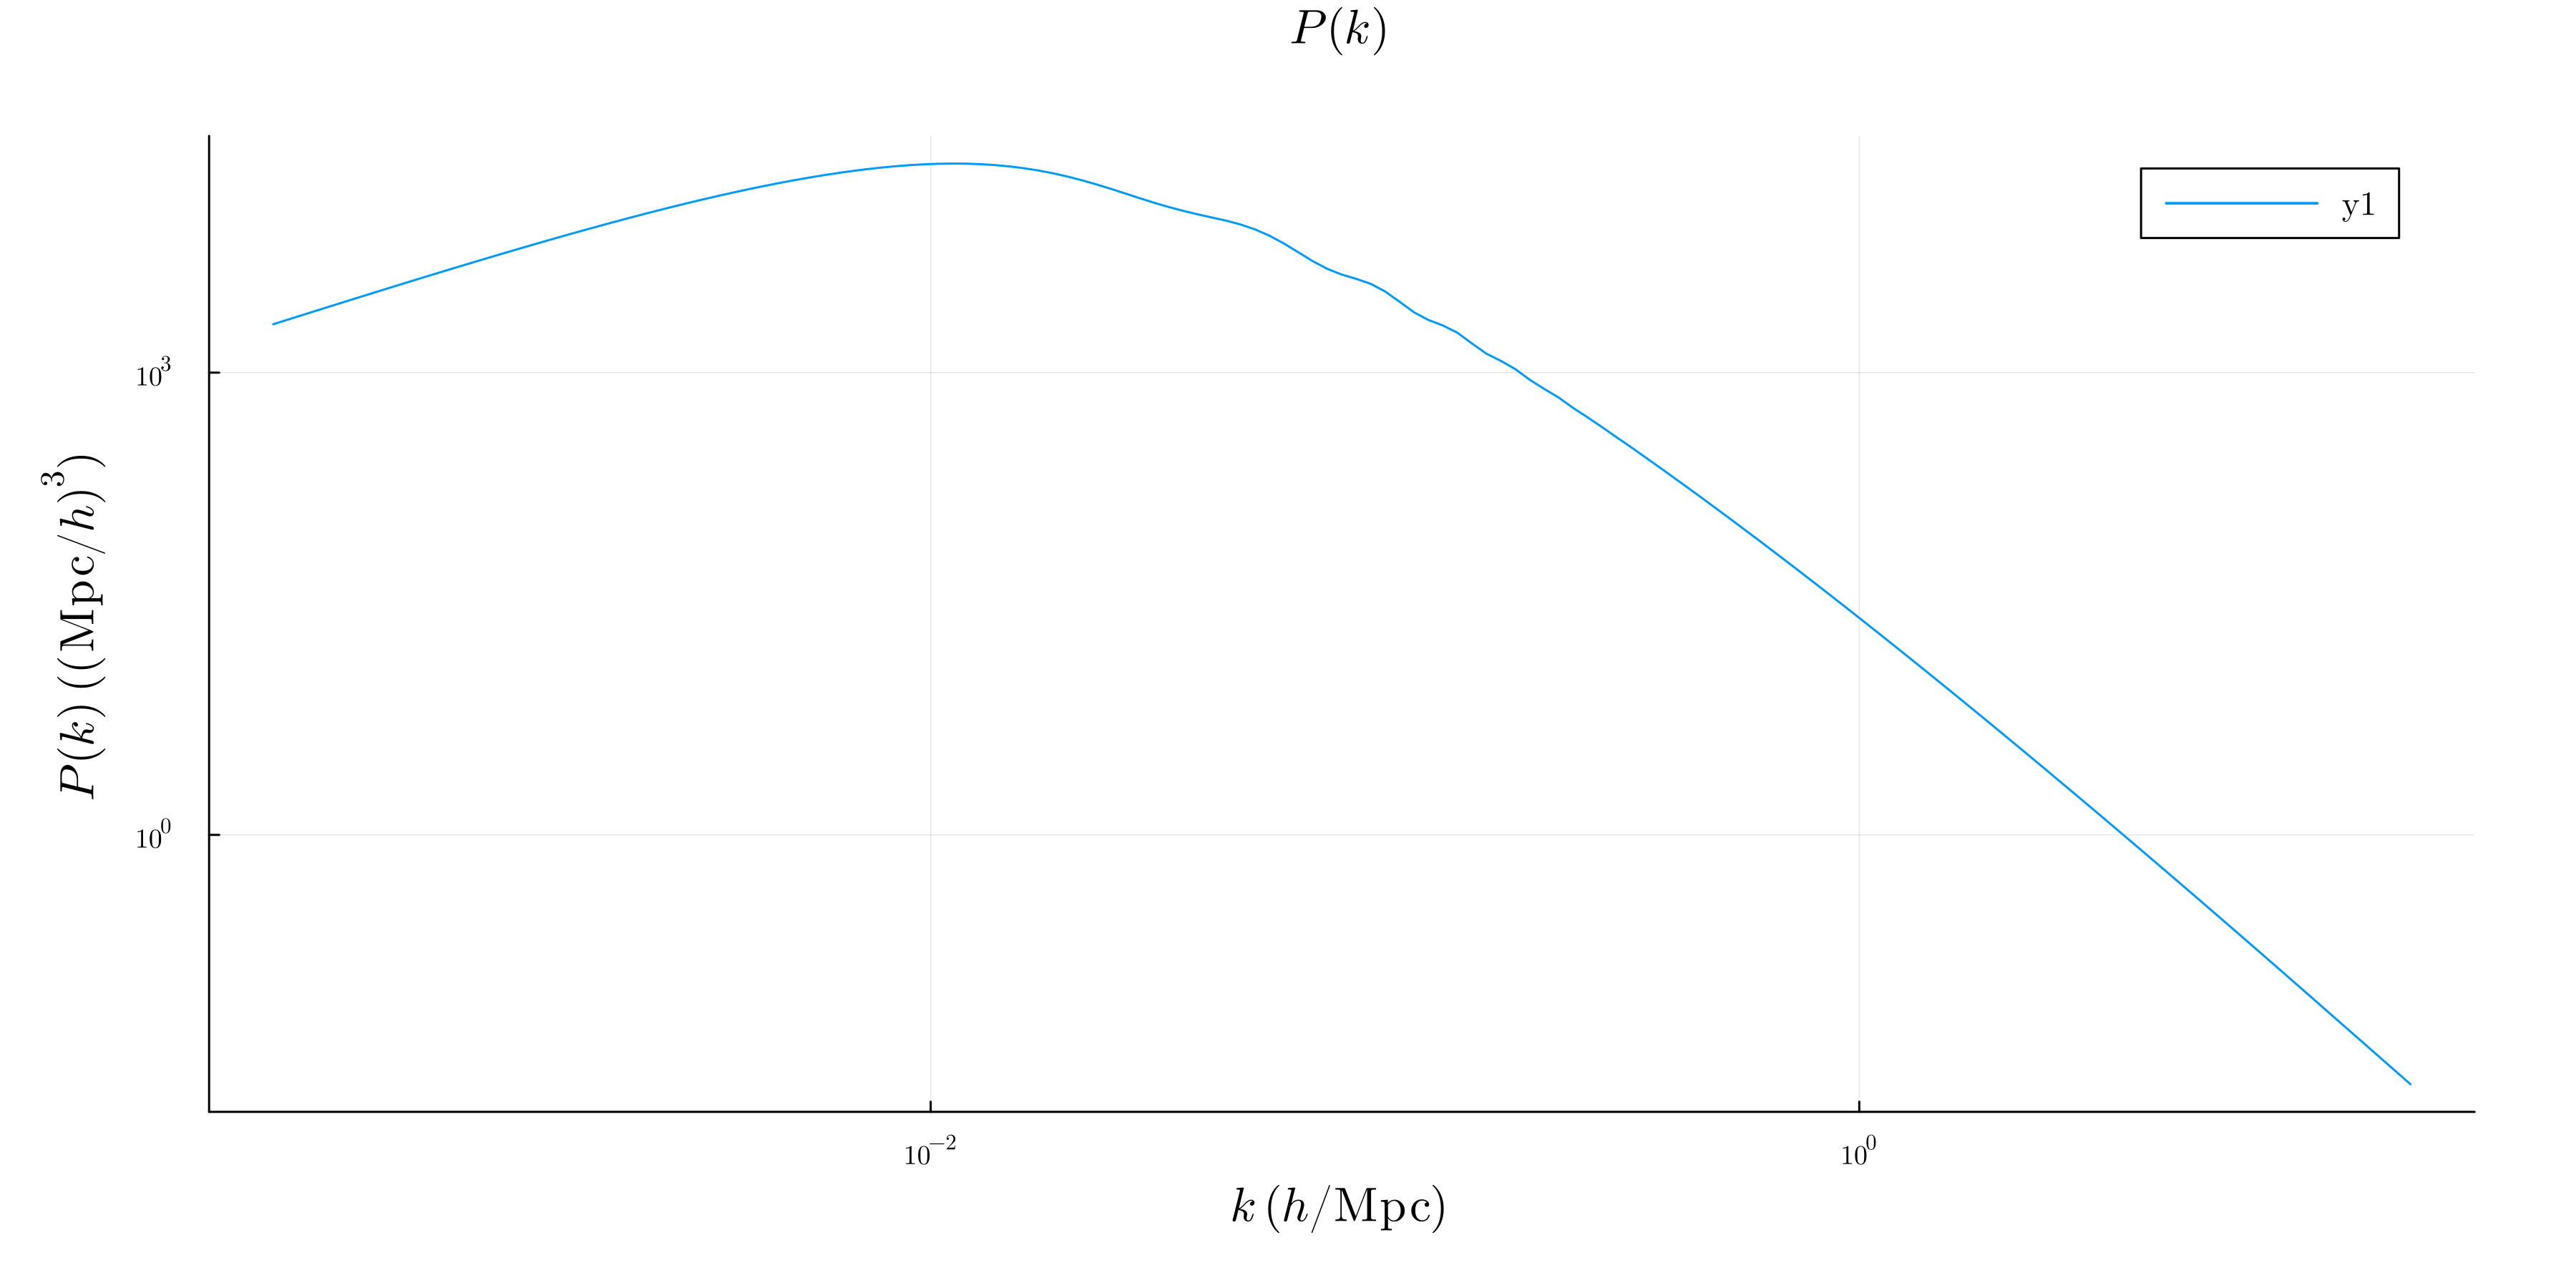

In [645]:
plot(grids.k_grid[2:end], Pk_grid[2:end], 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15, size=plot_theme.size_plot; plot_theme.shared_style...
     )

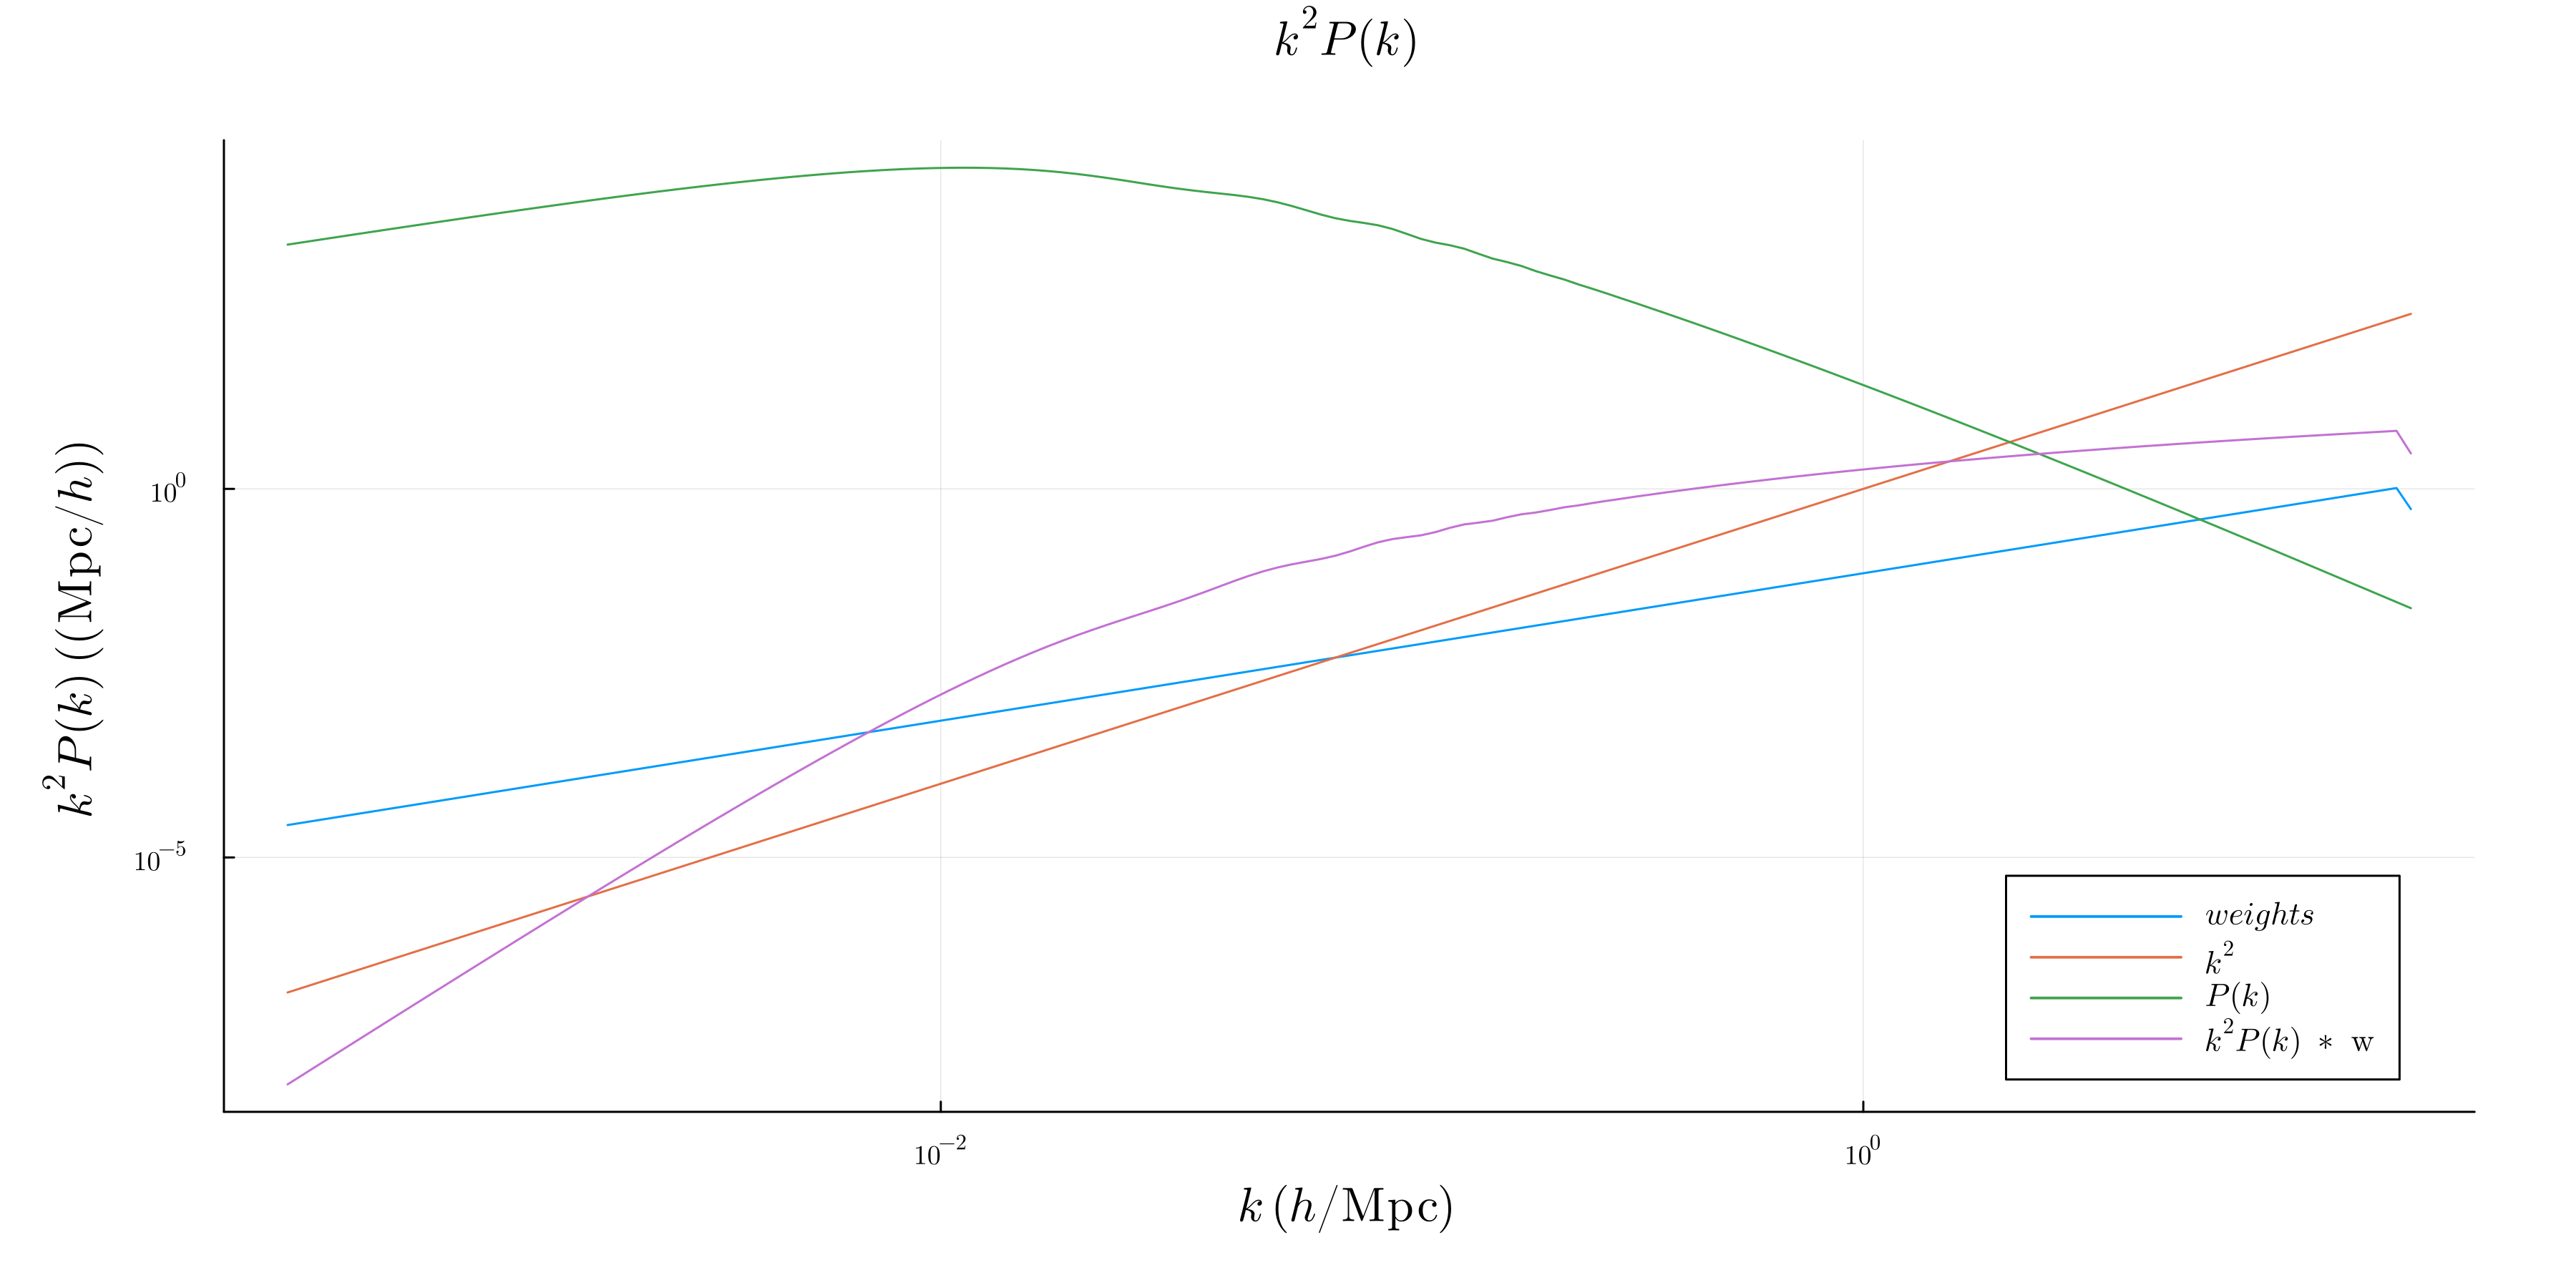

In [646]:
plot(grids.k_grid[2:end], w_trap[2:end], label = L"weights", 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid[2:end], grids.k_grid[2:end].^2, label = L"k^2",
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid[2:end], Pk_grid[2:end], label = L"P(k)", 
     xlabel = L"k \; (h/\mathrm{Mpc})", size=plot_theme.size_Cl; plot_theme.shared_style...
     )
plot!(grids.k_grid[2:end], weight_gal[2:end], 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$k^2 P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$k^2 P(k) \; ((\mathrm{Mpc}/h))$", 
     label =L"$k^2 P(k) \; * \; \mathrm{w} $",
     labelfontsize=15, legendposition = :bottomright, size=plot_theme.size_plot; plot_theme.shared_style...
     )

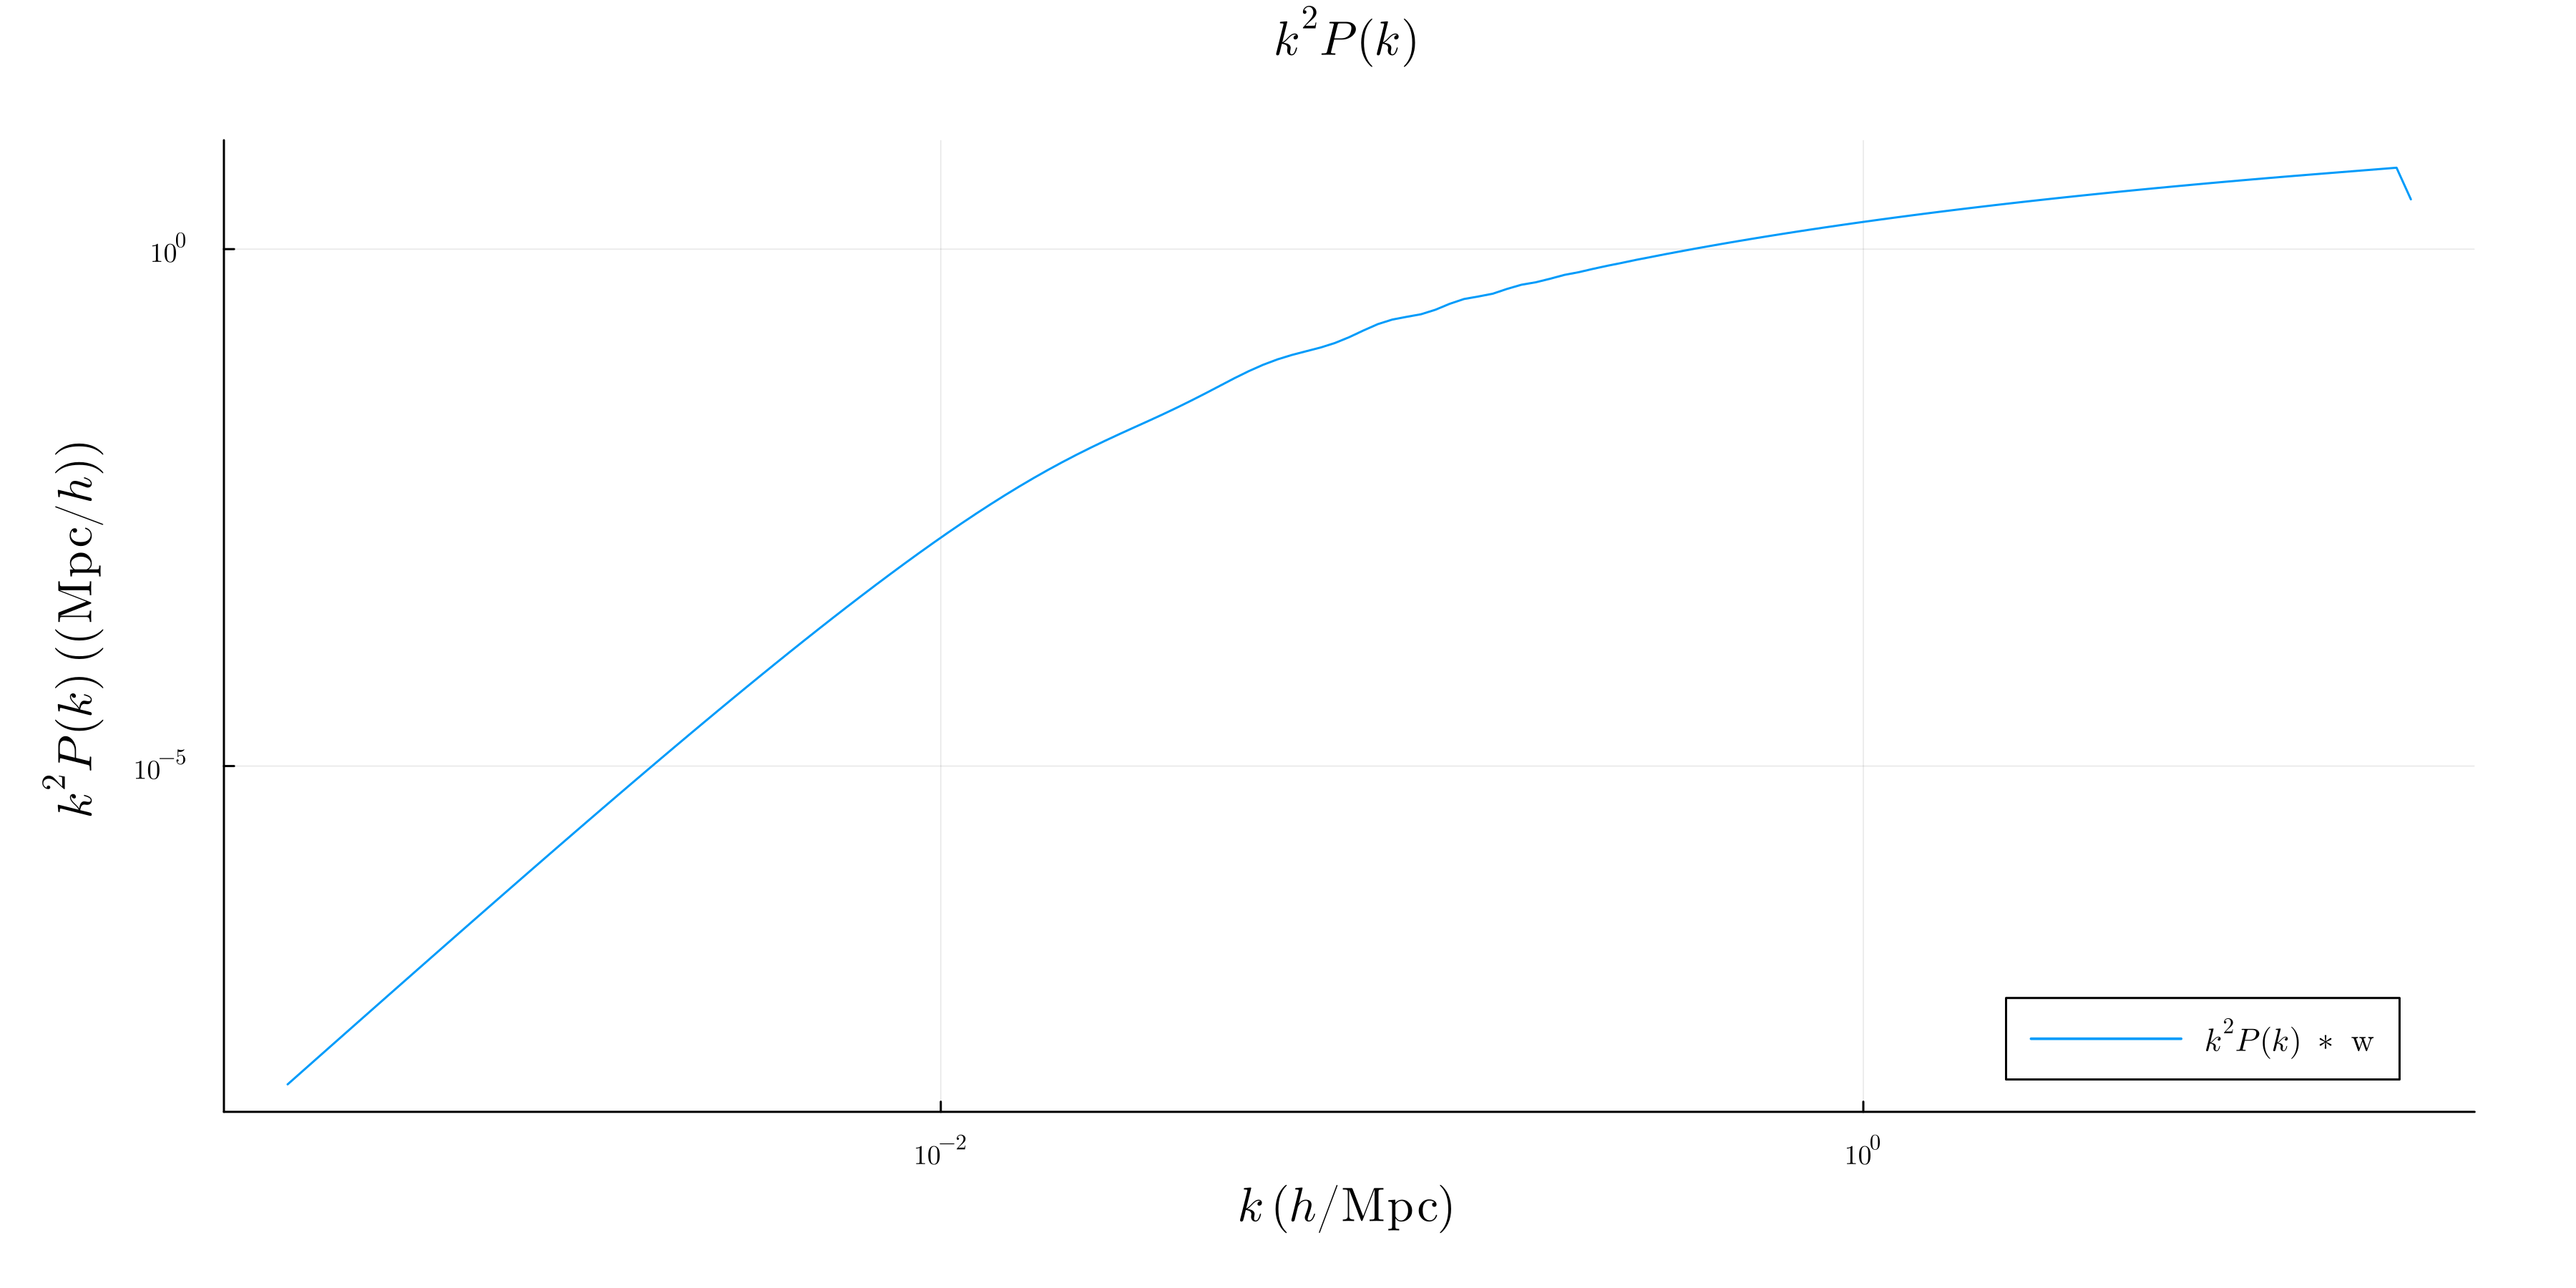

In [647]:
plot(grids.k_grid[2:end], weight_gal[2:end], 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$k^2 P(k)$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$k^2 P(k) \; ((\mathrm{Mpc}/h))$", 
     label =L"$k^2 P(k) \; * \; \mathrm{w} $",
     labelfontsize=15, legendposition = :bottomright, size=plot_theme.size_plot; plot_theme.shared_style...
     )

In [648]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), grid_data.ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), grid_data.ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), grid_data.ℓ)
pref_ss = reduce(vcat, pref_ss);

In [649]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg))

SIZES
weight_gal -> (150,)
W_final_gal -> (100, 150, 150)
pref_gg -> (100,)


In [650]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(grid_data.ℓ))
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
#npzwrite(joinpath(paths.quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
println("Size of S_l (kp, kpp) (gal-gal): \n(grid_data.Nk, grid_data.Nkp, NL) -> ", size(S_lkk_gg))
;

Size of S_l (kp, kpp) (gal-gal): 
(grid_data.Nk, grid_data.Nkp, NL) -> (150, 150, 100)


wavenumber k as a function of $\ell$ through $k \approx \frac{\ell+0.5}{\chi}$ ?

In [651]:
npzwrite(joinpath(paths.quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)

In [652]:
xref = (grid_data.xmax - grid_data.xmin ) * 0.5
ℓ_to_k = ℓ -> ℓ ./ xref
ℓ_ticks = 1:50:200
k_ticks = ℓ_to_k.(ℓ_ticks)
k_ticklabels = [string(round(k, digits=3)) for k in k_ticks];

In [653]:
println(grids.k_grid[4])

0.0004427401505602817


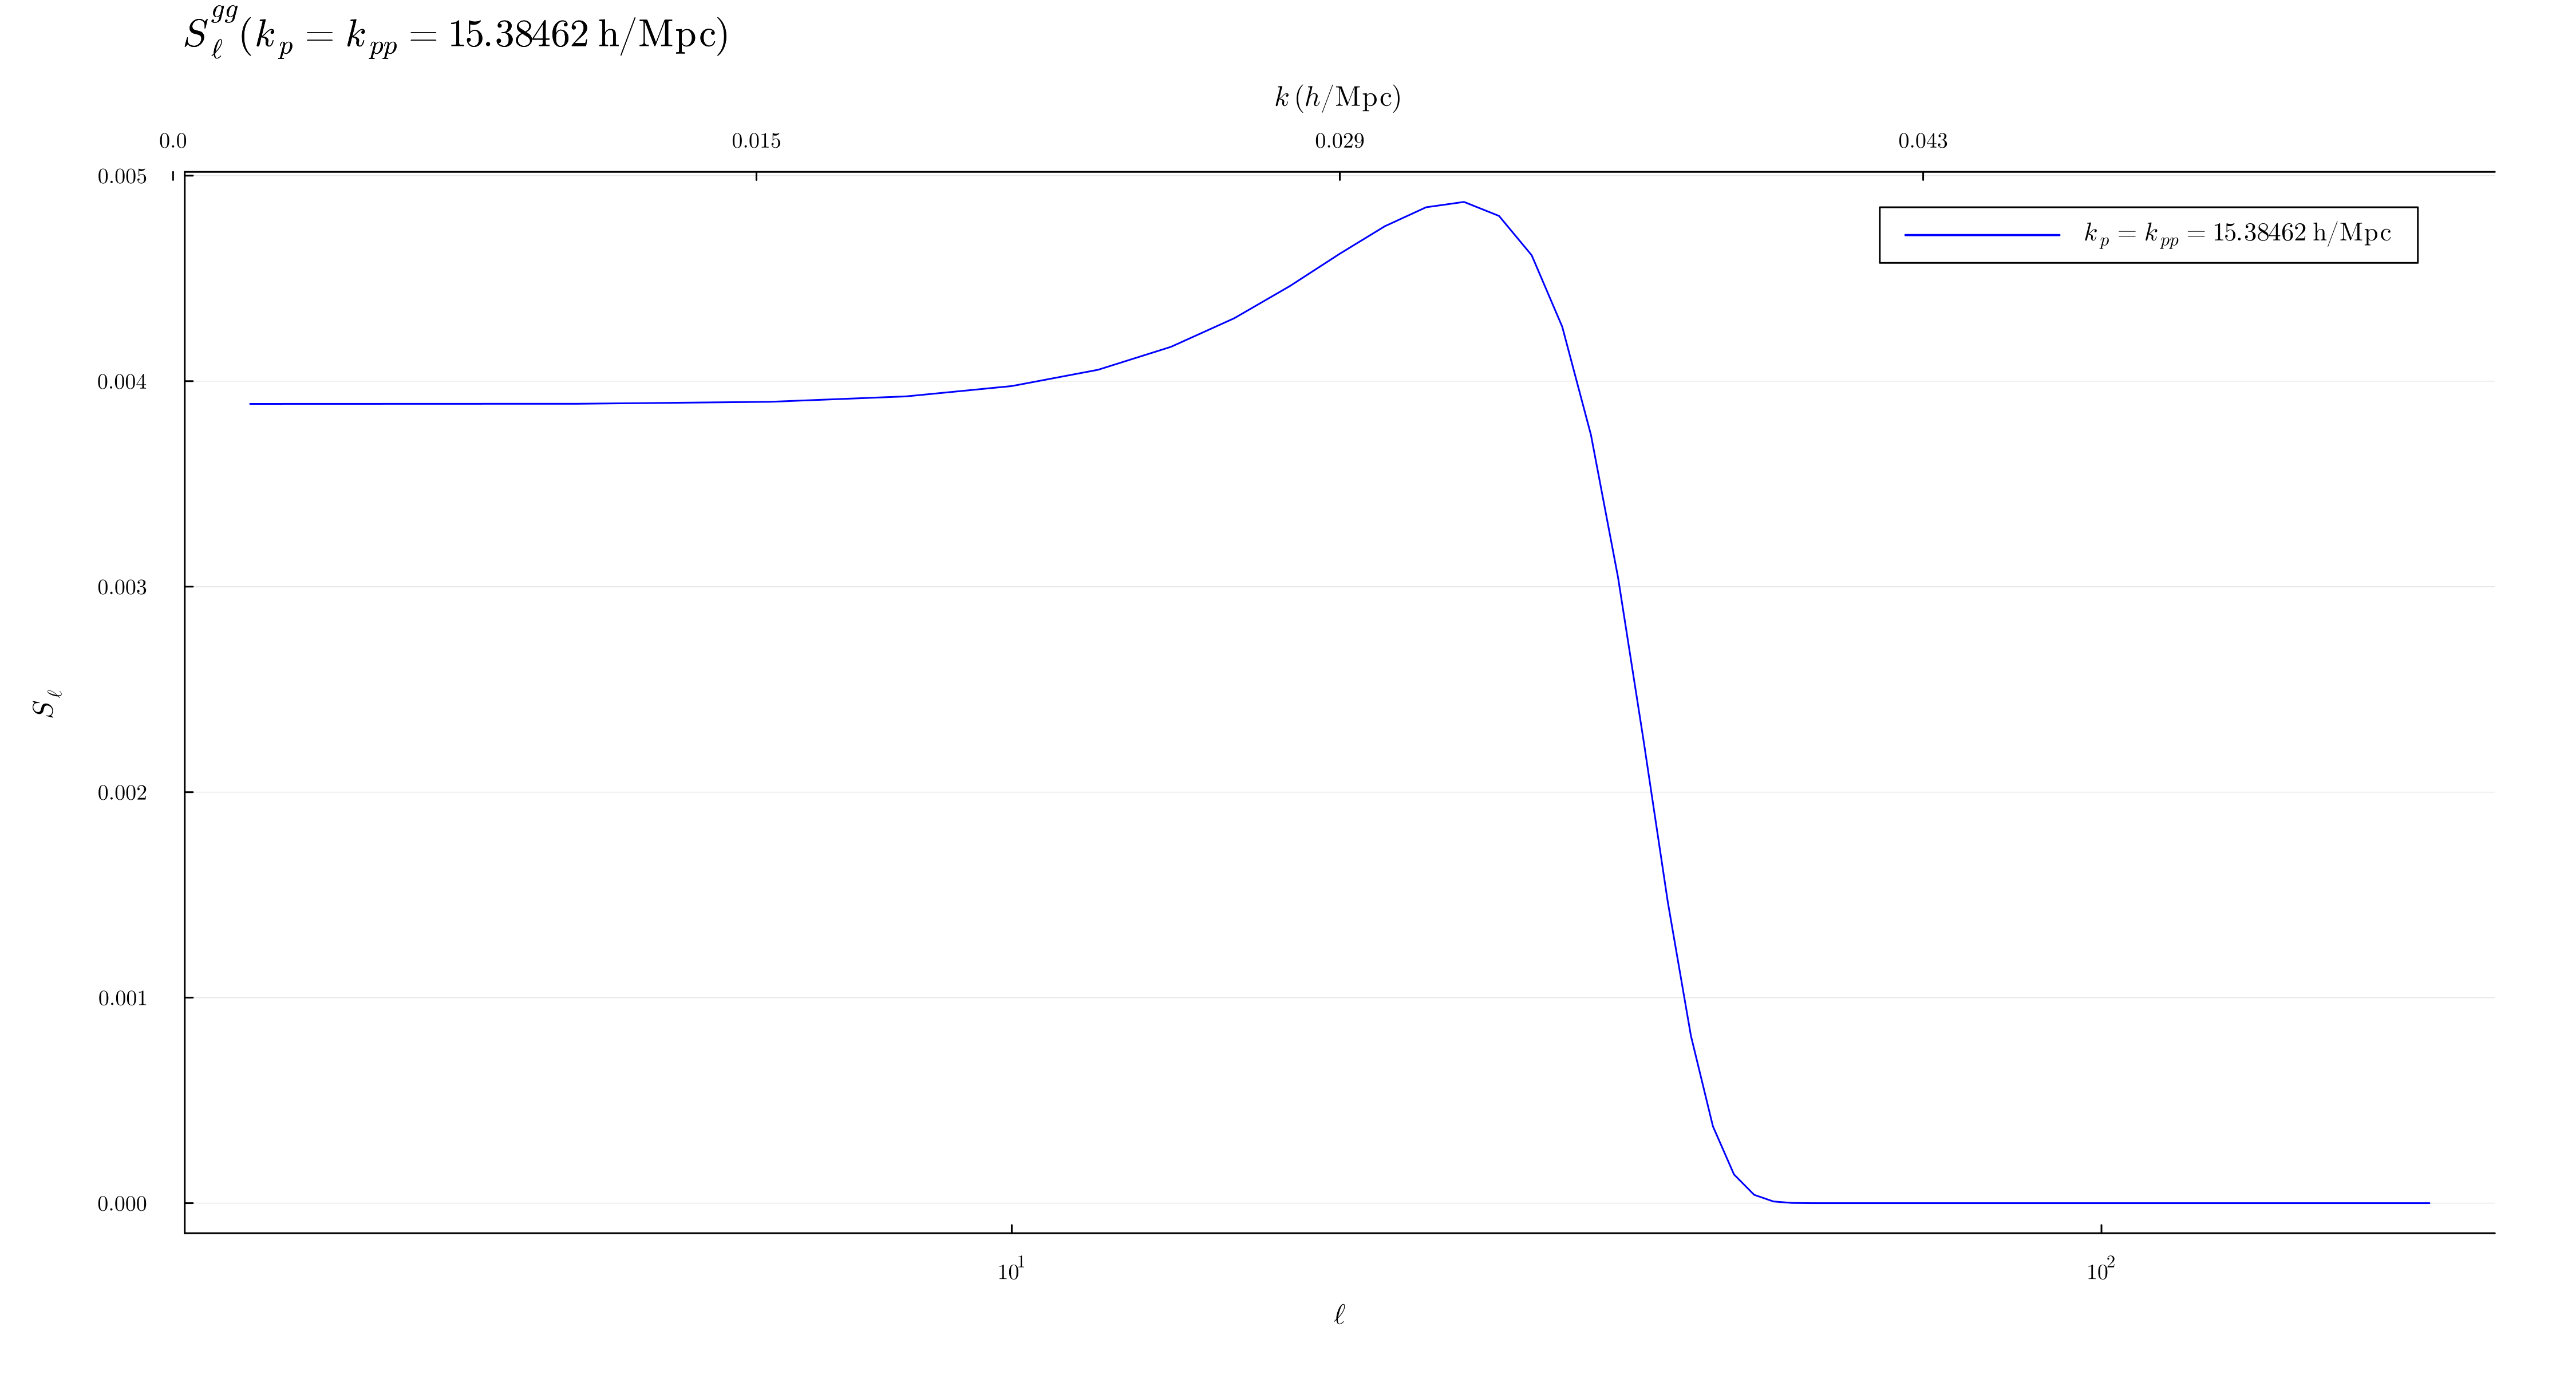

In [654]:
i = 150
j = i 
k_p = grids.k_grid[i]
k_pp = grids.kp_grid[j]
plot(grid_data.ℓ, S_lkk_gg[i,j,:],
      color = :blue,
      label = label = L"k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc}")
      
plot!(xaxis = L"\ell",
      ylabel = L"S_\ell"
      ,xscale = :log10,
      )
plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )
plot!(label = "Beyond BLAST", 
      size=plot_theme.size_Cl,
      title = L"S_{\ell}^{gg} (k_p = k_{pp} = %$(round(k_p, digits=5)) \; \mathrm{h/Mpc})",
      titlefontsize = 20,
      titleposition = :left ; plot_theme.shared_style...)

In [655]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/ell_vs_Sl_kp_kpp_$i.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/ell_vs_Sl_kp_kpp_150.png"

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) = 0.013773995747300663 h/Mpc - fixed, stays there


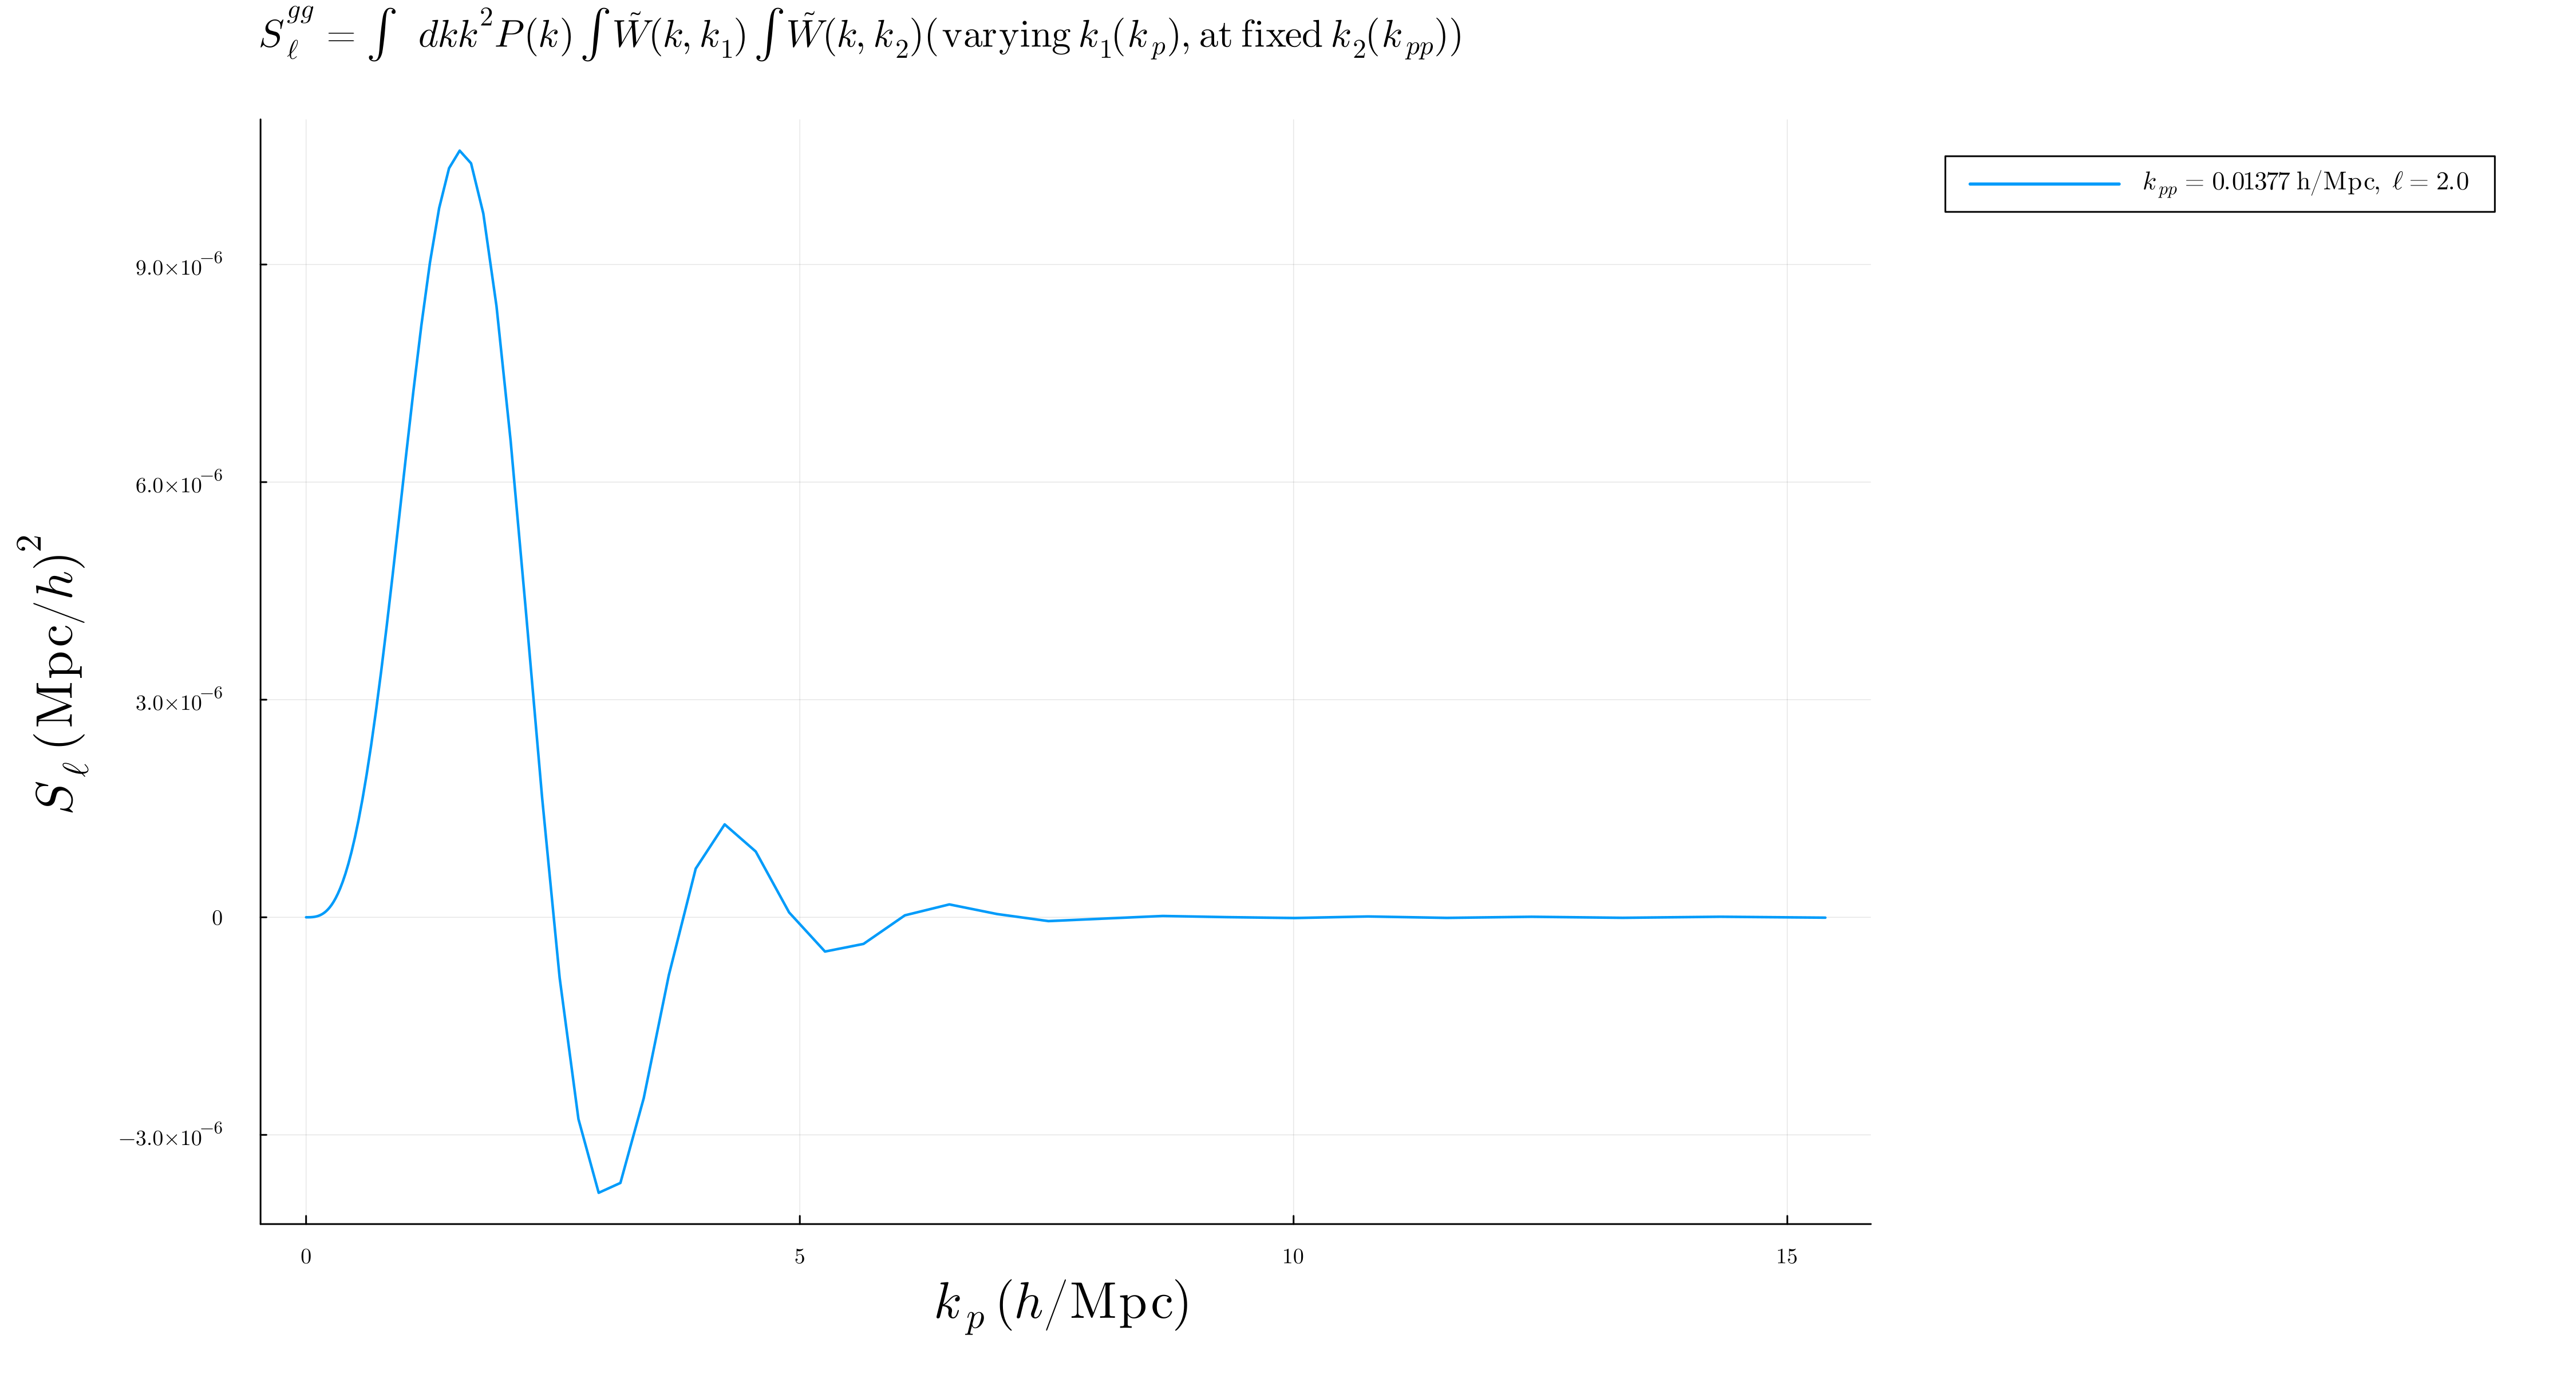

In [676]:
plt = plot()
il = 1
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
ikpp = 52
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) = ", grids.kp_grid[ikpp] , " h/Mpc - fixed, stays there")
k_pp = grids.kp_grid[ikpp]
plot(sort(grids.k_grid), S_lkk_gg[:, ikpp, il], 
#color = plot_theme.colors[:],
label = L"k_{pp} = %$(round(k_pp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
linestyle = :solid, lw = 1.5)
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell \; (\mathrm{Mpc}/h)^2"
      #,xscale = :log10
     )
plot!( title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) (\mathrm{varying} \; k_1 (k_p), \mathrm{at} \; \mathrm{fixed} \; k_2 (k_{pp}))",
      titlefontsize = 20,
      label = L"\ell=%$(grid_data.ℓ[il]), k_pp=%$(round(k_pp, digits=3)) \; \mathrm{h/Mpc}",
      titleposition = :left, labelfontsize = 20, labelposition = :topright,
      legendposition = :outertopright, 
      size=plot_theme.size_Cl; plot_theme.shared_style...)

In [657]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kpp_vs_Sl_idxell_$il"*"_kpp_$k_pp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kpp_vs_Sl_idxell_1_kpp_0.011935904025452972.png"

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) is fixed at each iteration


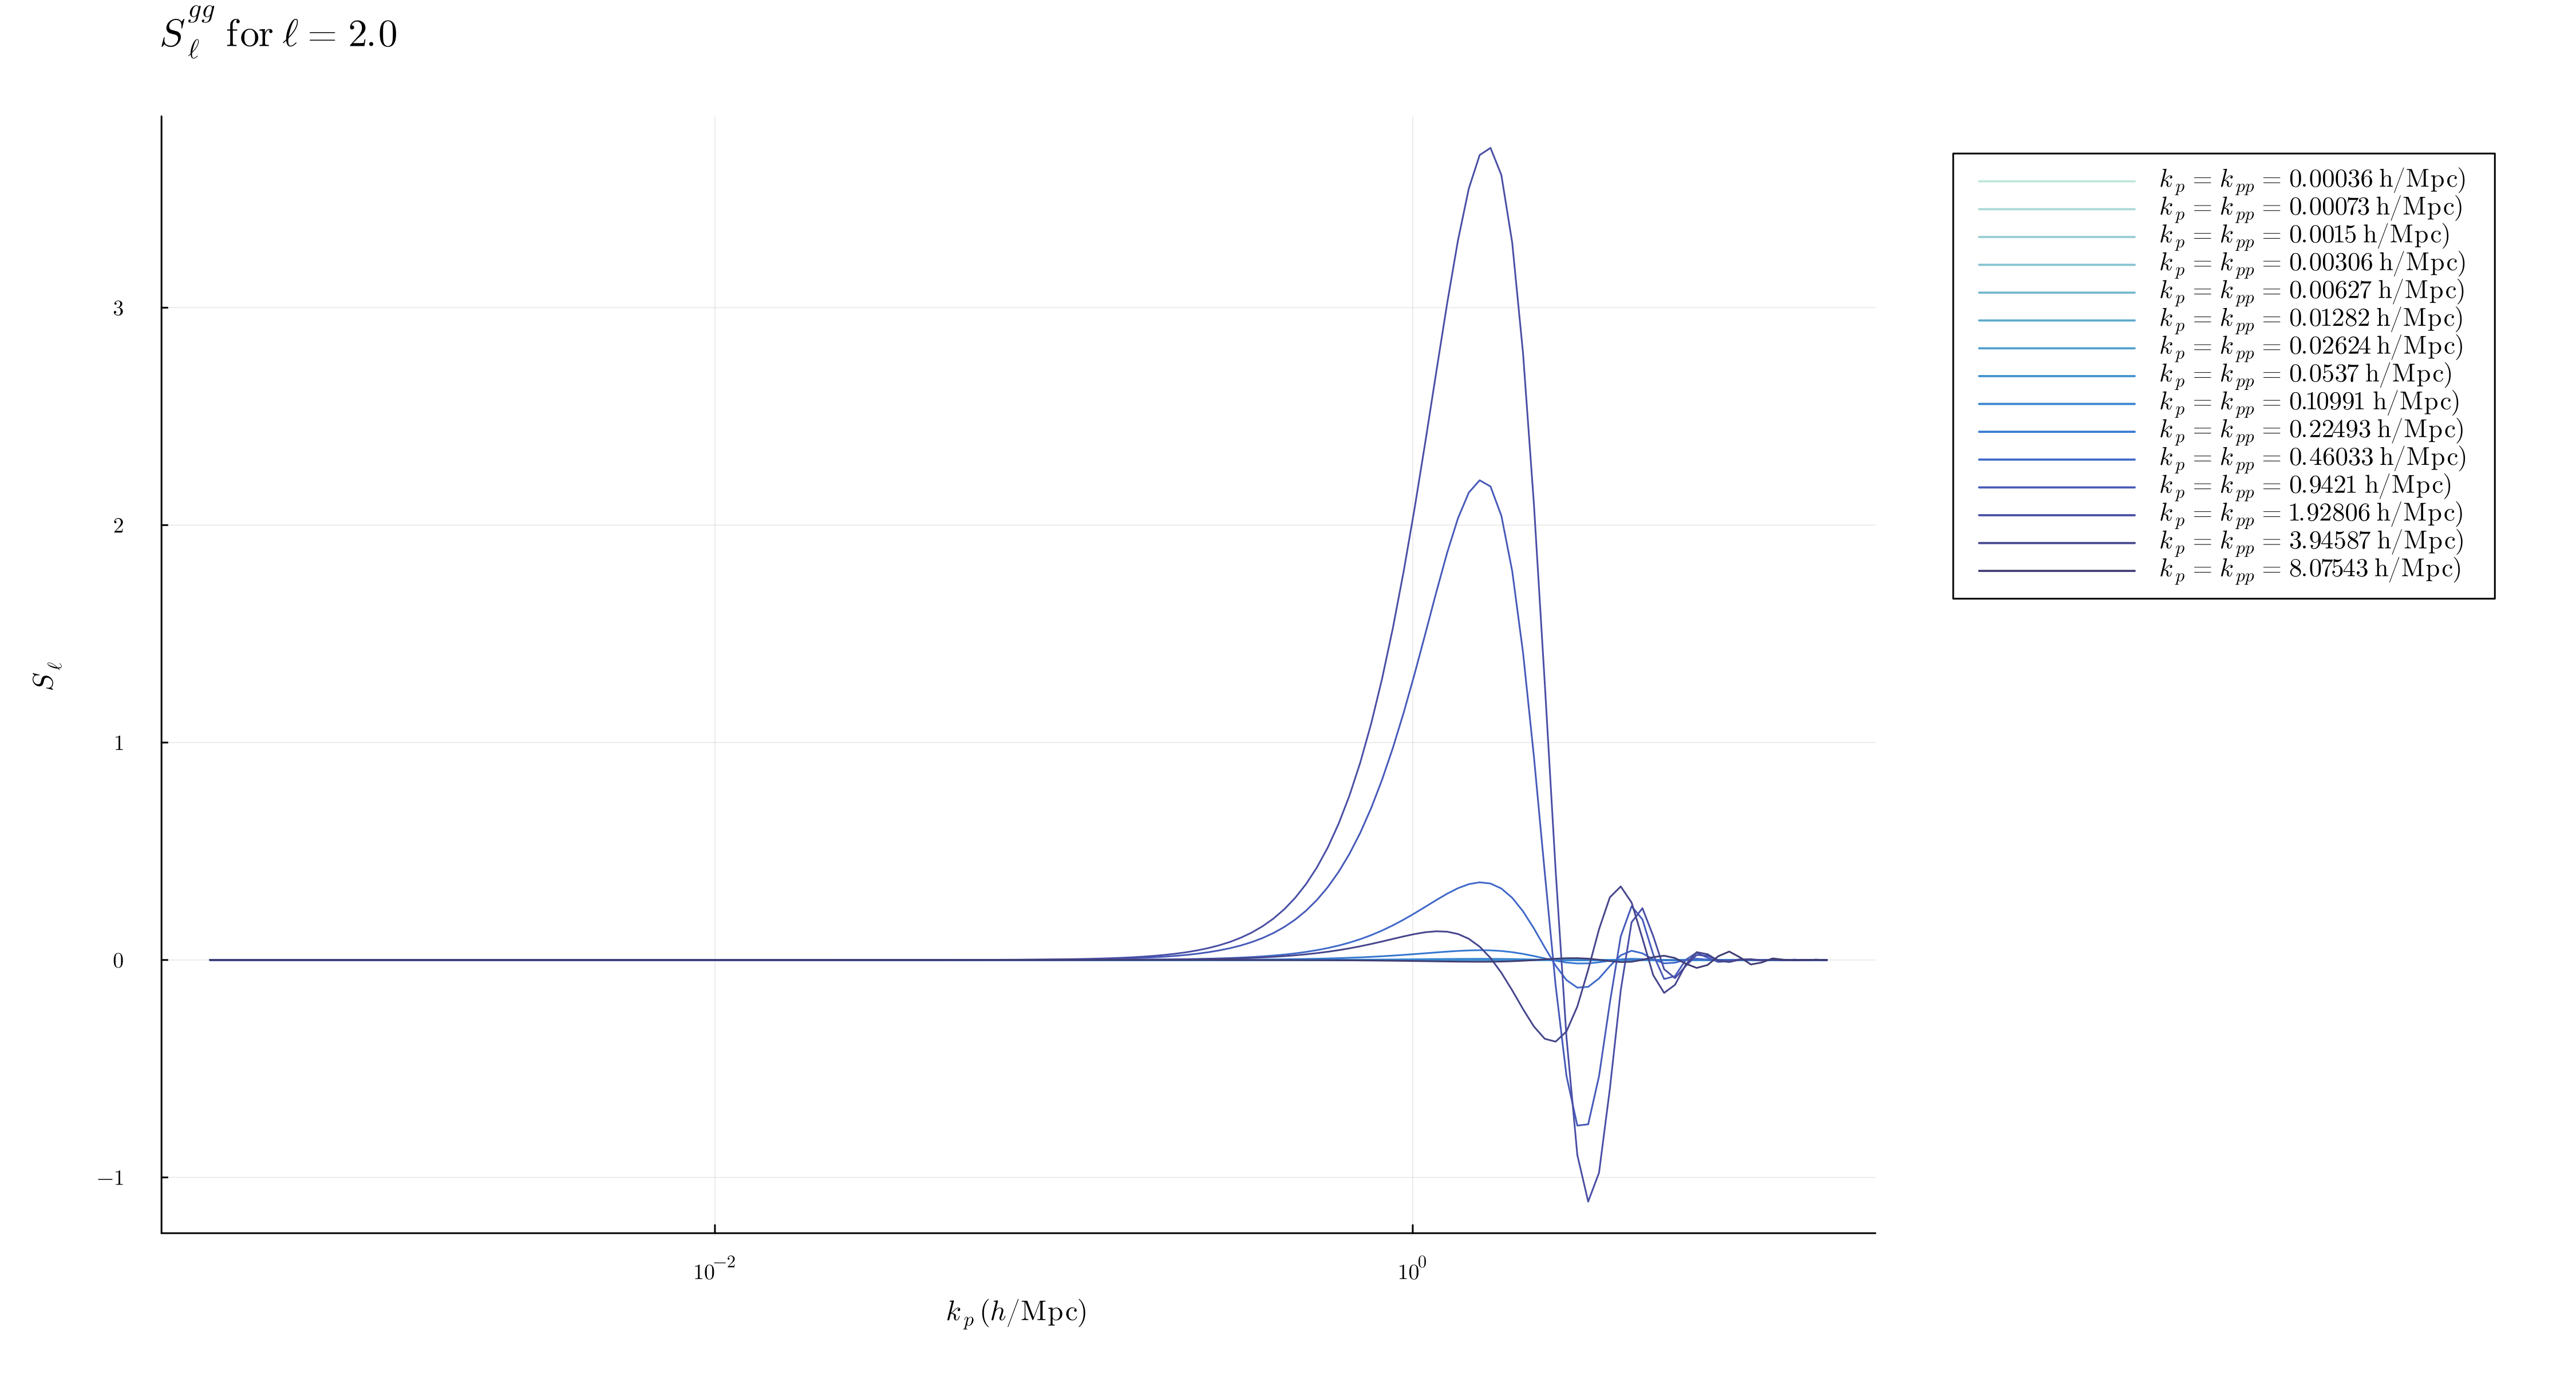

In [658]:
plt = plot()
il = 1
for ip in 1:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
end
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is fixed at each iteration")
for ip in 1:10:grid_data.Nkp
    color_palette = cgrad(:seaborn_icefire_gradient, grid_data.Nkp)
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    plot!(sort(grids.k_grid), S_lkk_gg[:,ip,il], 
    color = color_palette[ip],
    label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc})",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10
      , label = ""
     )
plot!(title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
      legendposition = :outertopright, size = plot_theme.size_Cl, titlefontsize = 20, titleposition = :left; plot_theme.shared_style...)

In [659]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_idxell_$il"*"each_time_kpp_fixed.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kp_vs_Sl_idxell_1each_time_kpp_fixed.png"

ℓ = 2.0
ℓ is fixed always
k_1 (k_p) varies at each iteration
k_2 (k_pp) is fixed at each iteration


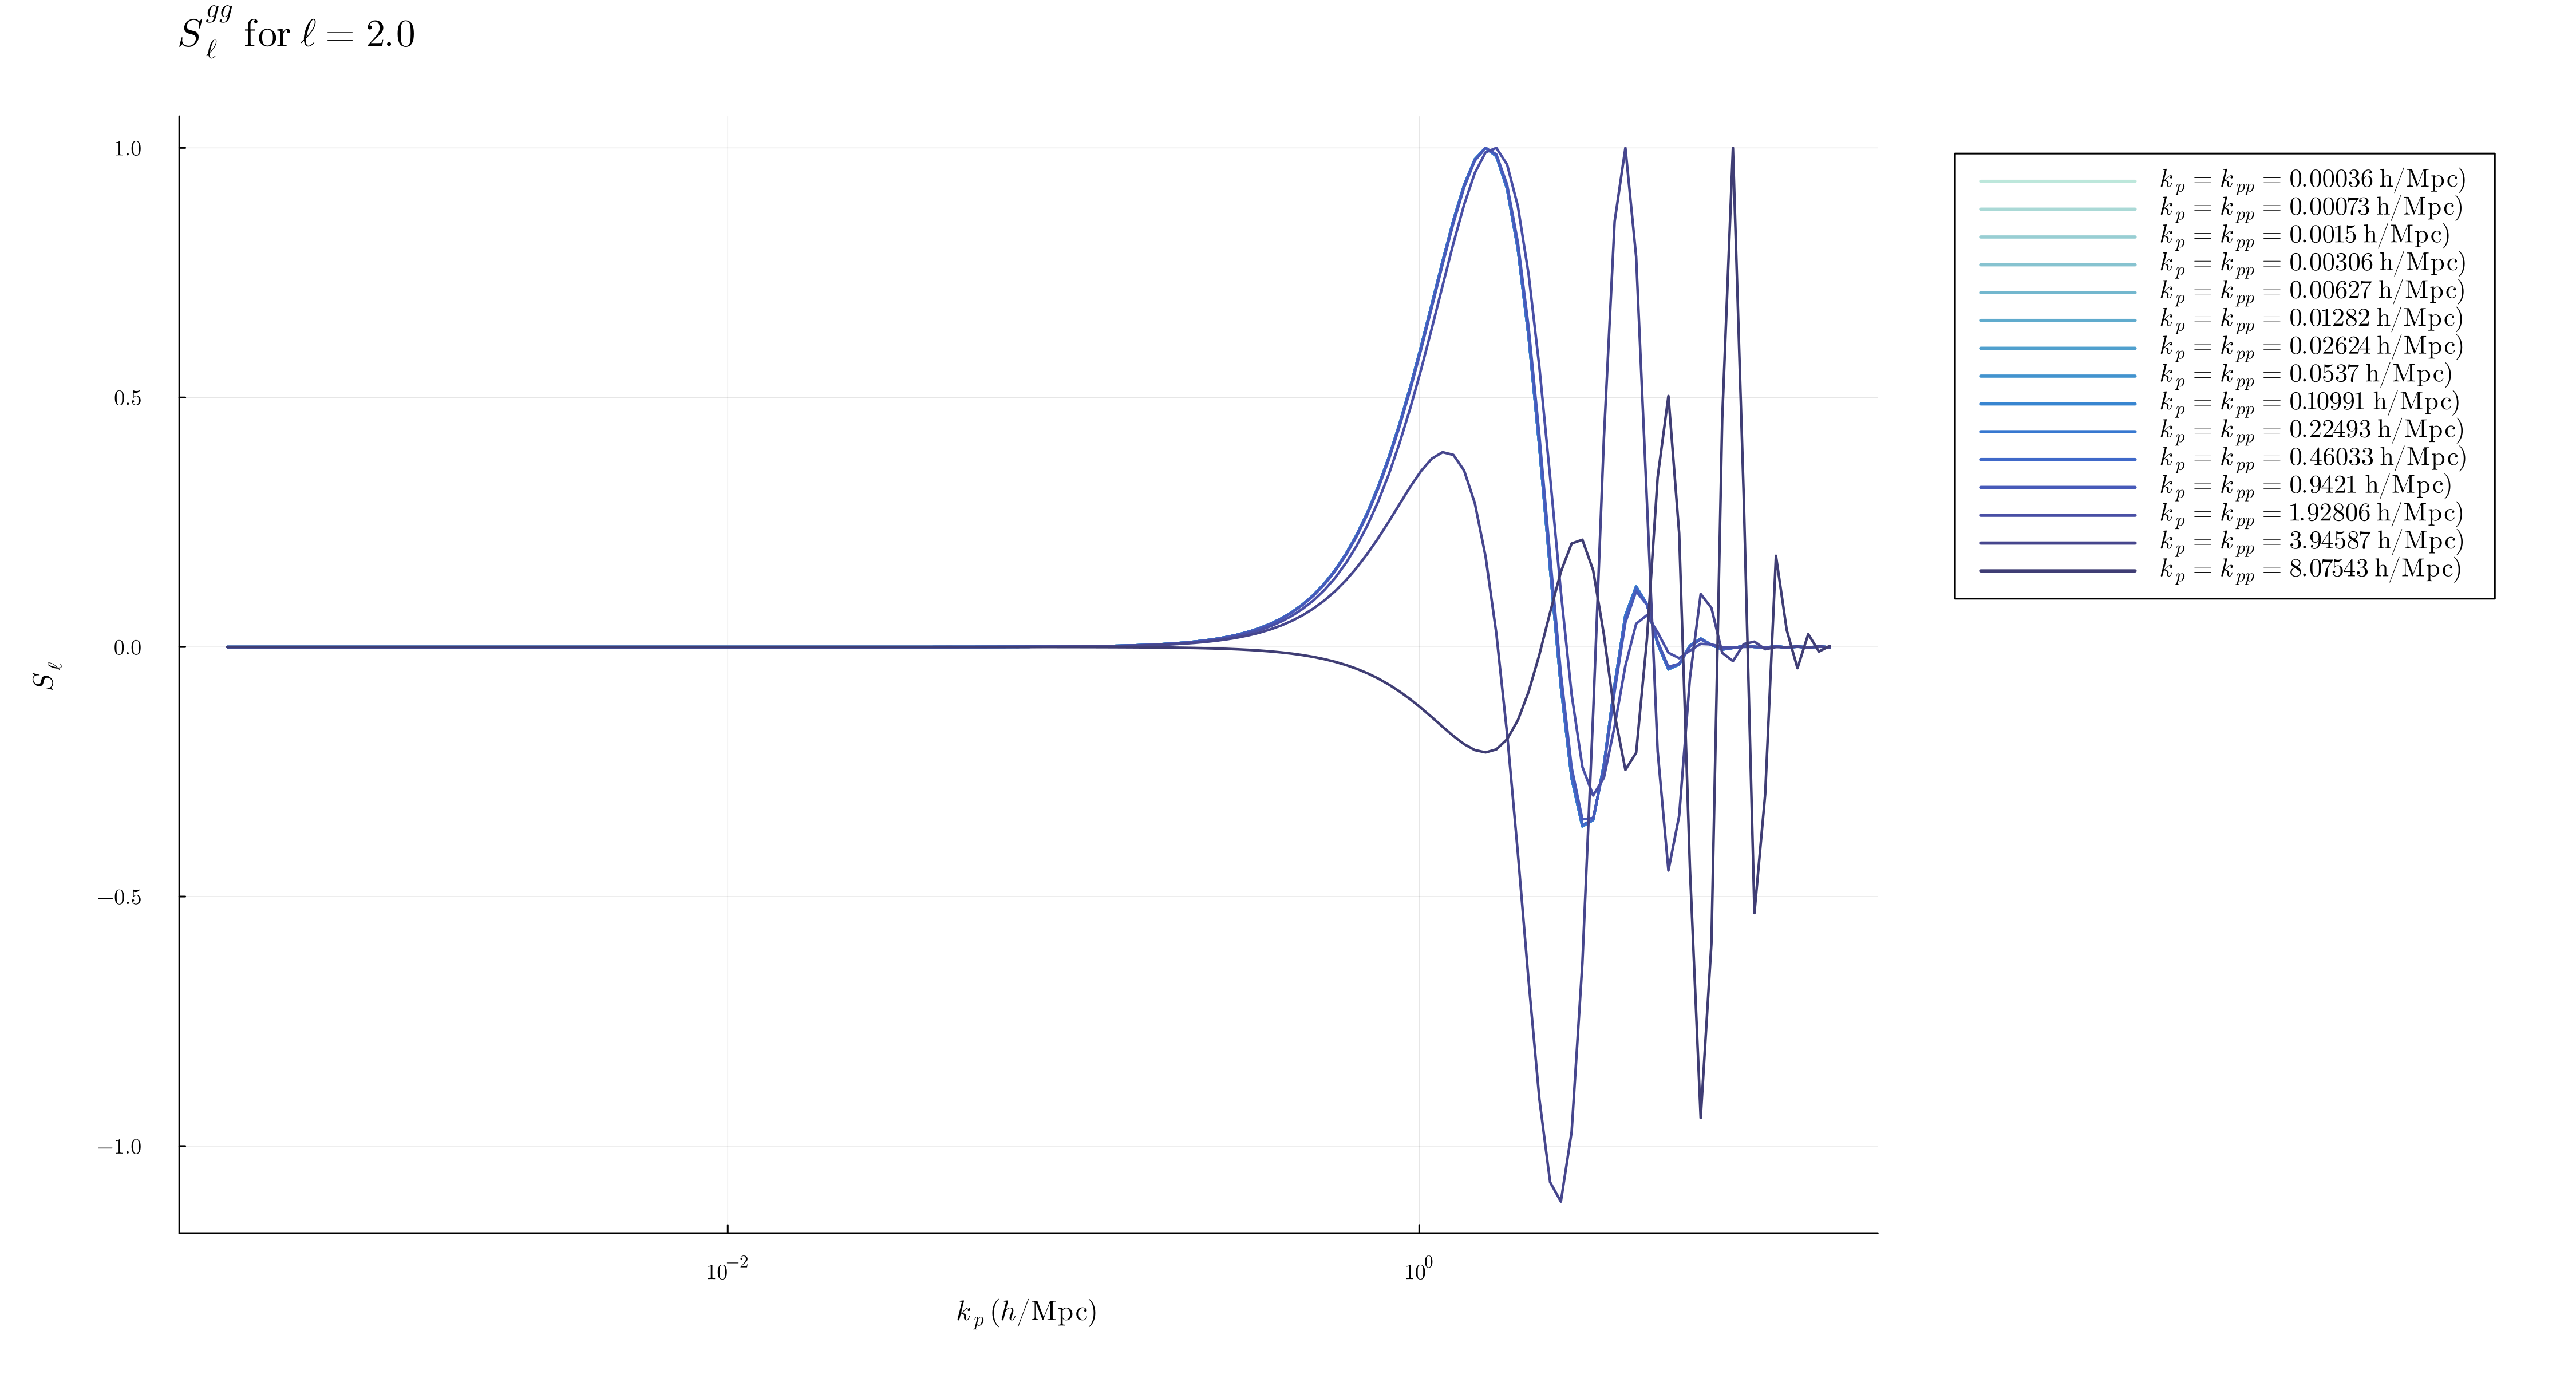

In [660]:
plt = plot()
il = 1
for ip in 1:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
end
println("ℓ = ", grid_data.ℓ[il])
println("ℓ is fixed always")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is fixed at each iteration")
for ip in 1:10:grid_data.Nkp
    color_palette = cgrad(:seaborn_icefire_gradient, grid_data.Nkp)
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    plot!(sort(grids.k_grid), S_lkk_gg[:,ip,il]/maximum(S_lkk_gg[:,ip,il]), 
    #plot!(sort(grids.k_grid), S_lkk_gg[:,ip,il], 
    color = color_palette[ip],
    label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc})",
    linestyle = :solid, lw = 1.5)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10
      , label = ""
     )
plot!(title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
      legendposition = :outertopright, size = plot_theme.size_Cl, titlefontsize = 20, titleposition = :left; plot_theme.shared_style...)

In [661]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_idxell_$il"*"each_time_kpp_fixed_NORM.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kp_vs_Sl_idxell_1each_time_kpp_fixed_NORM.png"

[ Info: Saved animation to /Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kp_vs_Sl_idxell_1plot_evolution.gif


Plots.AnimatedGif("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kp_vs_Sl_idxell_1plot_evolution.gif")
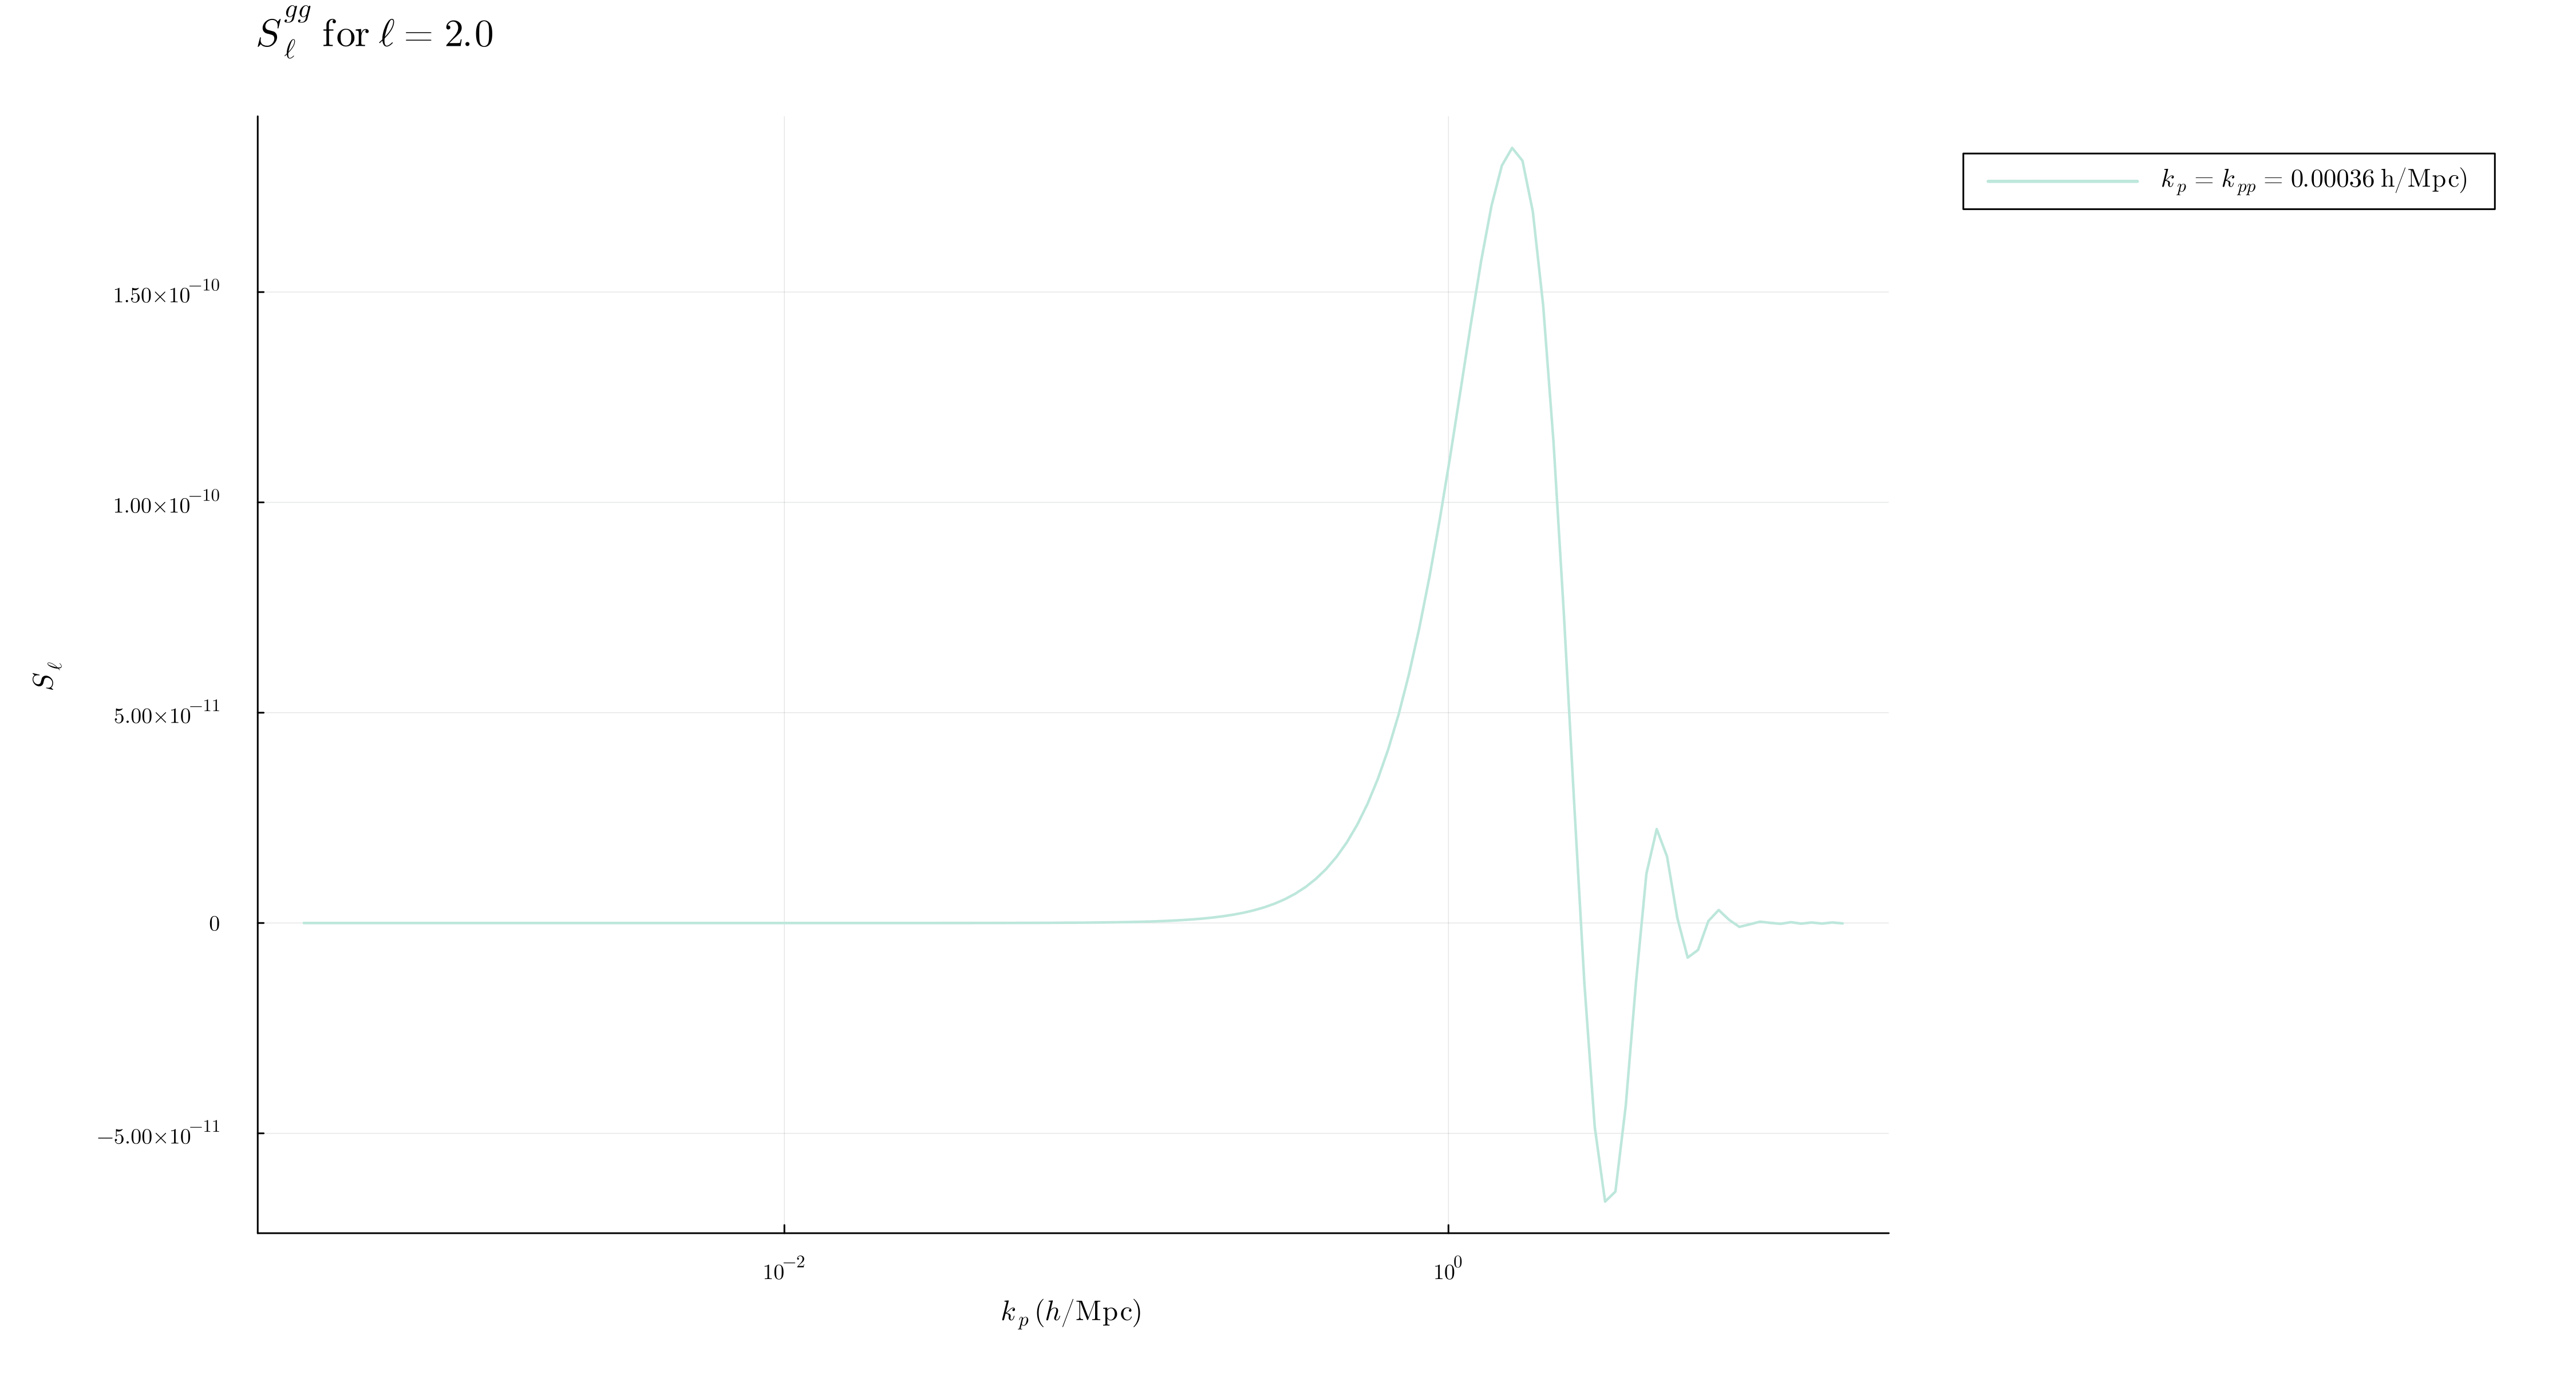

In [662]:
using Plots
plt = plot(
    xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell",
    xscale = :log10,
    title = L"S_\ell^{gg} \; \mathrm{for} \; \ell = %$(grid_data.ℓ[il])",
    legendposition = :outertopright, 
    size = plot_theme.size_Cl, 
    titlefontsize = 20, 
    titleposition = :left; 
    plot_theme.shared_style...
)

color_palette = cgrad(:seaborn_icefire_gradient, grid_data.Nkp)

anim = @animate for ip in 1:10:grid_data.Nkp
    kp = grids.k_grid[ip]
    kpp = grids.kp_grid[ip]
    
    plot!(
        plt,
        grids.k_grid, 
#        S_lkk_gg[:, ip, il] / maximum(S_lkk_gg[:, ip, il]), 
        S_lkk_gg[:, ip, il], 
        color = color_palette[ip],
        label = L"k_p = k_{pp} = %$(round(kp, digits=5)) \; \mathrm{h/Mpc})",
        linestyle = :solid, lw = 1.5
    )
end

gif(anim, joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_idxell_$il"*"plot_evolution.gif"), fps = 1)

ℓ changes at each iteration
k_1 (k_p) varies at each iteration
k_2 (k_pp) is kept fixed for every iteration


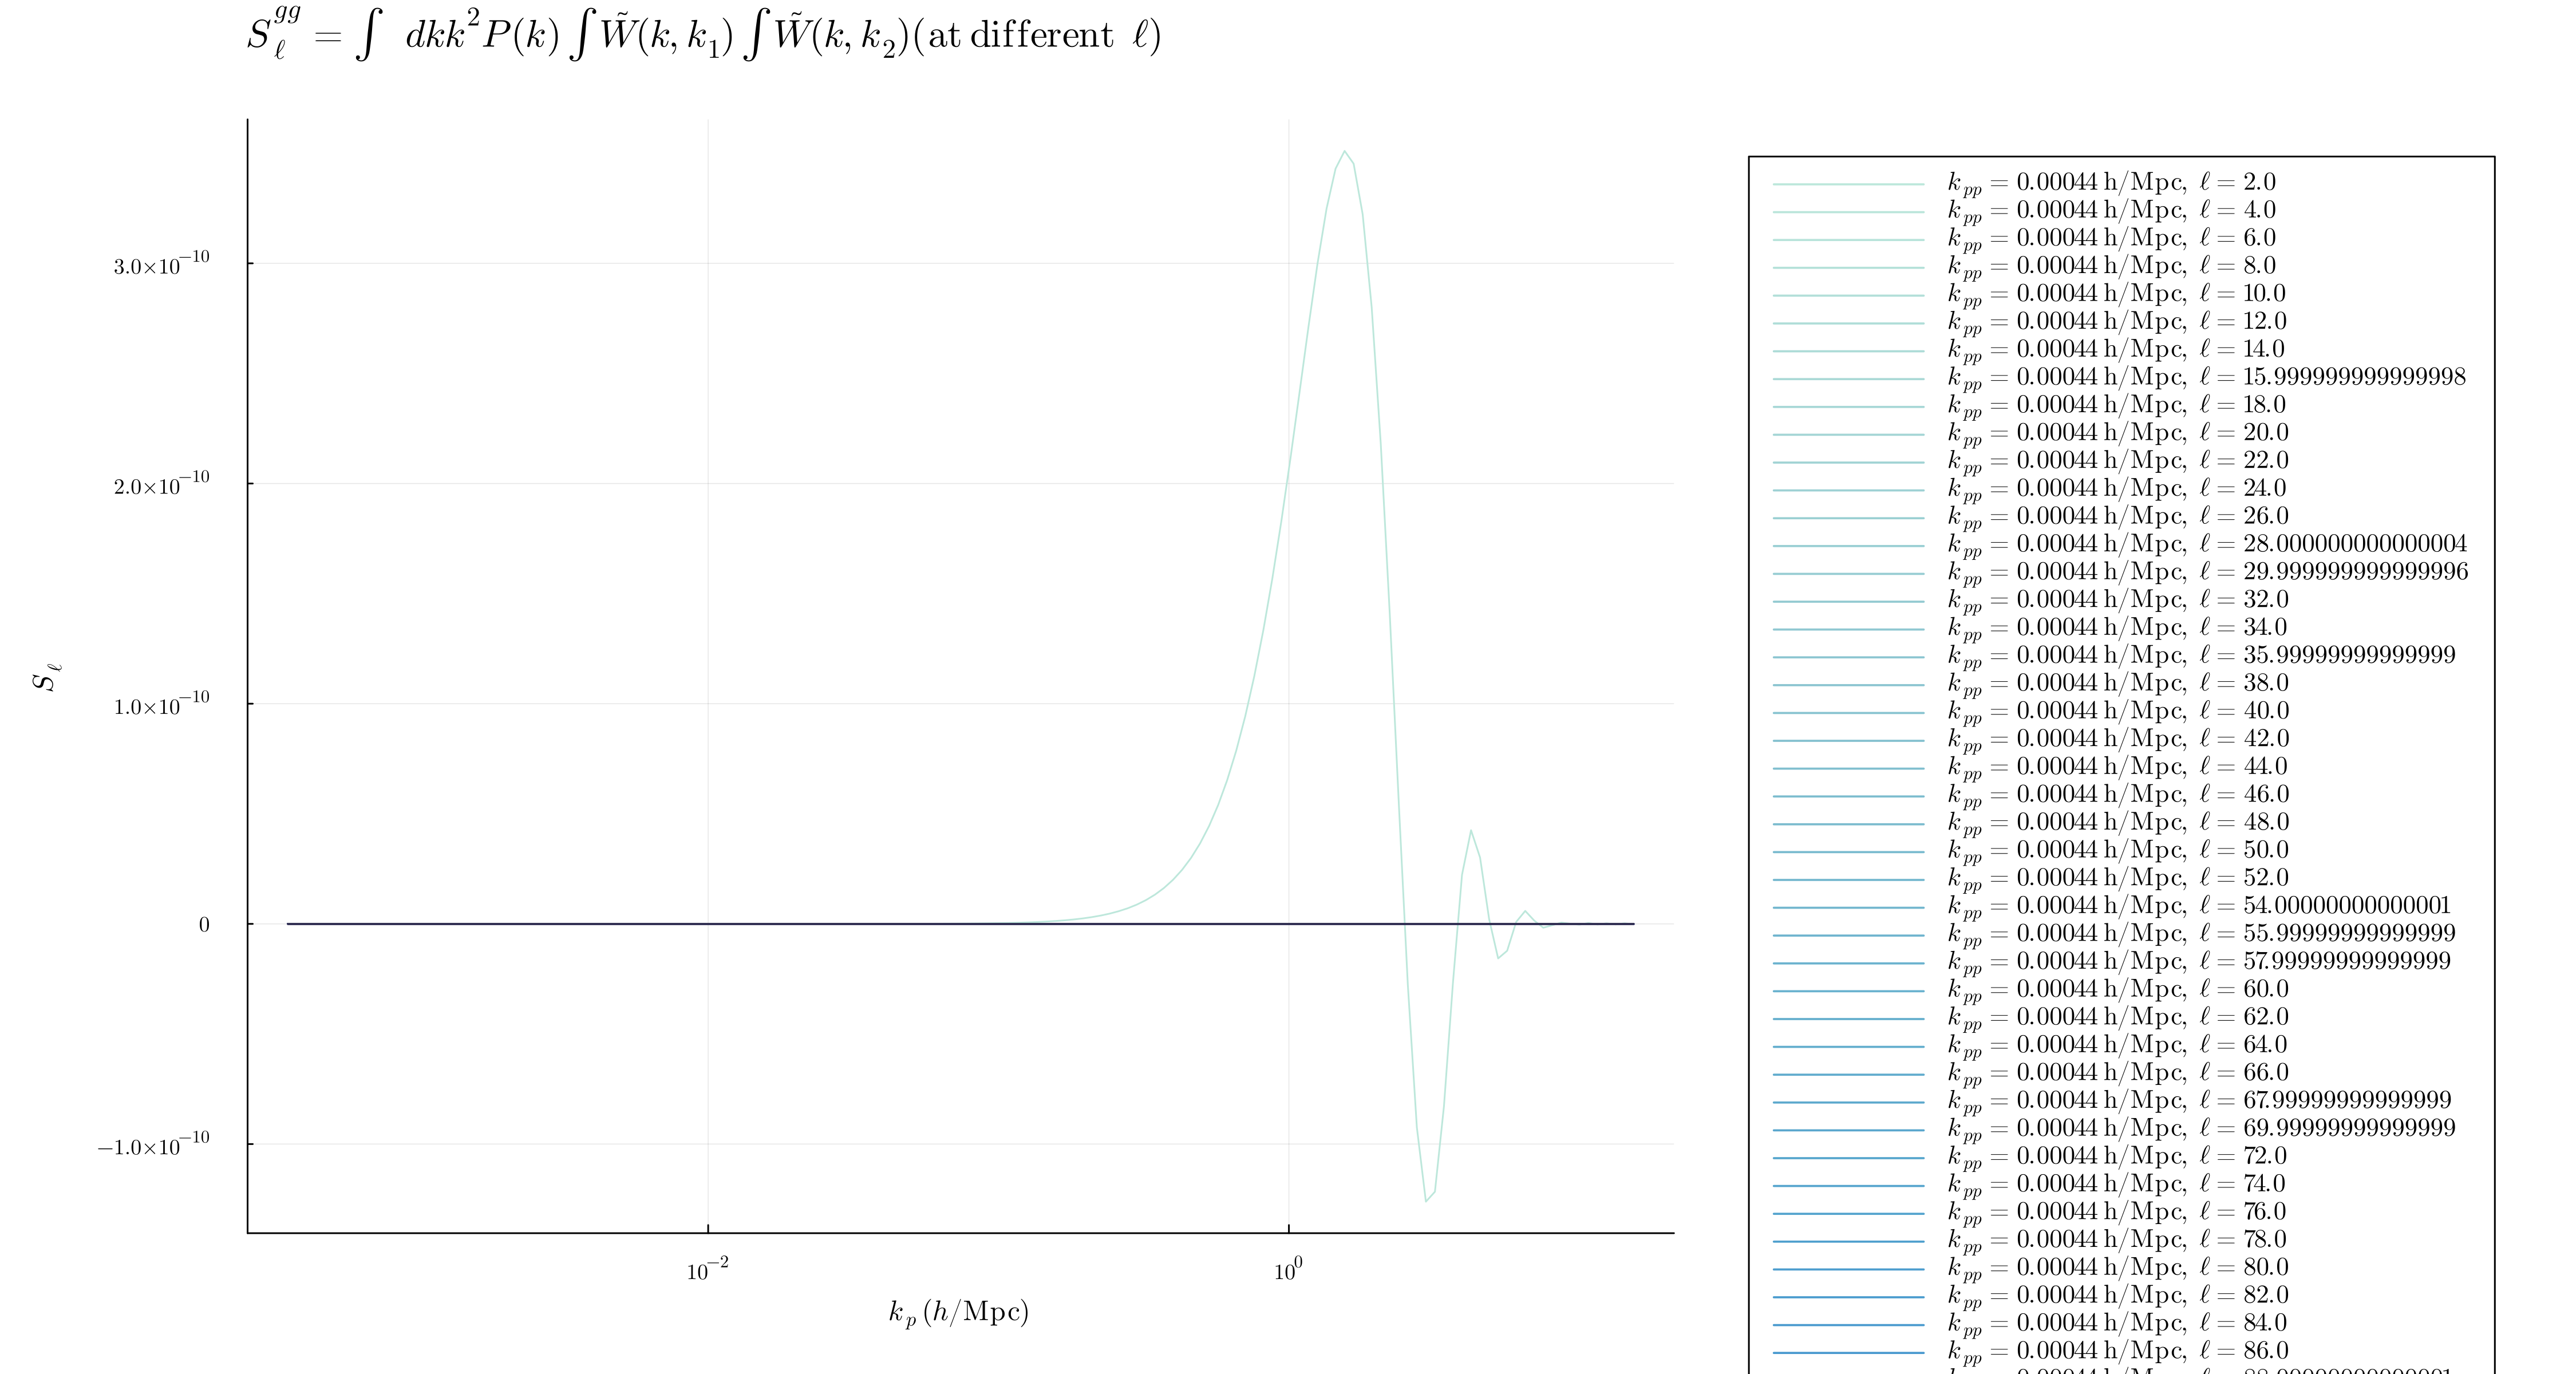

In [663]:
plt = plot()
ipp = 4
kpp = grids.kp_grid[ipp]
color_palette = cgrad(:seaborn_icefire_gradient, grid_data.ℓ) 
println("ℓ changes at each iteration")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is kept fixed for every iteration")
for il in 1:length(grid_data.ℓ)
    plot!(grids.kp_grid, S_lkk_gg[:,ipp,il],
    color = color_palette[il],
    label = L"k_{pp} = %$(round(kpp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
    linestyle = :solid)
end
plot!(xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
      ylabel = L"S_\ell"
      ,xscale = :log10
     )
plot!( title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) (\mathrm{at} \; \mathrm{different} \; \; \ell )",
      titlefontsize = 20,
      titleposition = :left, legend = nothing,
      legendposition = :outertopright, 
      size=plot_theme.size_Cl; plot_theme.shared_style...)

In [664]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/kp_vs_Sl_kpp_$kpp"*"_loop_on_ell.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kp_vs_Sl_kpp_0.0004427401505602817_loop_on_ell.png"

ℓ changes at each iteration
k_1 (k_p) varies at each iteration
k_2 (k_pp) is kept fixed for every iteration


[ Info: Saved animation to /Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kpp_vs_Sl_idxell_loop_on_ℓ_kp_13.331592086142688.gif


Plots.AnimatedGif("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/kpp_vs_Sl_idxell_loop_on_ℓ_kp_13.331592086142688.gif")
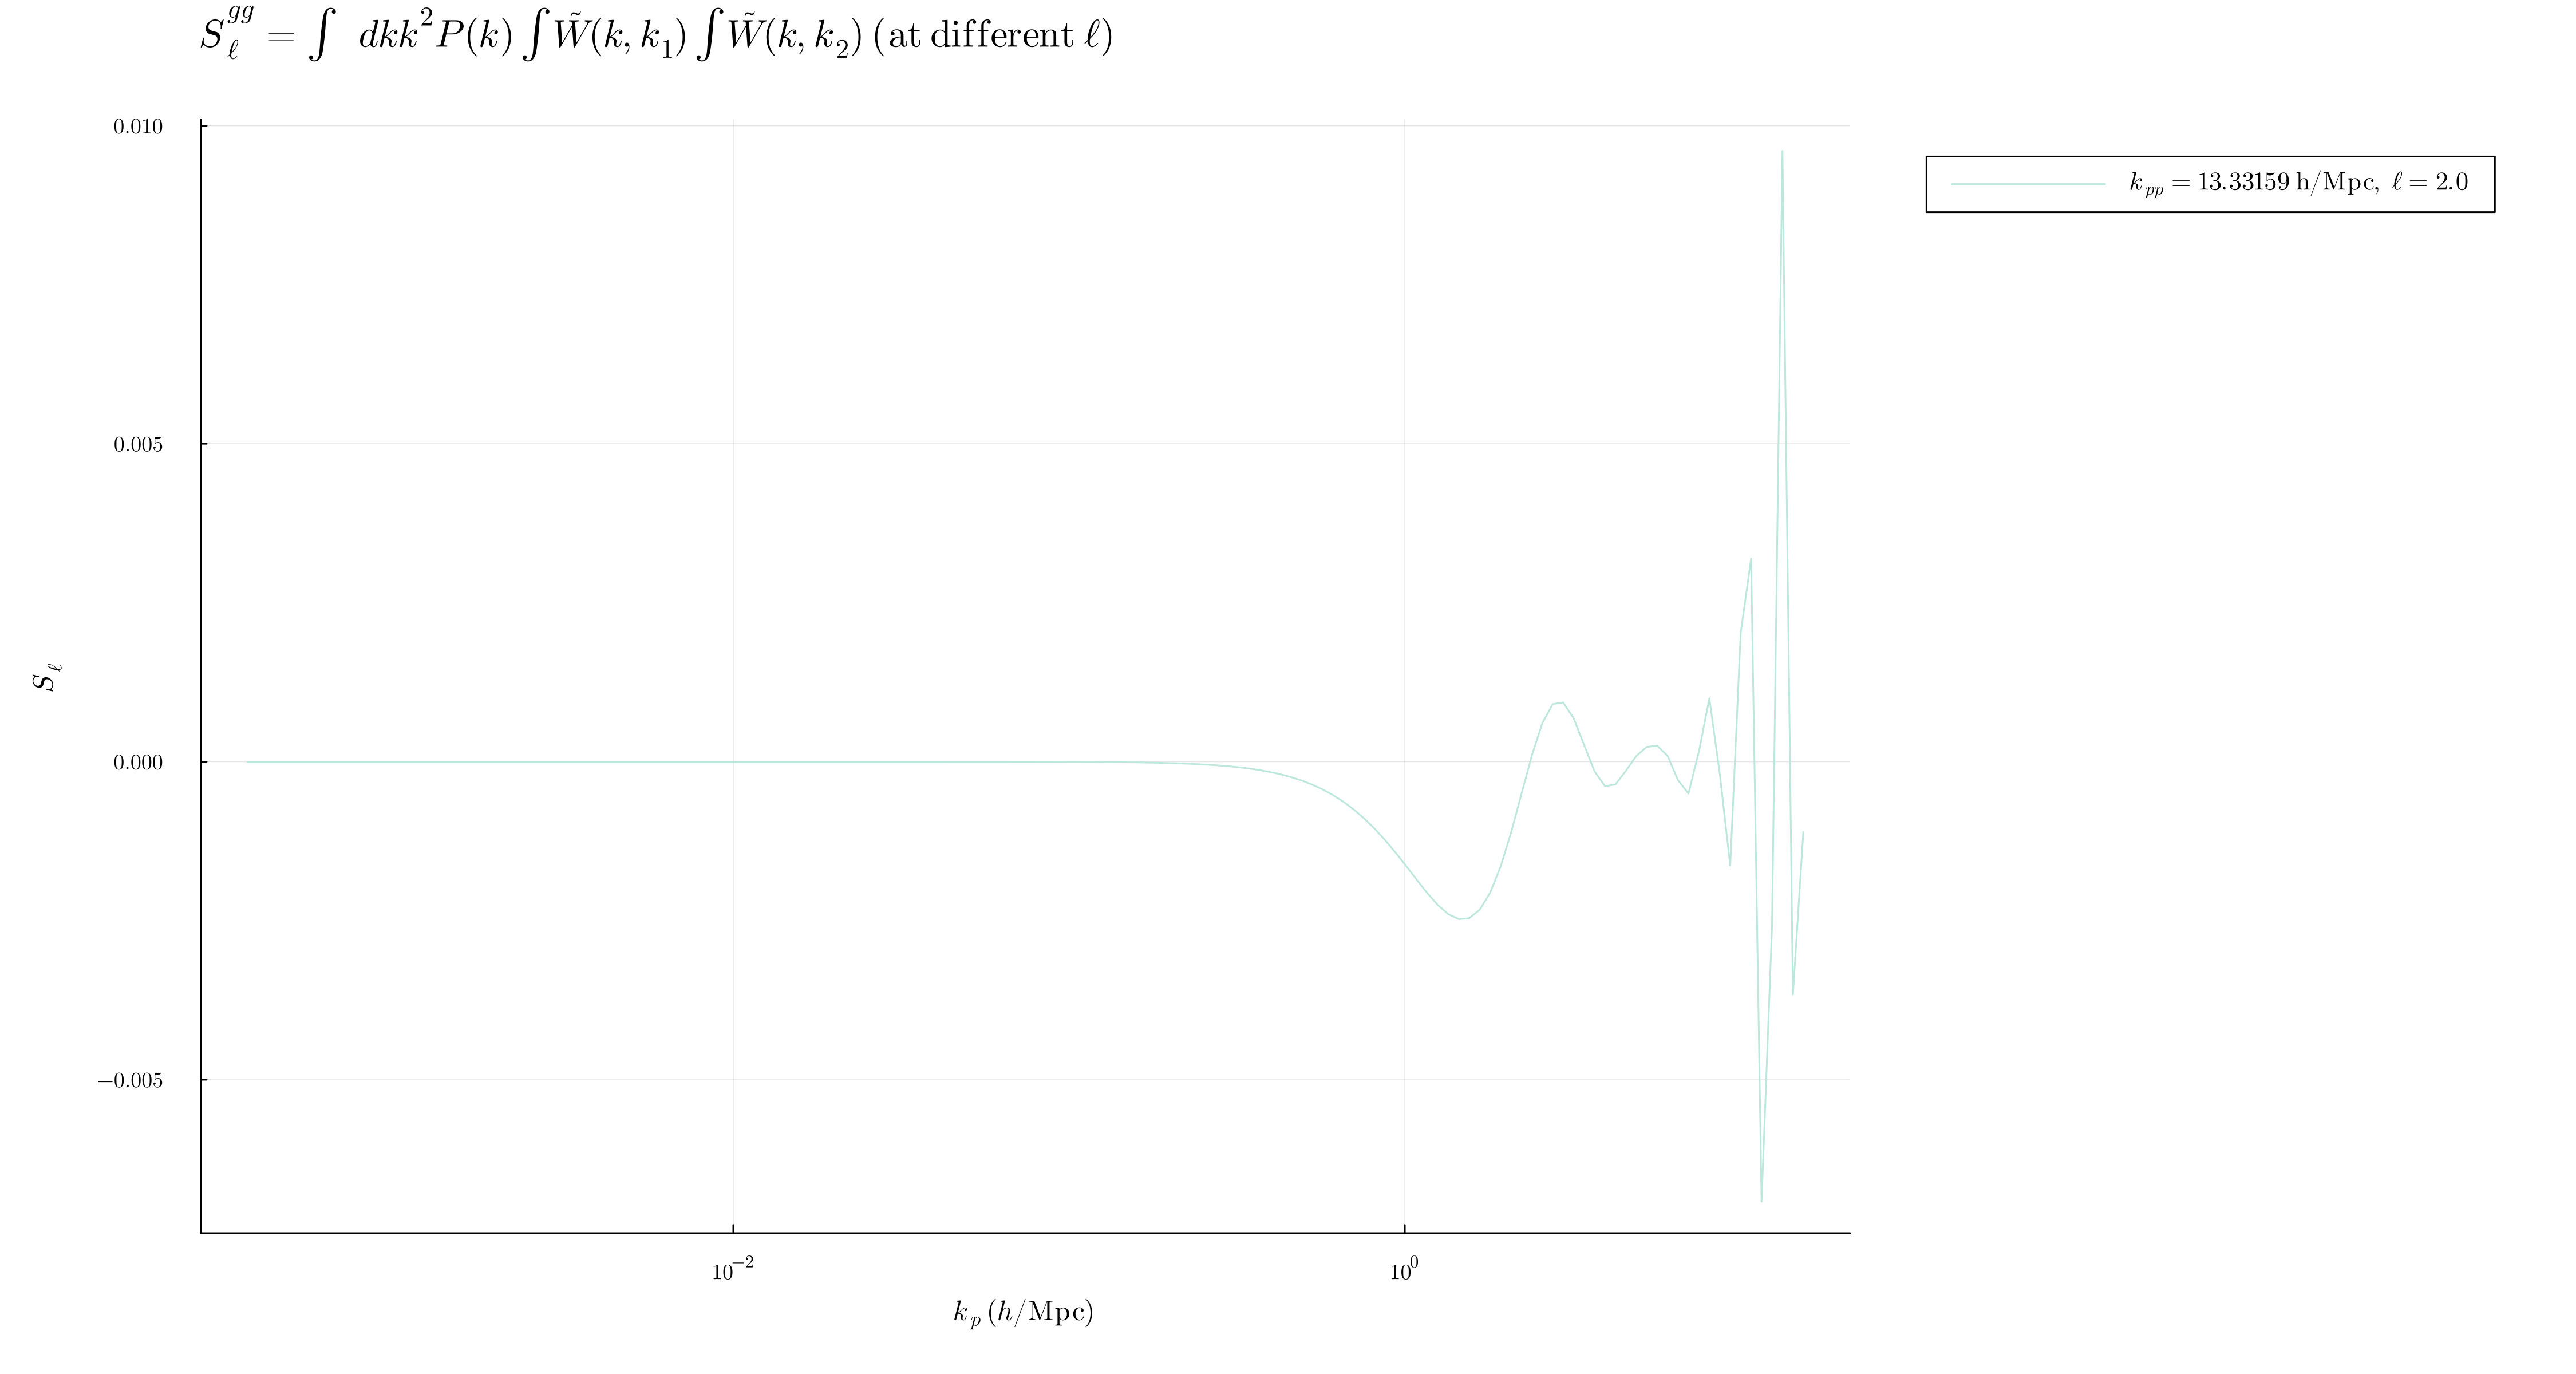

In [666]:
plt = plot(
    xaxis = L"k_{p} \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell",
    xscale = :log10,
    title = L"S_\ell^{gg} = \int dk k^2 P(k) \int \tilde W(k, k_1) \int \tilde W(k, k_2) \; (\mathrm{at} \; \mathrm{different} \; \ell)",
    titlefontsize = 16,
    titleposition = :left, 
    legend = nothing,
    legendposition = :outertopright, 
    size = plot_theme.size_Cl; 
    plot_theme.shared_style...
)

ipp = 148
kpp = grids.kp_grid[ipp]
color_palette = cgrad(:seaborn_icefire_gradient, length(grid_data.ℓ)) 

println("ℓ changes at each iteration")
println("k_1 (k_p) varies at each iteration")
println("k_2 (k_pp) is kept fixed for every iteration")

anim = @animate for il in 1:10:length(grid_data.ℓ)
    plot!(
        plt,
        grids.kp_grid, 
        S_lkk_gg[:, ipp, il],
        color = color_palette[il], # Changed from [ipp] to [il] so colors actually transition
        label = L"k_{pp} = %$(round(kpp, digits=5)) \; \mathrm{h/Mpc}, \; ℓ = %$(grid_data.ℓ[il])",
        linestyle = :solid
    )
end

gif(anim, joinpath(paths.plot_subdir, "Sl_plots/kpp_vs_Sl_idxell_loop_on_ℓ_kp_$kpp"*".gif"), fps = 1)

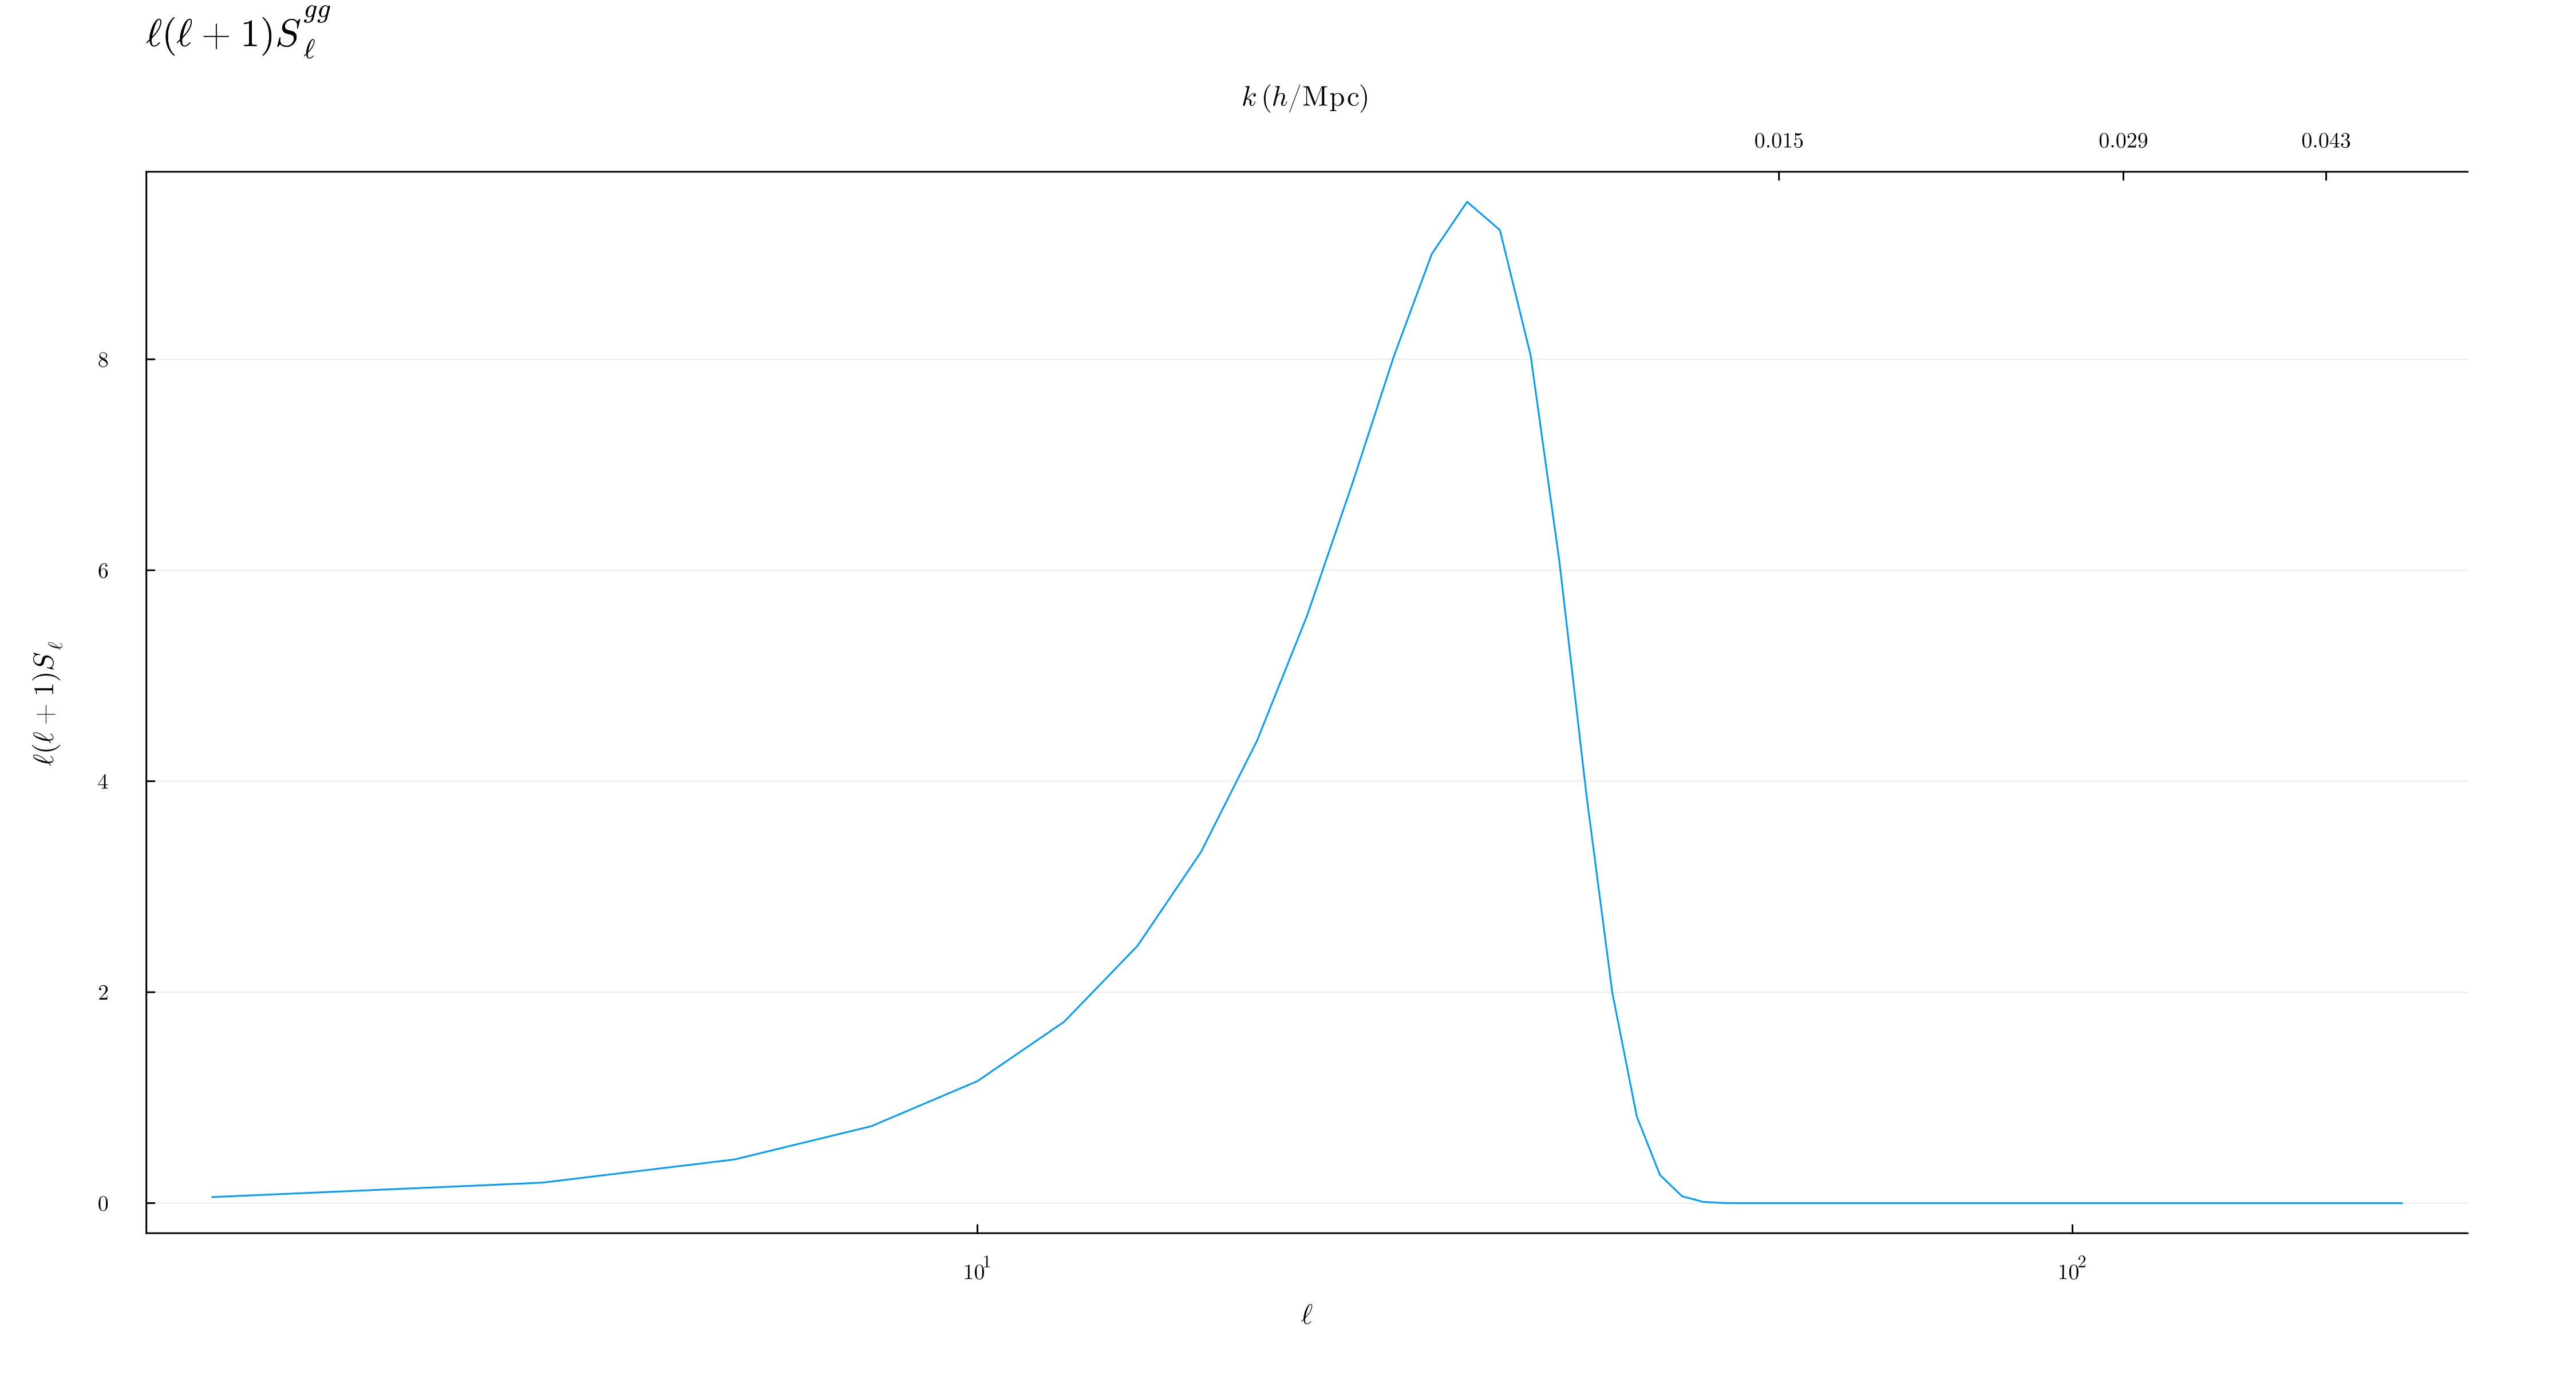

In [669]:
plt = plot()
ip = 148
ipp = 148
k_p = grids.k_grid[ip]
k_pp = grids.kp_grid[ipp]
plot(
    grid_data.ℓ,
    S_lkk_gg[ip, ipp, :] .* grid_data.ℓ .* (grid_data.ℓ .+ 1),
    xaxis = L"\ell",
    yaxis = L"\ell(\ell+1)S_\ell",
)

plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(grid_data.ℓ), maximum(grid_data.ℓ)),
      label = ""
     )

plot!(label = "Beyond BLAST", 
    legend = false, colorbar = true, colorbar_title = L"j", clims = (1, grid_data.Nkp),
    title = L"\ell(\ell+1)S_\ell^{gg}",
    size=plot_theme.size_Cl, titlefontsize=20, 
    xscale = :log10,
    titleposition = :left;
    plot_theme.shared_style...
    )

In [670]:
savefig(joinpath(paths.plot_subdir, "Sl_plots/ell_vs_Sl_kp_kpp_$k_p"*"_"*"$k_pp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_21_173930/plots/Sl_plots/ell_vs_Sl_kp_kpp_13.331592086142688_13.331592086142688.png"

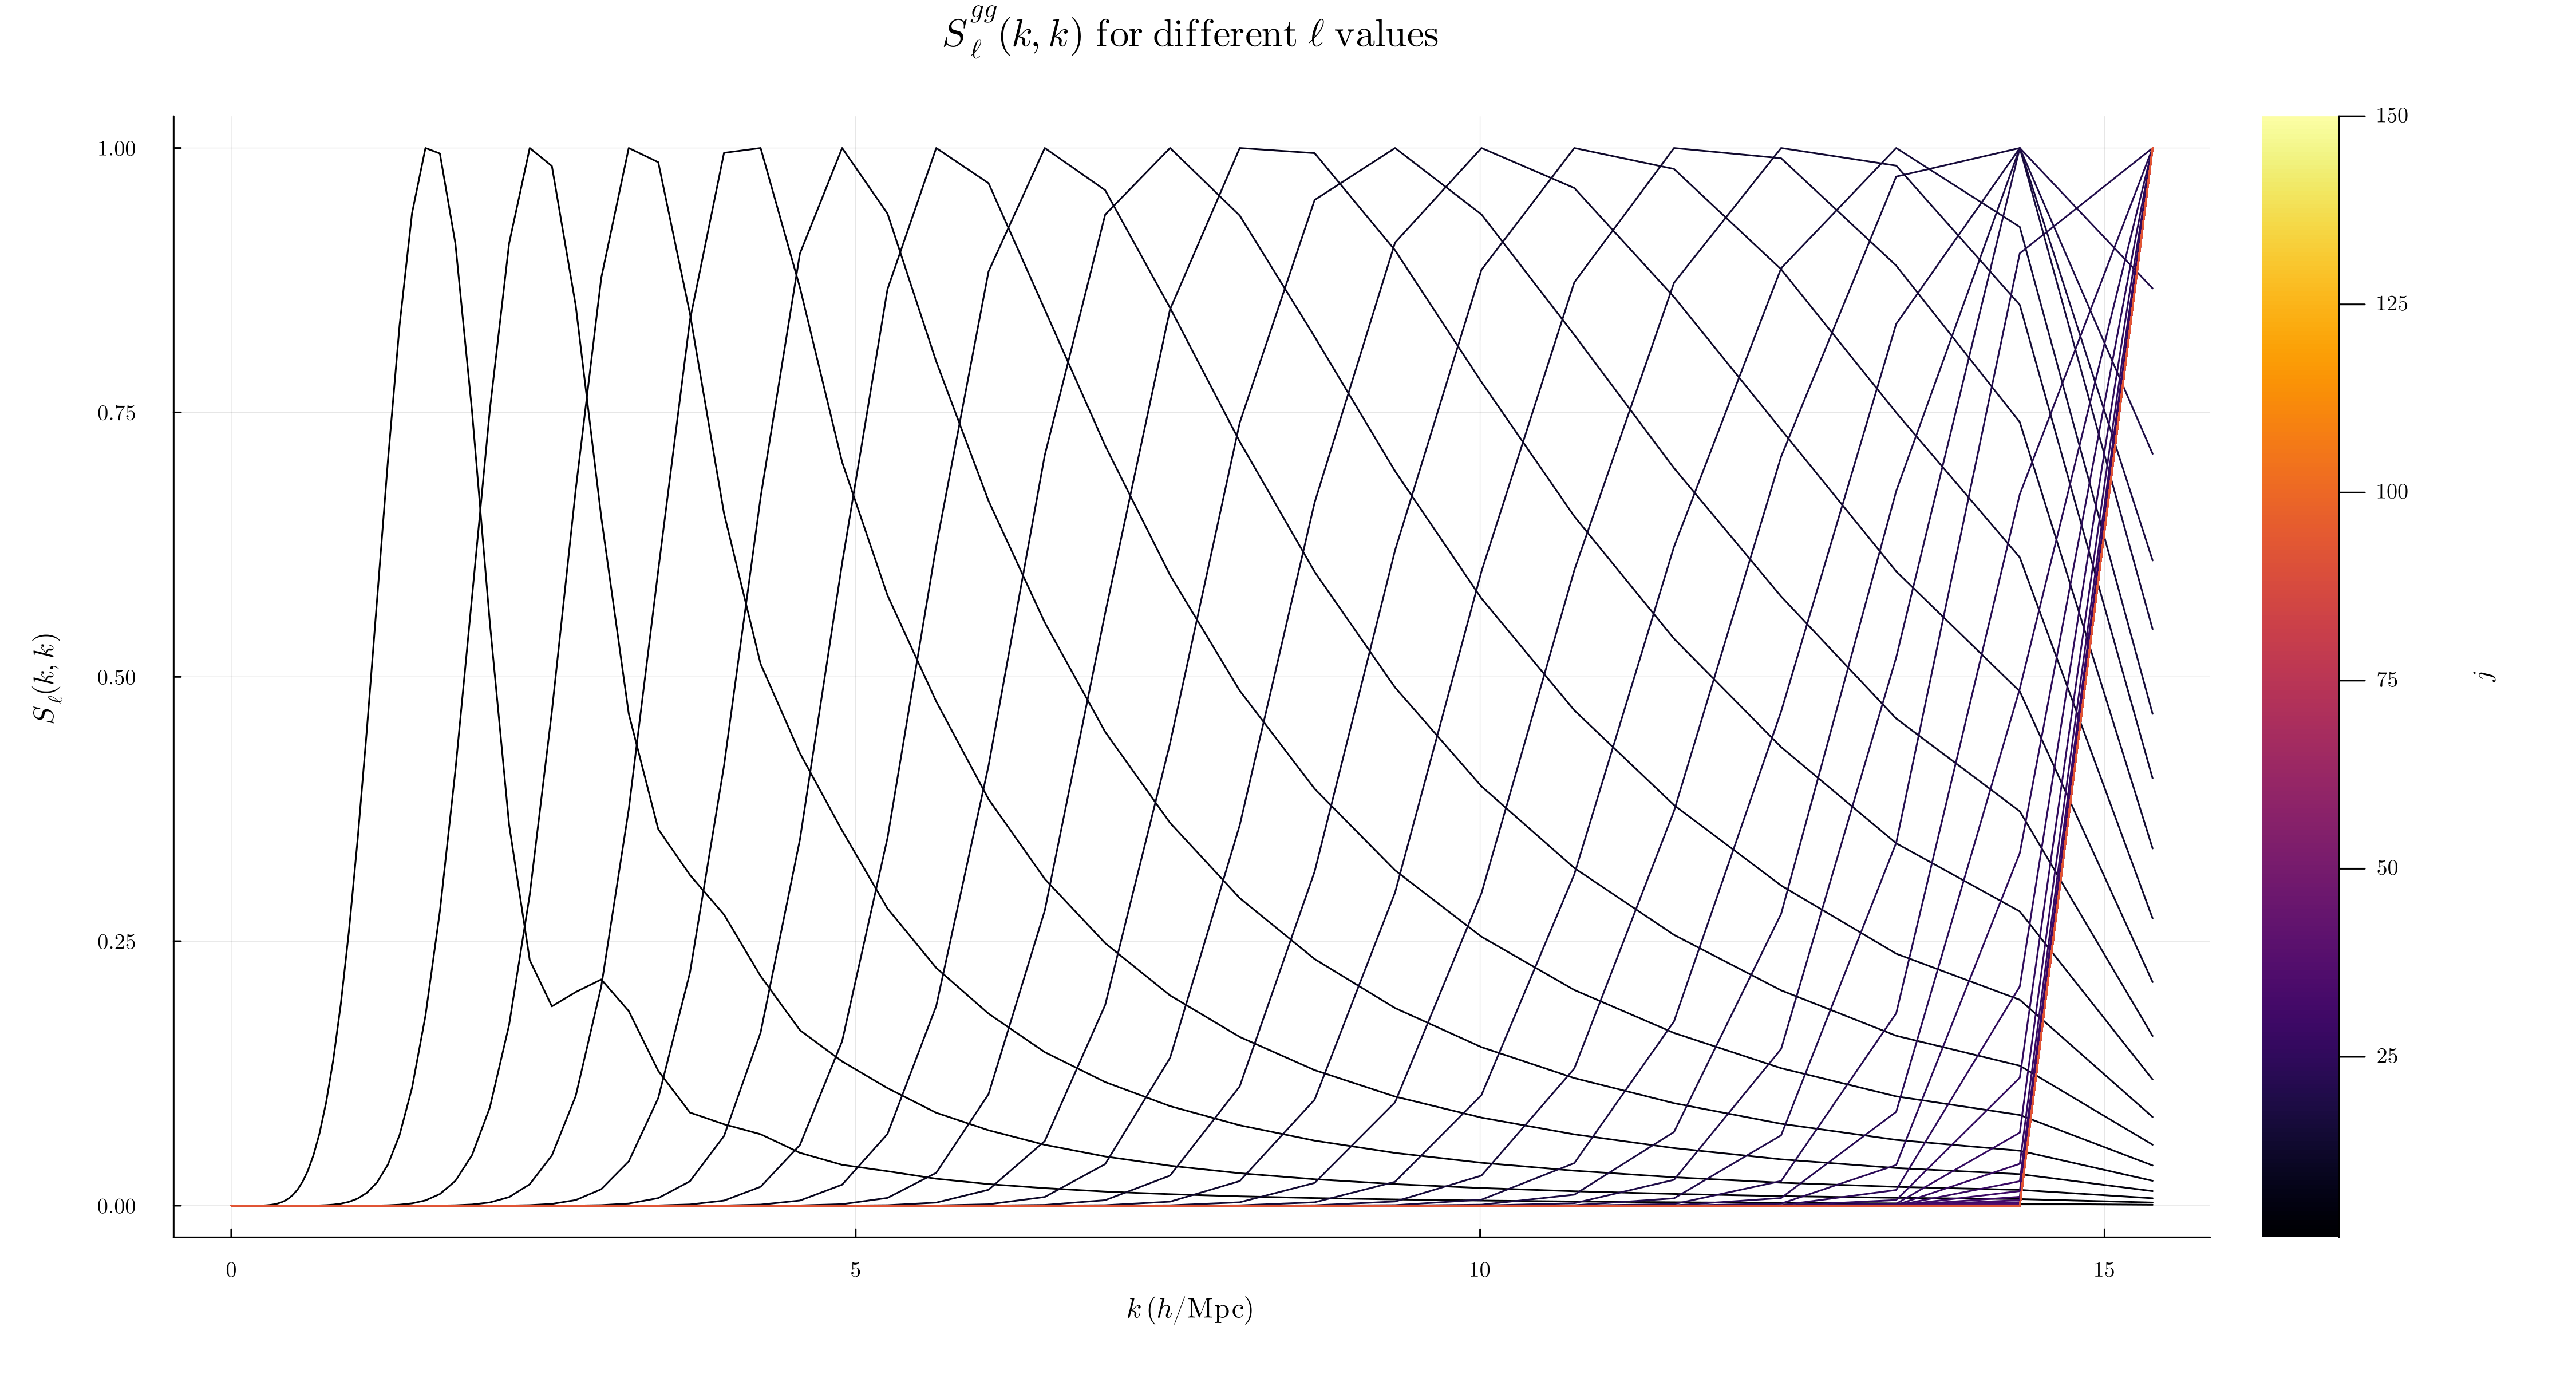

In [671]:
diagS = [diag(S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]

nshow = 100
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

p = plot(
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell\ \mathrm{values}",
    colorbar_title = L"j",
    clims = (1, grid_data.Nkp),                   
    legend = false,
    colorbar = true,
    lw = 2,
    size=plot_theme.size_Cl; 
    plot_theme.shared_style...
)
colors = cgrad(:seaborn_icefire_gradient, nshow)
for ii in idx
    plot!(p, grids.kp_grid, diagS[ii]/maximum(diagS[ii]), line_z = ii, 
    color = colors[ii],;
        label = L"\ell = %$(grid_data.ℓ[ii])")
end

p

In [672]:
println(grids.k_grid[147])
println(grid_data.ℓ[2])

println(S_lkk_gg[5,5,2])
println(S_lkk_gg[150,150,2])

12.410226376695835
4.0
9.420753969588592e-36
0.003889993555275639
